#### This document is for analysis on FACT-E emotional well being (EWB).

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import re

# Preliminary

In [3]:
# Read the CSV file - linked file 
file_path = "Merged_TSQIC_REDCap_ACCESS.xlsx" 
df = pd.read_excel(file_path)
df

,id,operation_date,redcap_event_name,qol_date,age_diagnosis,overall_primary_tumour,overall_regional_ln,overall_distant_metastasis,neotx___notx,neotx___chemo,...,a_e5,a_e6,a_e7,a_c6,a_c2,a_act11,readmission_30d,postop_comp,los,DischargeDate
0,1,NaT,baseline_arm_1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,2012-04-27
1,1,2011-08-26,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-08-26
2,1,2010-02-20,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0,2010-03-08
3,1,2009-05-27,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2009-05-27
4,1,2009-02-25,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,2009-03-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11841,1775,NaT,baseline_arm_1,2025-03-31,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,0.0,2.0,0.0,3.0,0.0,NaN,NaN,NaN,NaT
11842,1775,NaT,baseline_arm_1,NaT,49.287916,3,3,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
11843,1776,NaT,baseline_arm_1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
11844,1776,NaT,baseline_arm_1,2025-04-07,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,1.0,1.0,3.0,4.0,1.0,NaN,NaN,NaN,NaT


In [4]:
df['id'].nunique()

1761

In [5]:
# Step 1: Filter rows where redcap_event_name is either "baseline_arm_1" or "preoperative_arm_1"
filtered_df = df[df['redcap_event_name'].isin(["baseline_arm_1", "preoperative_arm_1"])]

# Step 2: Check if each id has both events
event_counts = filtered_df.groupby('id')['redcap_event_name'].nunique()
valid_ids = event_counts[event_counts == 2].index  # Keep only IDs with both events

# Step 3: Ensure all six columns have values (non-null) for these IDs
valid_rows = filtered_df[filtered_df['id'].isin(valid_ids)]
valid_rows = valid_rows.dropna(subset=["ge1", "ge2", "ge3", "ge4", "ge5", "ge6"])

# Step 4: Find IDs that still have both events after removing rows with NaNs
final_ids = valid_rows.groupby('id')['redcap_event_name'].nunique()
final_ids = final_ids[final_ids == 2].index

len(final_ids)


265

In [6]:
# Step 1: Filter relevant rows
filtered_df = df[df['redcap_event_name'].isin(["baseline_arm_1", "preoperative_arm_1", "1_year_postop_arm_1"])]

# Step 2: Ensure each id has required event pairs
event_counts = filtered_df.groupby('id')['redcap_event_name'].apply(set)

# Step 3: Find ids that have the required event pairs
valid_ids = event_counts[event_counts.apply(lambda x: {"baseline_arm_1", "1_year_postop_arm_1"}.issubset(x) or 
                                                        {"preoperative_arm_1", "1_year_postop_arm_1"}.issubset(x))].index

# Step 4: Check if all six columns have non-null values
valid_rows = filtered_df[filtered_df['id'].isin(valid_ids)]
valid_rows = valid_rows.dropna(subset=["ge1", "ge2", "ge3", "ge4", "ge5", "ge6"])

# Step 5: Reconfirm ids still have required event pairs after removing NaNs
final_event_counts = valid_rows.groupby('id')['redcap_event_name'].apply(set)
final_ids = final_event_counts[final_event_counts.apply(lambda x: {"baseline_arm_1", "1_year_postop_arm_1"}.issubset(x) or 
                                                                {"preoperative_arm_1", "1_year_postop_arm_1"}.issubset(x))].index

len(final_ids)


127

In [7]:
# Assuming your dataframe is called 'df' and the ID column is called 'id'
# If your ID column has a different name, replace 'id' with the actual column name

# Step 1: Find IDs that match each condition
# Group by ID and check which events are present
event_groups = df.groupby('id')['redcap_event_name'].unique()

# Condition 1: Has both "baseline_arm_1" and "1_year_postop_arm_1"
cond1_ids = event_groups[
    event_groups.apply(lambda x: all(event in x for event in ["baseline_arm_1", "1_year_postop_arm_1"]))
].index

# Condition 2: Has both "preoperative_arm_1" and "1_year_postop_arm_1"
cond2_ids = event_groups[
    event_groups.apply(lambda x: all(event in x for event in ["preoperative_arm_1", "1_year_postop_arm_1"]))
].index

# Condition 3: Has all three events
cond3_ids = event_groups[
    event_groups.apply(lambda x: all(event in x for event in ["baseline_arm_1", "preoperative_arm_1", "1_year_postop_arm_1"]))
].index

# Combine all matching IDs (using set to avoid duplicates)
matching_ids = set(cond1_ids).union(cond2_ids).union(cond3_ids)

# Step 2: Subset the original dataframe
filtered_df = df[df['id'].isin(matching_ids)]

# See how many unique IDs were found
print(f"Number of matching IDs: {len(matching_ids)}")

# See which events are present in the filtered data
print(filtered_df.groupby('id')['redcap_event_name'].unique())

Number of matching IDs: 191
id
32      [surgery_arm_1, baseline_arm_1, preoperative_a...
76      [baseline_arm_1, surgery_arm_1, preoperative_a...
125     [1_year_postop_arm_1, surgery_arm_1, preoperat...
151     [surgery_arm_1, baseline_arm_1, preoperative_a...
160     [baseline_arm_1, surgery_arm_1, preoperative_a...
                              ...                        
1621    [baseline_arm_1, preoperative_arm_1, 1_year_po...
1648    [1_year_postop_arm_1, surgery_arm_1, baseline_...
1664    [1_year_postop_arm_1, surgery_arm_1, baseline_...
1670    [surgery_arm_1, 1_year_postop_arm_1, baseline_...
1690    [1_year_postop_arm_1, surgery_arm_1, preoperat...
Name: redcap_event_name, Length: 191, dtype: object


In [8]:
# Assuming df is your dataframe with 'id', 'redcap_event_name', and 'ge1' to 'ge6' columns
score_cols = ['ge1', 'ge2', 'ge3', 'ge4', 'ge5', 'ge6']

# Step 1: Filter IDs with required redcap_event_name combinations
id_events = df.groupby('id')['redcap_event_name'].unique().reset_index()
def has_required_events(events):
    events_set = set(events)
    baseline = "baseline_arm_1" in events_set
    preop = "preoperative_arm_1" in events_set
    postop = "1_year_postop_arm_1" in events_set
    return (baseline and postop) or (preop and postop) or (baseline and preop and postop)

valid_ids = id_events[id_events['redcap_event_name'].apply(has_required_events)]['id']
df_filtered = df[df['id'].isin(valid_ids)]

# Step 2: Filter IDs with at least one ge1-ge6 score in the required events
def check_scores_per_id(id_df):
    events = id_df['redcap_event_name'].unique()
    baseline = "baseline_arm_1" in events
    preop = "preoperative_arm_1" in events
    postop = "1_year_postop_arm_1" in events
    has_scores = lambda df: df[score_cols].notna().any().any()
    
    baseline_df = id_df[id_df['redcap_event_name'] == "baseline_arm_1"]
    preop_df = id_df[id_df['redcap_event_name'] == "preoperative_arm_1"]
    postop_df = id_df[id_df['redcap_event_name'] == "1_year_postop_arm_1"]
    
    if baseline and postop:
        if has_scores(baseline_df) and has_scores(postop_df):
            return True
    if preop and postop:
        if has_scores(preop_df) and has_scores(postop_df):
            return True
    if baseline and preop and postop:
        if has_scores(baseline_df) and has_scores(preop_df) and has_scores(postop_df):
            return True
    return False

id_groups = df_filtered.groupby('id')
valid_ids_with_scores = id_groups.filter(check_scores_per_id)['id'].unique()

# Output the result
print("IDs with required events and at least one ge1-ge6 score:", len(valid_ids_with_scores.tolist()))

IDs with required events and at least one ge1-ge6 score: 136


# Analysis

In [9]:
# Step 1: Find eligible IDs (unchanged)
def find_eligible_ids(df):
    id_events = df.groupby('id')['redcap_event_name'].apply(set)
    eligible_ids = []
    for id_val, events in id_events.items():
        has_baseline = "baseline_arm_1" in events
        has_preop = "preoperative_arm_1" in events
        has_one_year = "1_year_postop_arm_1" in events
        if (has_baseline and has_one_year) or (has_preop and has_one_year):
            eligible_ids.append(id_val)
    return eligible_ids

# Step 2: Filter dataset (unchanged)
def filter_eligible_data(df, eligible_ids):
    return df[df['id'].isin(eligible_ids)].copy()

# Step 3: Calculate all subscale scores (unchanged)
def calculate_subscale_score(df, cols, reverse_items=None, subscale_name=""):
    """Calculate subscale scores according to FACT scoring guidelines, only if >=50% items are answered"""
    # Convert to numeric and handle reverse scoring
    for col in cols:
        df[f"{col}_score"] = pd.to_numeric(df[col], errors='coerce')
        if reverse_items and col in reverse_items:
            df[f"{col}_score"] = 4 - df[f"{col}_score"]
    
    # Calculate the number of items and the 50% threshold
    total_items = len(cols)
    min_items_required = total_items / 2  # 50% threshold
    
    # Count non-NaN items for each row
    score_cols = [f"{col}_score" for col in cols]
    num_answered_items = df[score_cols].notna().sum(axis=1)
    
    # Calculate subscale score only if >=50% items are answered
    df[f"{subscale_name}_subscale_score"] = np.where(
        num_answered_items >= min_items_required,
        (df[score_cols].sum(axis=1, skipna=True) * total_items) / 
        df[score_cols].notna().sum(axis=1),
        np.nan
    )
    return df

def calculate_all_scores(df):
    pwb_cols = [f"gp{i}" for i in range(1, 8)]
    swb_cols = [f"gs{i}" for i in range(1, 8)]
    ewb_cols = [f"ge{i}" for i in range(1, 7)]
    fwb_cols = [f"gf{i}" for i in range(1, 8)]
    ecs_cols = [f"a_hn{i}" for i in range(1, 6)] + ["a_hn7", "a_hn10"] + \
                [f"a_e{i}" for i in range(1, 8)] + ["a_c6", "a_c2", "a_act11"]

    pwb_reverse = pwb_cols
    ewb_reverse = [f"ge{i}" for i in range(1, 7) if i != 2]
    ecs_reverse = ["a_e1", "a_e2", "a_e3", "a_e4", "a_e5", "a_e7", "a_act11", 
                    "a_c2", "a_hn2", "a_hn3"]

    df = calculate_subscale_score(df, pwb_cols, pwb_reverse, "pwb")
    df = calculate_subscale_score(df, swb_cols, None, "swb")
    df = calculate_subscale_score(df, ewb_cols, ewb_reverse, "ewb")
    df = calculate_subscale_score(df, fwb_cols, None, "fwb")
    df = calculate_subscale_score(df, ecs_cols, ecs_reverse, "ecs")

    # Calculate composite scores with both conditions
    # 1. FACT-G Total (PWB + SWB + EWB + FWB)
    fact_g_items = pwb_cols + swb_cols + ewb_cols + fwb_cols  # 27 items
    fact_g_item_cols = [f"{col}_score" for col in fact_g_items]
    fact_g_num_answered = df[fact_g_item_cols].notna().sum(axis=1)
    fact_g_min_items = 22  # 80% of 27 items = 21.6, rounded up to 22
    
    df['fact_g_total'] = np.where(
        # Condition 1: All subscales must be non-NaN (already ensures 50% of items per subscale)
        (df["pwb_subscale_score"].notna()) & 
        (df["swb_subscale_score"].notna()) & 
        (df["ewb_subscale_score"].notna()) & 
        (df["fwb_subscale_score"].notna()) &
        # Condition 2: At least 80% of FACT-G items must be answered
        (fact_g_num_answered >= fact_g_min_items),
        df["pwb_subscale_score"] + df["swb_subscale_score"] + 
        df["ewb_subscale_score"] + df["fwb_subscale_score"],
        np.nan
    )
    
    # 2. FACT-E Total (FACT-G + ECS)
    fact_e_items = fact_g_items + ecs_cols  # 27 + 17 = 44 items
    fact_e_item_cols = [f"{col}_score" for col in fact_e_items]
    fact_e_num_answered = df[fact_e_item_cols].notna().sum(axis=1)
    fact_e_min_items = 36  # 80% of 44 items = 35.2, rounded up to 36
    
    df['fact_e_total'] = np.where(
        # Condition 1: FACT-G and ECS must be non-NaN
        (df['fact_g_total'].notna()) & 
        (df["ecs_subscale_score"].notna()) &
        # Condition 2: At least 80% of FACT-E items must be answered
        (fact_e_num_answered >= fact_e_min_items),
        df['fact_g_total'] + df["ecs_subscale_score"],
        np.nan
    )
    
    # 3. TOI (PWB + FWB + ECS)
    toi_items = pwb_cols + fwb_cols + ecs_cols  # 7 + 7 + 17 = 31 items
    toi_item_cols = [f"{col}_score" for col in toi_items]
    toi_num_answered = df[toi_item_cols].notna().sum(axis=1)
    toi_min_items = 25  # 80% of 31 items = 24.8, rounded up to 25
    
    df['toi'] = np.where(
        # Condition 1: PWB, FWB, and ECS must be non-NaN
        (df["pwb_subscale_score"].notna()) & 
        (df["fwb_subscale_score"].notna()) & 
        (df["ecs_subscale_score"].notna()) &
        # Condition 2: At least 80% of TOI items must be answered
        (toi_num_answered >= toi_min_items),
        df["pwb_subscale_score"] + df["fwb_subscale_score"] + df["ecs_subscale_score"],
        np.nan
    )

    return df

# Step 4: Analyze improvement for all scores (fixed)
def analyze_improvement(df):
    results = []
    unique_ids = df['id'].unique()
    
    score_types = ['pwb_subscale_score', 'swb_subscale_score', 'ewb_subscale_score',
                    'fwb_subscale_score', 'ecs_subscale_score', 'fact_g_total',
                    'fact_e_total', 'toi']
    
    for id_val in unique_ids:
        id_data = df[df['id'] == id_val]
        events = id_data['redcap_event_name'].unique()
        print(f"\nID {id_val} has events: {events}")
        
        event_scores = id_data.groupby('redcap_event_name')[score_types].mean().reset_index()
        
        baseline_score = event_scores[event_scores['redcap_event_name'] == 'baseline_arm_1']
        preop_score = event_scores[event_scores['redcap_event_name'] == 'preoperative_arm_1']
        one_year_score = event_scores[event_scores['redcap_event_name'] == '1_year_postop_arm_1']
        
        # Skip if no one-year data
        if one_year_score.empty:
            continue
            
        one_year_values = one_year_score[score_types].iloc[0].to_dict()
        
        # Print scores
        if not baseline_score.empty:
            baseline_values = baseline_score[score_types].iloc[0].to_dict()
            print(f"Baseline score: [{', '.join([f'{k}: {v:.1f}' for k, v in baseline_values.items() if pd.notna(v)])}]")
        else:
            print("Baseline score: [nan]")
            
        if not preop_score.empty:
            preop_values = preop_score[score_types].iloc[0].to_dict()
            print(f"Preop score: [{', '.join([f'{k}: {v:.1f}' for k, v in preop_values.items() if pd.notna(v)])}]")
        else:
            print("Preop score: [nan]")
            
        print(f"One-year score: [{', '.join([f'{k}: {v:.1f}' for k, v in one_year_values.items() if pd.notna(v)])}]")
        
        # Determine which baseline to use (fixed logic)
        baseline_type = None
        baseline_values = None
        
        # Check if baseline_score exists and has non-NaN values
        if not baseline_score.empty:
            baseline_values_temp = baseline_score[score_types].iloc[0].to_dict()
            # Check if at least one score is non-NaN
            if any(pd.notna(val) for val in baseline_values_temp.values()):
                baseline_type = 'baseline_arm_1'
                baseline_values = baseline_values_temp
                print(f"Using baseline score: {', '.join([f'{k}: {v:.1f}' for k, v in baseline_values.items() if pd.notna(v)])}")
        
        # If baseline is not valid, fall back to preop
        if baseline_values is None and not preop_score.empty:
            preop_values_temp = preop_score[score_types].iloc[0].to_dict()
            if any(pd.notna(val) for val in preop_values_temp.values()):
                baseline_type = 'preoperative_arm_1'
                baseline_values = preop_values_temp
                print(f"Using preop score as baseline: {', '.join([f'{k}: {v:.1f}' for k, v in baseline_values.items() if pd.notna(v)])}")
        
        # Skip if no valid baseline
        if baseline_values is None:
            continue
        
        # Calculate improvements
        result = {'id': id_val, 'baseline_type': baseline_type}
        for score_type in score_types:
            if pd.notna(baseline_values[score_type]) and pd.notna(one_year_values[score_type]):
                improvement = one_year_values[score_type] - baseline_values[score_type]
                result.update({
                    f'{score_type}_baseline': baseline_values[score_type],
                    f'{score_type}_one_year': one_year_values[score_type],
                    f'{score_type}_improvement': improvement,
                    f'{score_type}_has_improved': improvement >= 5
                })
        
        results.append(result)
    
    return pd.DataFrame(results)

# Main function (unchanged)
def analyze_patient_outcomes(df):
    required_cols = ['id', 'redcap_event_name'] + \
                    [f"gp{i}" for i in range(1, 8)] + \
                    [f"gs{i}" for i in range(1, 8)] + \
                    [f"ge{i}" for i in range(1, 7)] + \
                    [f"gf{i}" for i in range(1, 8)] + \
                    [f"a_hn{i}" for i in range(1, 6)] + ["a_hn7", "a_hn10"] + \
                    [f"a_e{i}" for i in range(1, 8)] + ["a_c6", "a_c2", "a_act11"]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        print(f"Warning: Missing columns: {missing_cols}")
    
    eligible_ids = find_eligible_ids(df)
    print(f"Found {len(eligible_ids)} eligible IDs")
    
    filtered_df = filter_eligible_data(df, eligible_ids)
    print(f"Filtered dataframe shape: {filtered_df.shape}")
    
    filtered_df = calculate_all_scores(filtered_df)
    
    score_cols = [col for col in filtered_df.columns if col.endswith('_score') or col.endswith('_total')]
    print(f"Created score columns: {score_cols}")
    
    score_types = ['pwb_subscale_score', 'swb_subscale_score', 'ewb_subscale_score',
                    'fwb_subscale_score', 'ecs_subscale_score', 'fact_g_total',
                    'fact_e_total', 'toi']
    for score_type in score_types:
        non_nan_count = filtered_df[score_type].notna().sum()
        print(f"Non-NaN {score_type}: {non_nan_count} out of {len(filtered_df)}")
    
    results_df = analyze_improvement(filtered_df)
    
    if not results_df.empty:
        print(f"\nAnalysis complete for {len(results_df)} patients:")
        for score_type in score_types:
            # Count patients with non-NaN improvement values for this score type
            valid_improvements = results_df[f'{score_type}_improvement'].notna().sum()
            if valid_improvements > 0:
                improved = results_df[f'{score_type}_has_improved'].sum()
                rate = (improved / valid_improvements) * 100
                print(f"Patients with {score_type} improvement (≥5 points): {improved} out of {valid_improvements} ({rate:.1f}%)")
            else:
                print(f"Patients with {score_type} improvement (≥5 points): 0 out of 0 (0.0%)")
    return filtered_df, results_df

# Example usage
filtered_df, results_df = analyze_patient_outcomes(df)

results_df.to_csv("results.csv", index=False)

Found 191 eligible IDs
Filtered dataframe shape: (1963, 80)
Created score columns: ['cci_total', 'gp1_score', 'gp2_score', 'gp3_score', 'gp4_score', 'gp5_score', 'gp6_score', 'gp7_score', 'pwb_subscale_score', 'gs1_score', 'gs2_score', 'gs3_score', 'gs4_score', 'gs5_score', 'gs6_score', 'gs7_score', 'swb_subscale_score', 'ge1_score', 'ge2_score', 'ge3_score', 'ge4_score', 'ge5_score', 'ge6_score', 'ewb_subscale_score', 'gf1_score', 'gf2_score', 'gf3_score', 'gf4_score', 'gf5_score', 'gf6_score', 'gf7_score', 'fwb_subscale_score', 'a_hn1_score', 'a_hn2_score', 'a_hn3_score', 'a_hn4_score', 'a_hn5_score', 'a_hn7_score', 'a_hn10_score', 'a_e1_score', 'a_e2_score', 'a_e3_score', 'a_e4_score', 'a_e5_score', 'a_e6_score', 'a_e7_score', 'a_c6_score', 'a_c2_score', 'a_act11_score', 'ecs_subscale_score', 'fact_g_total', 'fact_e_total']
Non-NaN pwb_subscale_score: 448 out of 1963
Non-NaN swb_subscale_score: 438 out of 1963
Non-NaN ewb_subscale_score: 444 out of 1963
Non-NaN fwb_subscale_score: 4


ID 597 has events: ['surgery_arm_1' '1_year_postop_arm_1' 'baseline_arm_1'
 'preoperative_arm_1']
Baseline score: []
Preop score: []
One-year score: [pwb_subscale_score: 15.2, swb_subscale_score: 19.0, ewb_subscale_score: 16.0, fwb_subscale_score: 12.0, ecs_subscale_score: 53.0, fact_g_total: 62.2, fact_e_total: 115.2, toi: 80.2]

ID 609 has events: ['baseline_arm_1' '1_year_postop_arm_1' 'preoperative_arm_1' nan
 'surgery_arm_1']
Baseline score: [pwb_subscale_score: 22.0, swb_subscale_score: 4.7, ewb_subscale_score: 22.0, fwb_subscale_score: 20.0, ecs_subscale_score: 61.0, fact_g_total: 68.7, fact_e_total: 129.7, toi: 103.0]
Preop score: [pwb_subscale_score: 24.0, swb_subscale_score: 14.0, ewb_subscale_score: 18.0, fwb_subscale_score: 21.0, ecs_subscale_score: 47.0, fact_g_total: 77.0, fact_e_total: 124.0, toi: 92.0]
One-year score: [pwb_subscale_score: 19.8, ecs_subscale_score: 43.3]
Using baseline score: pwb_subscale_score: 22.0, swb_subscale_score: 4.7, ewb_subscale_score: 22.0, f

In [10]:
results_df

,id,baseline_type,pwb_subscale_score_baseline,pwb_subscale_score_one_year,pwb_subscale_score_improvement,pwb_subscale_score_has_improved,swb_subscale_score_baseline,swb_subscale_score_one_year,swb_subscale_score_improvement,swb_subscale_score_has_improved,...,fact_g_total_improvement,fact_g_total_has_improved,fact_e_total_baseline,fact_e_total_one_year,fact_e_total_improvement,fact_e_total_has_improved,toi_baseline,toi_one_year,toi_improvement,toi_has_improved
0,32,baseline_arm_1,24.5,27.0,2.5,False,22.0,28.0,6.0,True,...,32.5,True,117.5,159.0,41.5,True,89.5,107.0,17.5,True
1,76,preoperative_arm_1,7.0,7.0,0.0,False,23.0,21.0,-2.0,False,...,-10.0,False,95.0,97.0,2.0,False,58.0,65.0,7.0,True
2,125,baseline_arm_1,21.0,22.0,1.0,False,17.5,21.0,3.5,False,...,7.5,True,119.5,129.0,9.5,True,81.0,89.0,8.0,True
3,160,baseline_arm_1,21.0,28.0,7.0,True,20.0,22.0,2.0,False,...,13.0,True,119.0,152.0,33.0,True,78.0,107.0,29.0,True
4,198,baseline_arm_1,25.0,26.5,1.5,False,13.0,18.0,5.0,True,...,12.0,True,133.0,139.0,6.0,True,103.0,98.0,-5.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137,1571,baseline_arm_1,26.0,16.0,-10.0,False,28.0,28.0,0.0,False,...,-26.0,False,153.0,104.0,-49.0,False,109.0,61.0,-48.0,False
138,1572,baseline_arm_1,27.0,24.0,-3.0,False,13.0,21.0,8.0,True,...,-1.0,False,141.0,115.0,-26.0,False,109.0,76.0,-33.0,False
139,1615,baseline_arm_1,23.0,19.0,-4.0,False,24.0,22.0,-2.0,False,...,-1.0,False,126.0,111.0,-15.0,False,86.0,69.0,-17.0,False
140,1621,baseline_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
filtered_df

,id,operation_date,redcap_event_name,qol_date,age_diagnosis,overall_primary_tumour,overall_regional_ln,overall_distant_metastasis,neotx___notx,neotx___chemo,...,a_e5_score,a_e6_score,a_e7_score,a_c6_score,a_c2_score,a_act11_score,ecs_subscale_score,fact_g_total,fact_e_total,toi
242,32,2007-11-15,surgery_arm_1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243,32,NaT,baseline_arm_1,NaT,29.722718,3,0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
244,32,NaT,baseline_arm_1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
245,32,NaT,preoperative_arm_1,NaT,NaN,NaN,NaN,NaN,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
246,32,NaT,1_year_postop_arm_1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11456,1690,NaT,1_year_postop_arm_1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11457,1690,NaT,baseline_arm_1,NaT,46.317287,3,2,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11458,1690,NaT,baseline_arm_1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11459,1690,2024-06-25,surgery_arm_1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


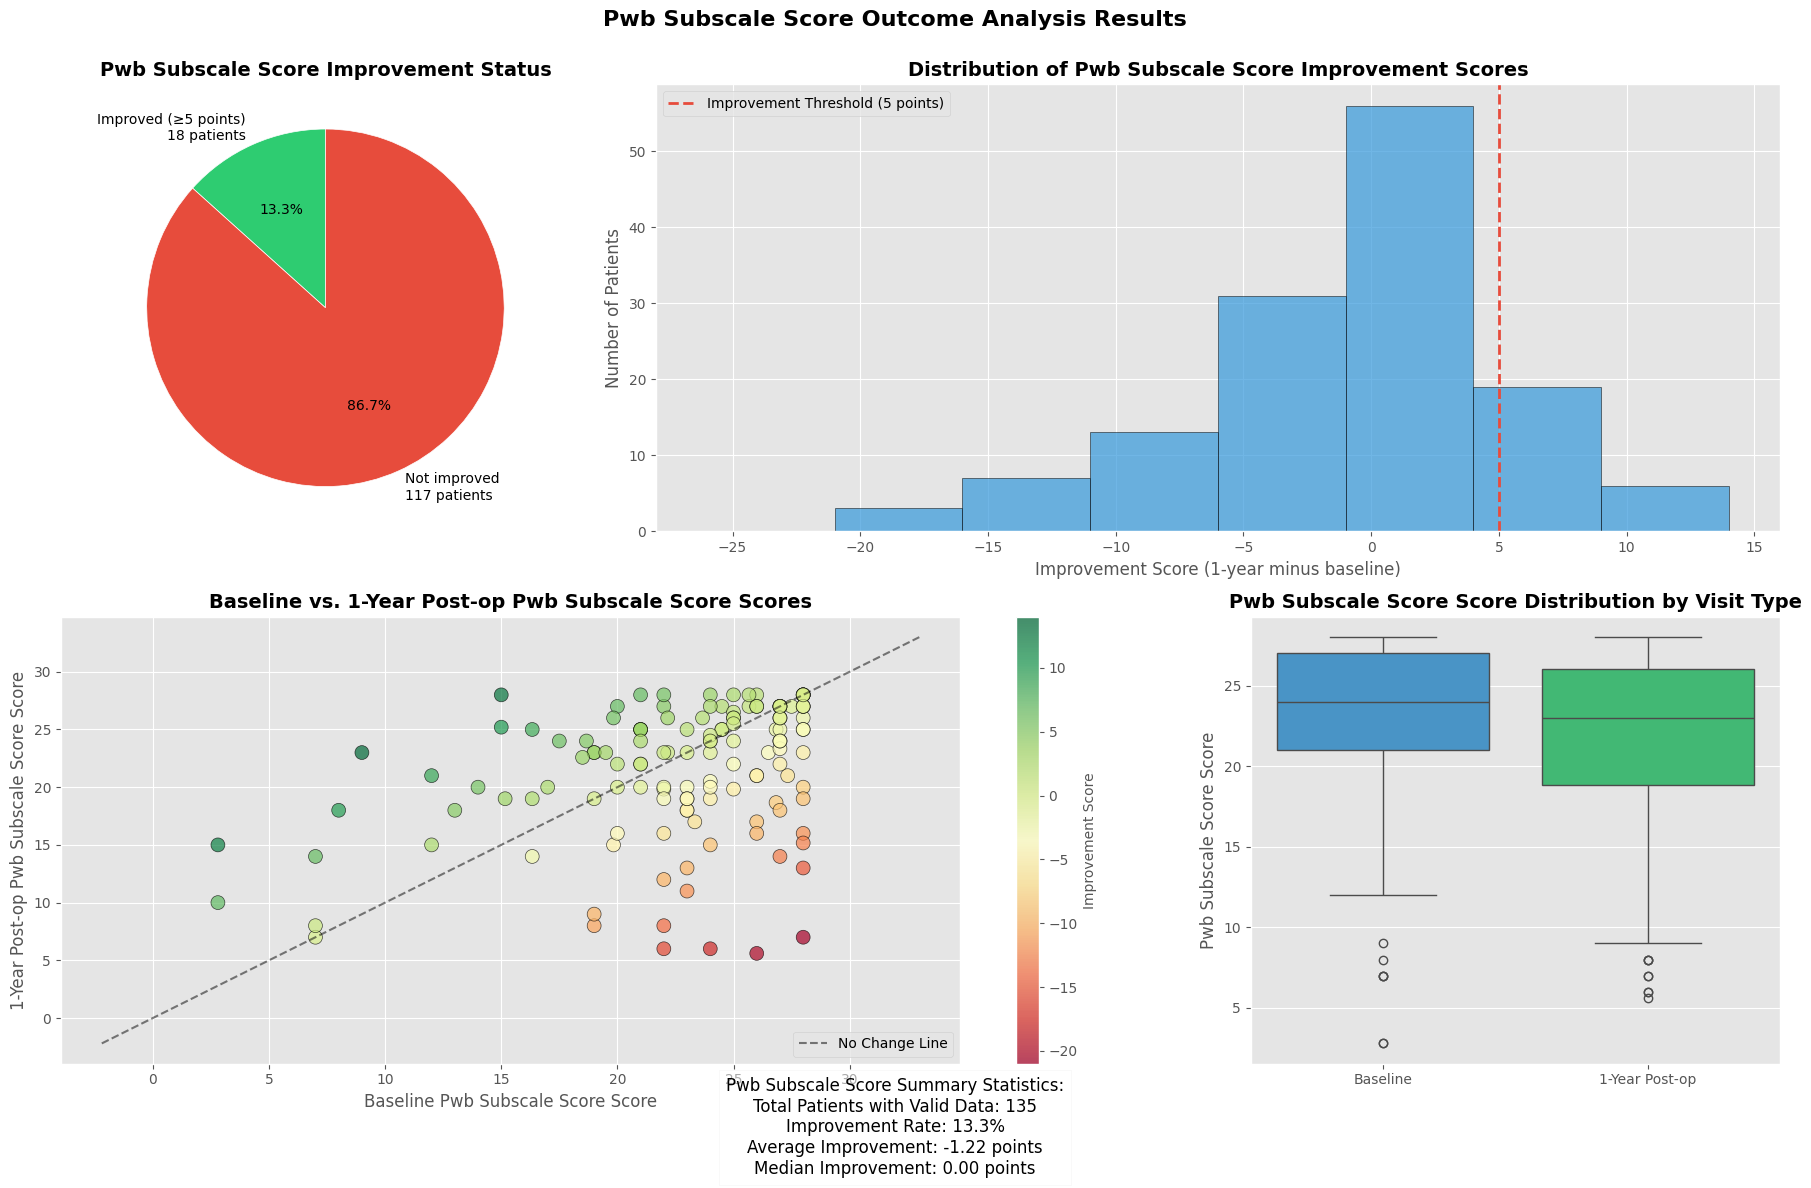

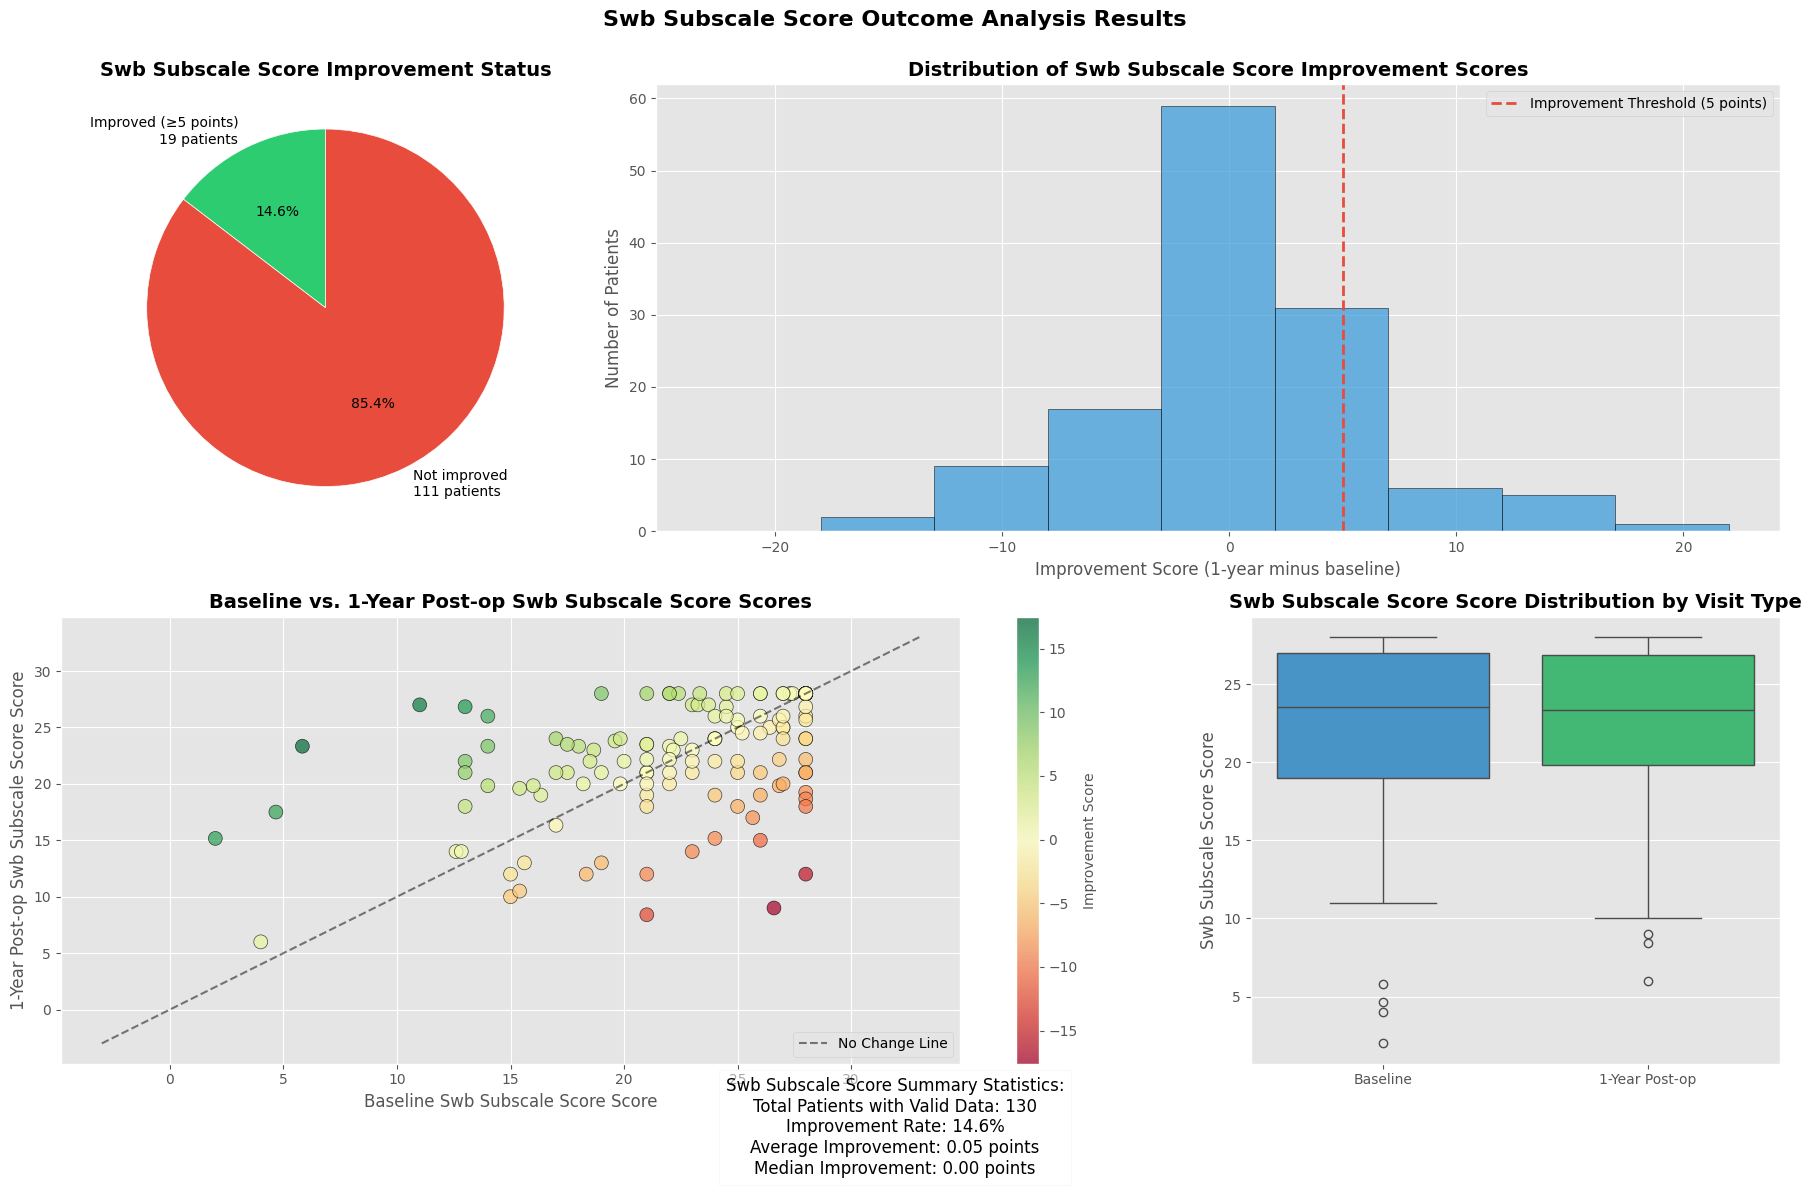

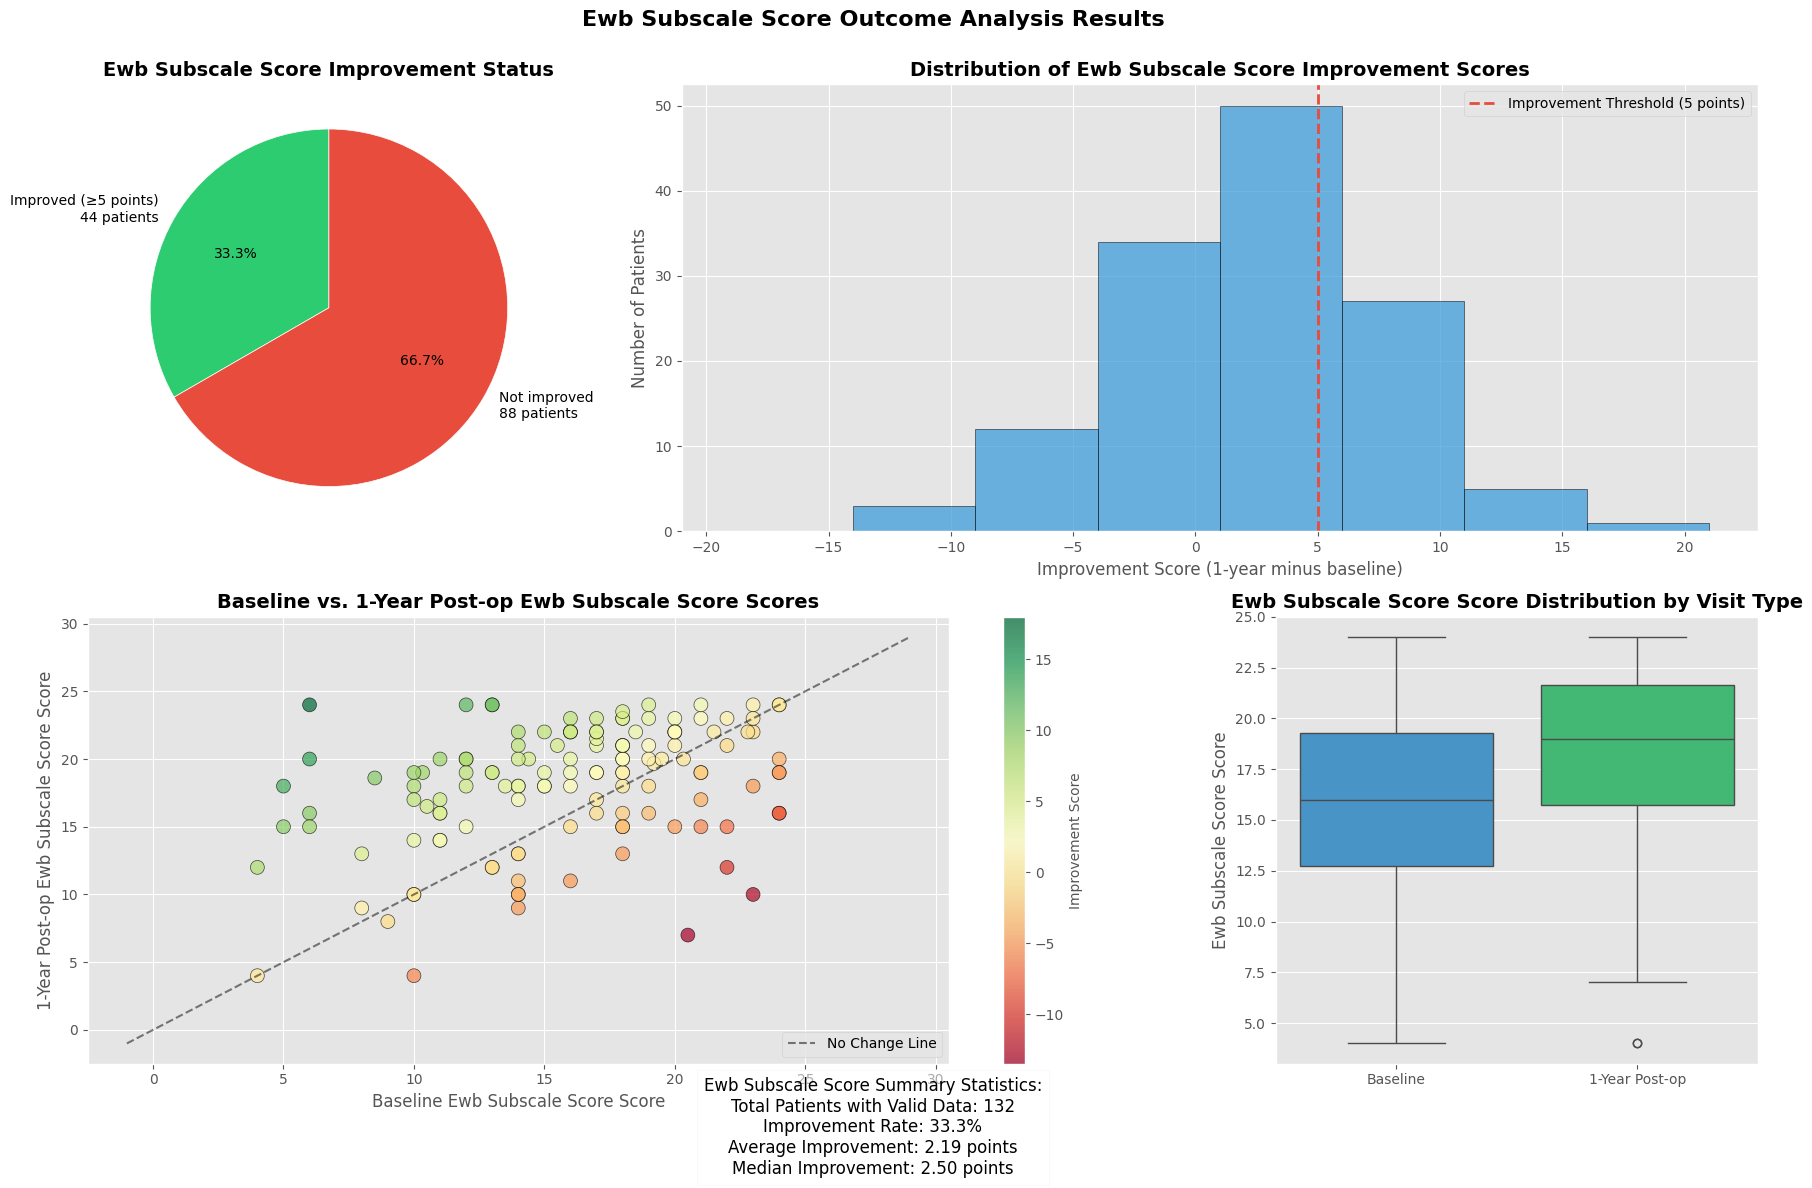

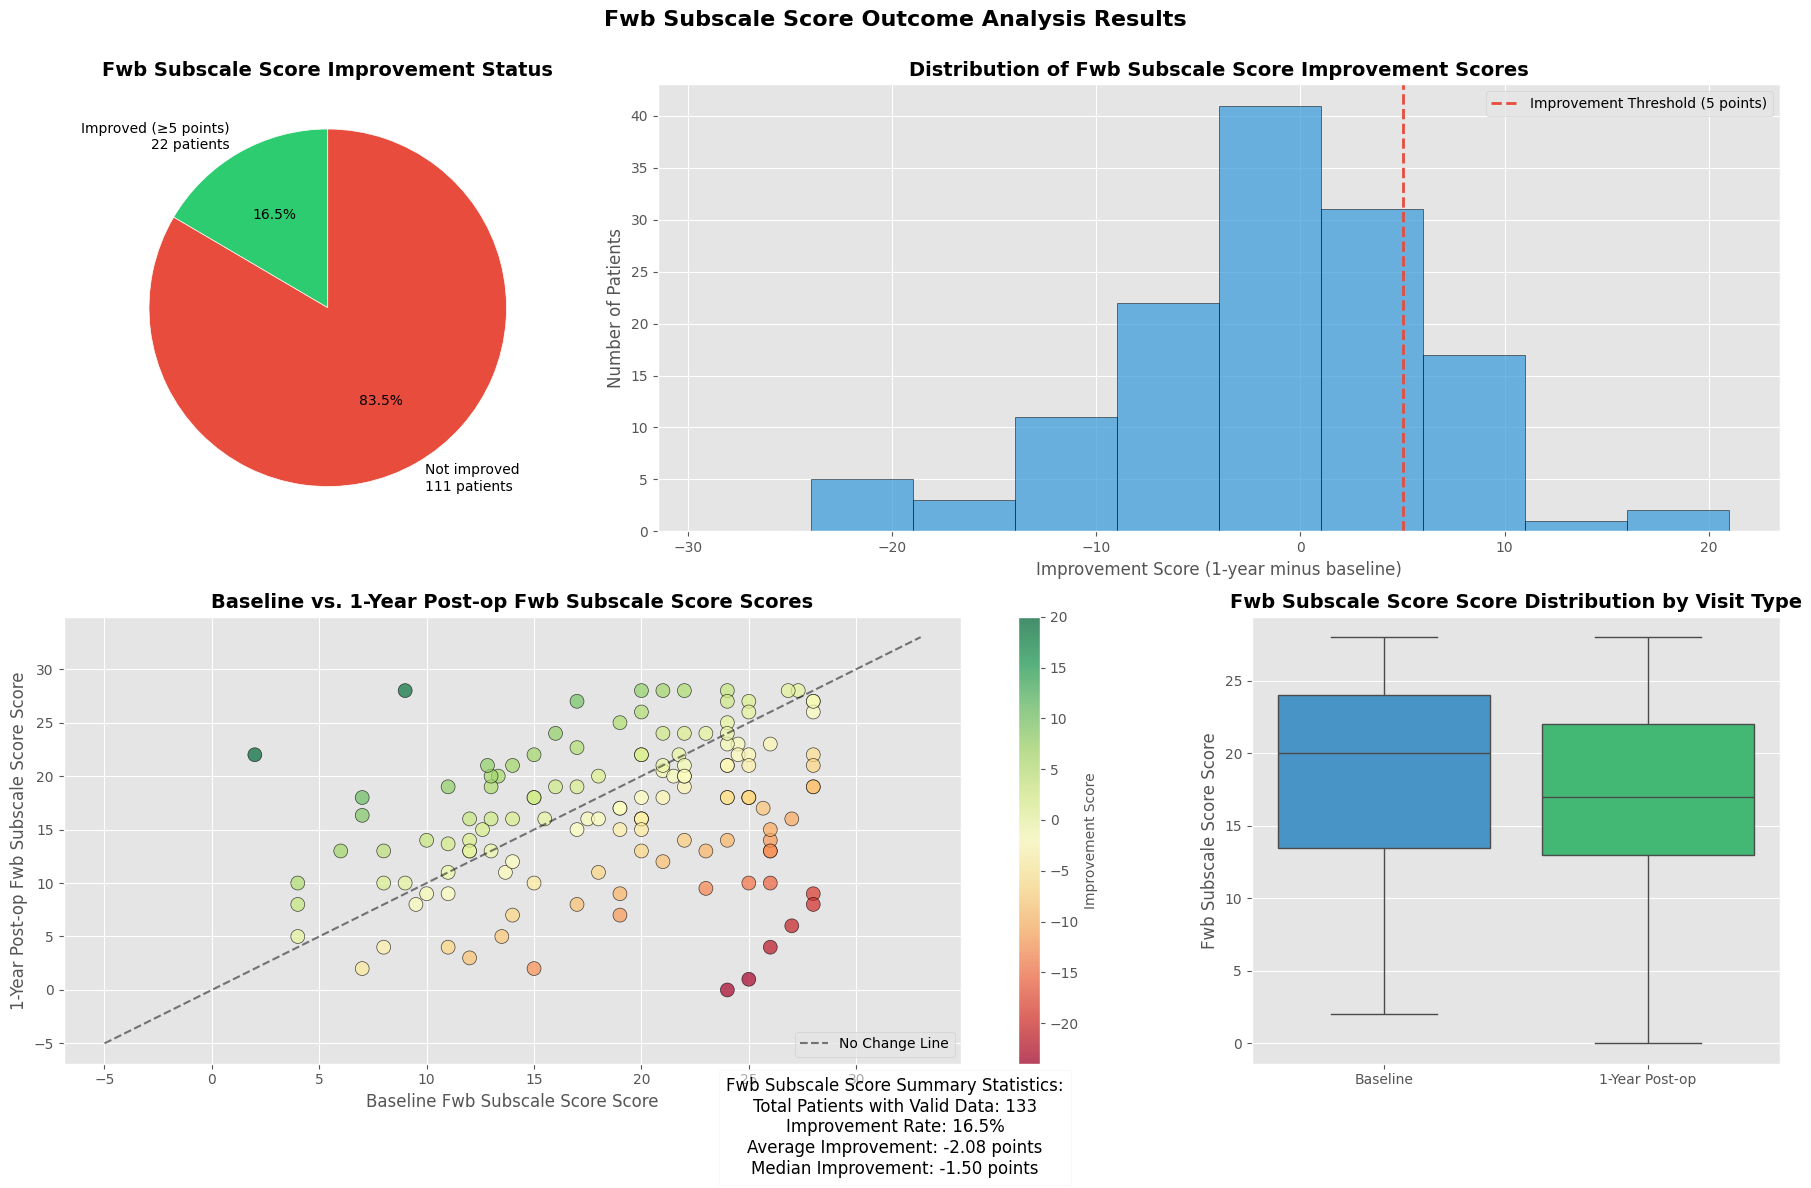

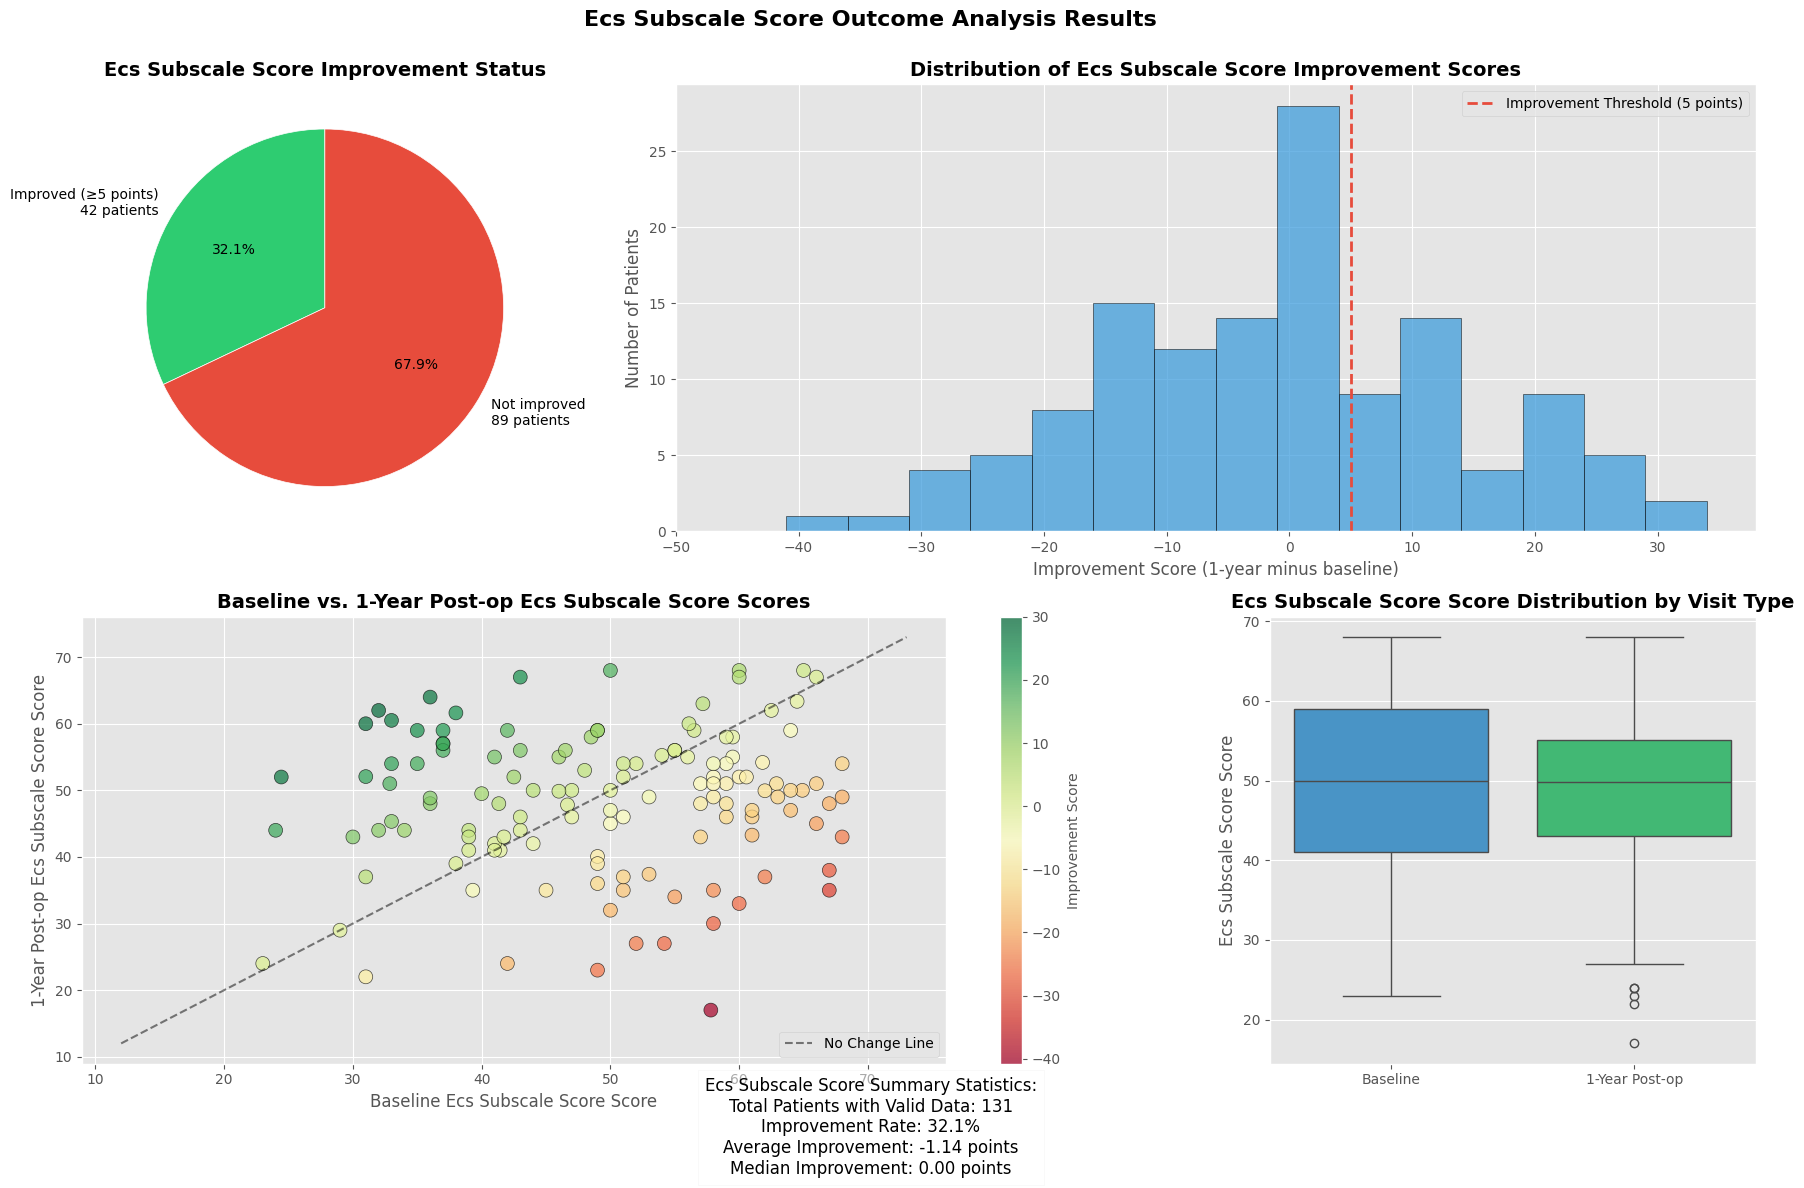

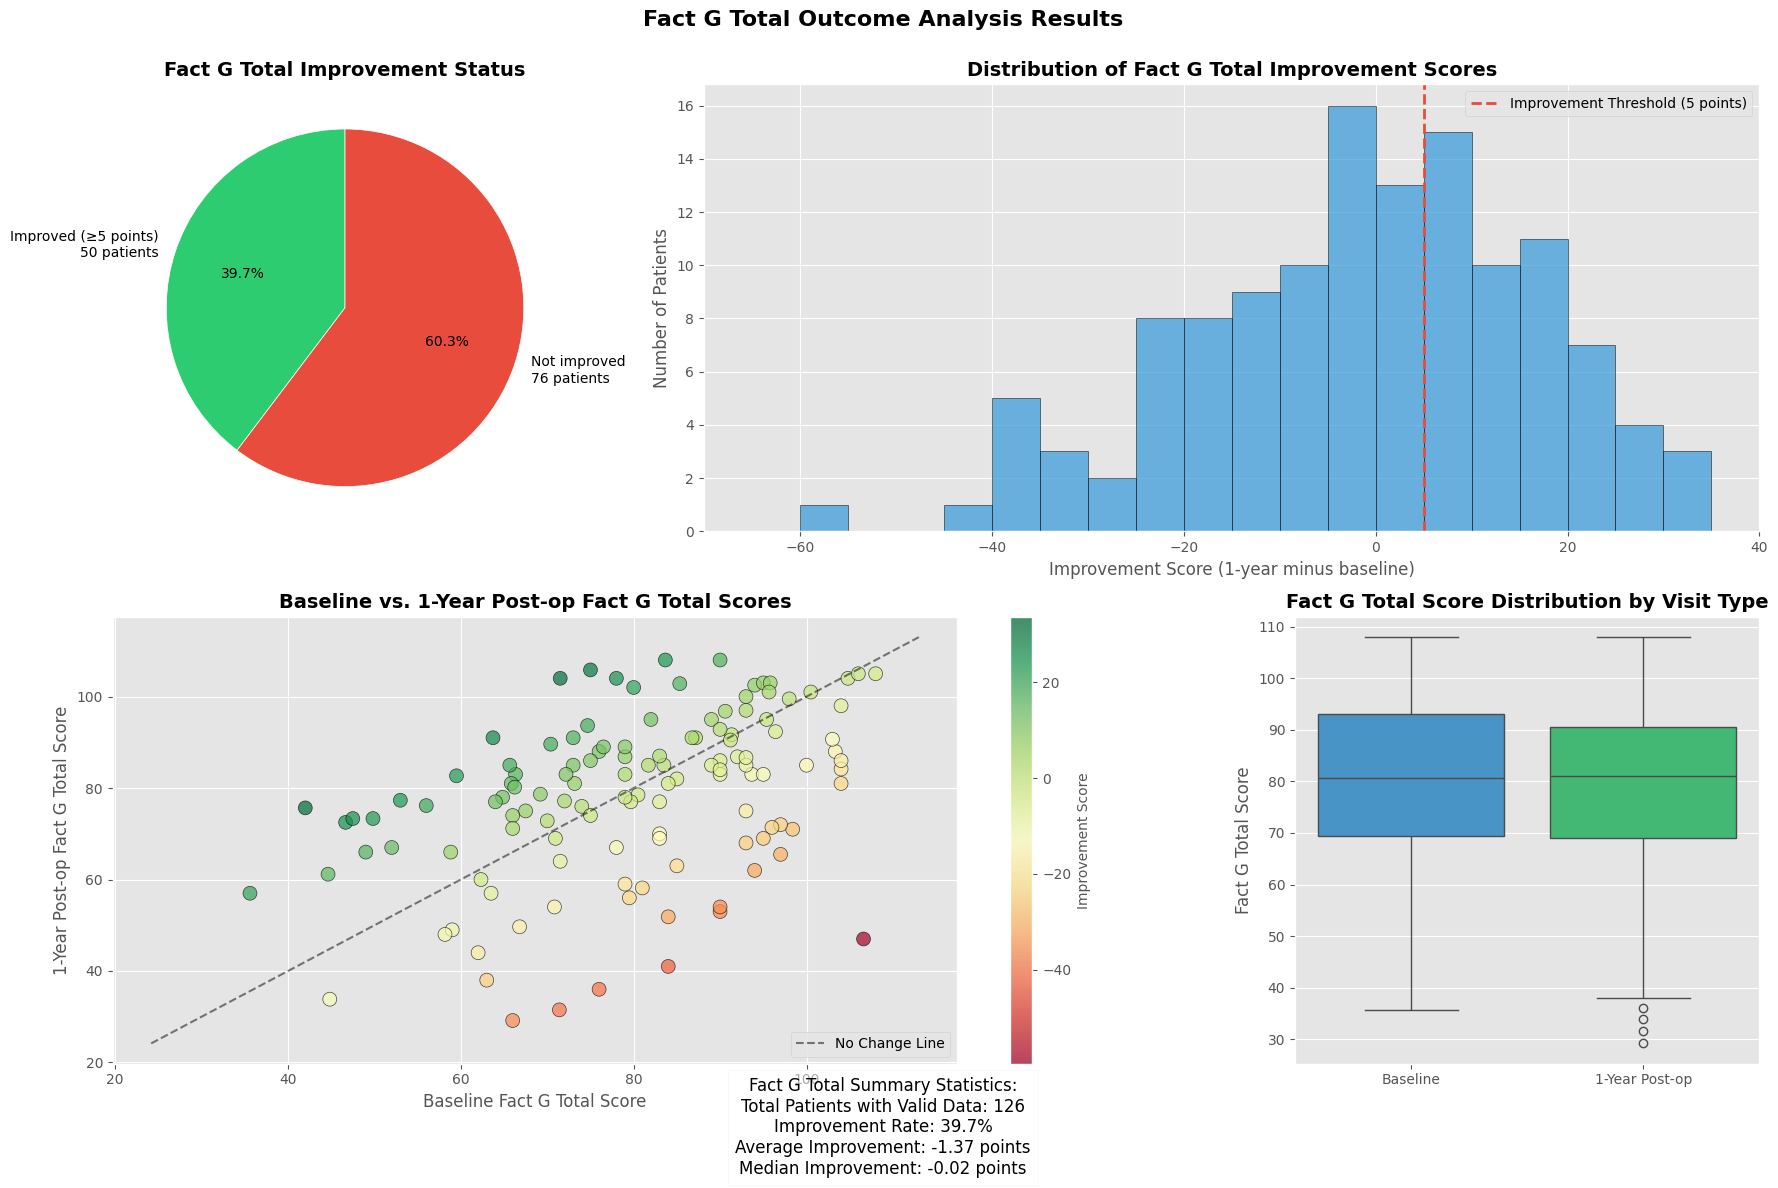

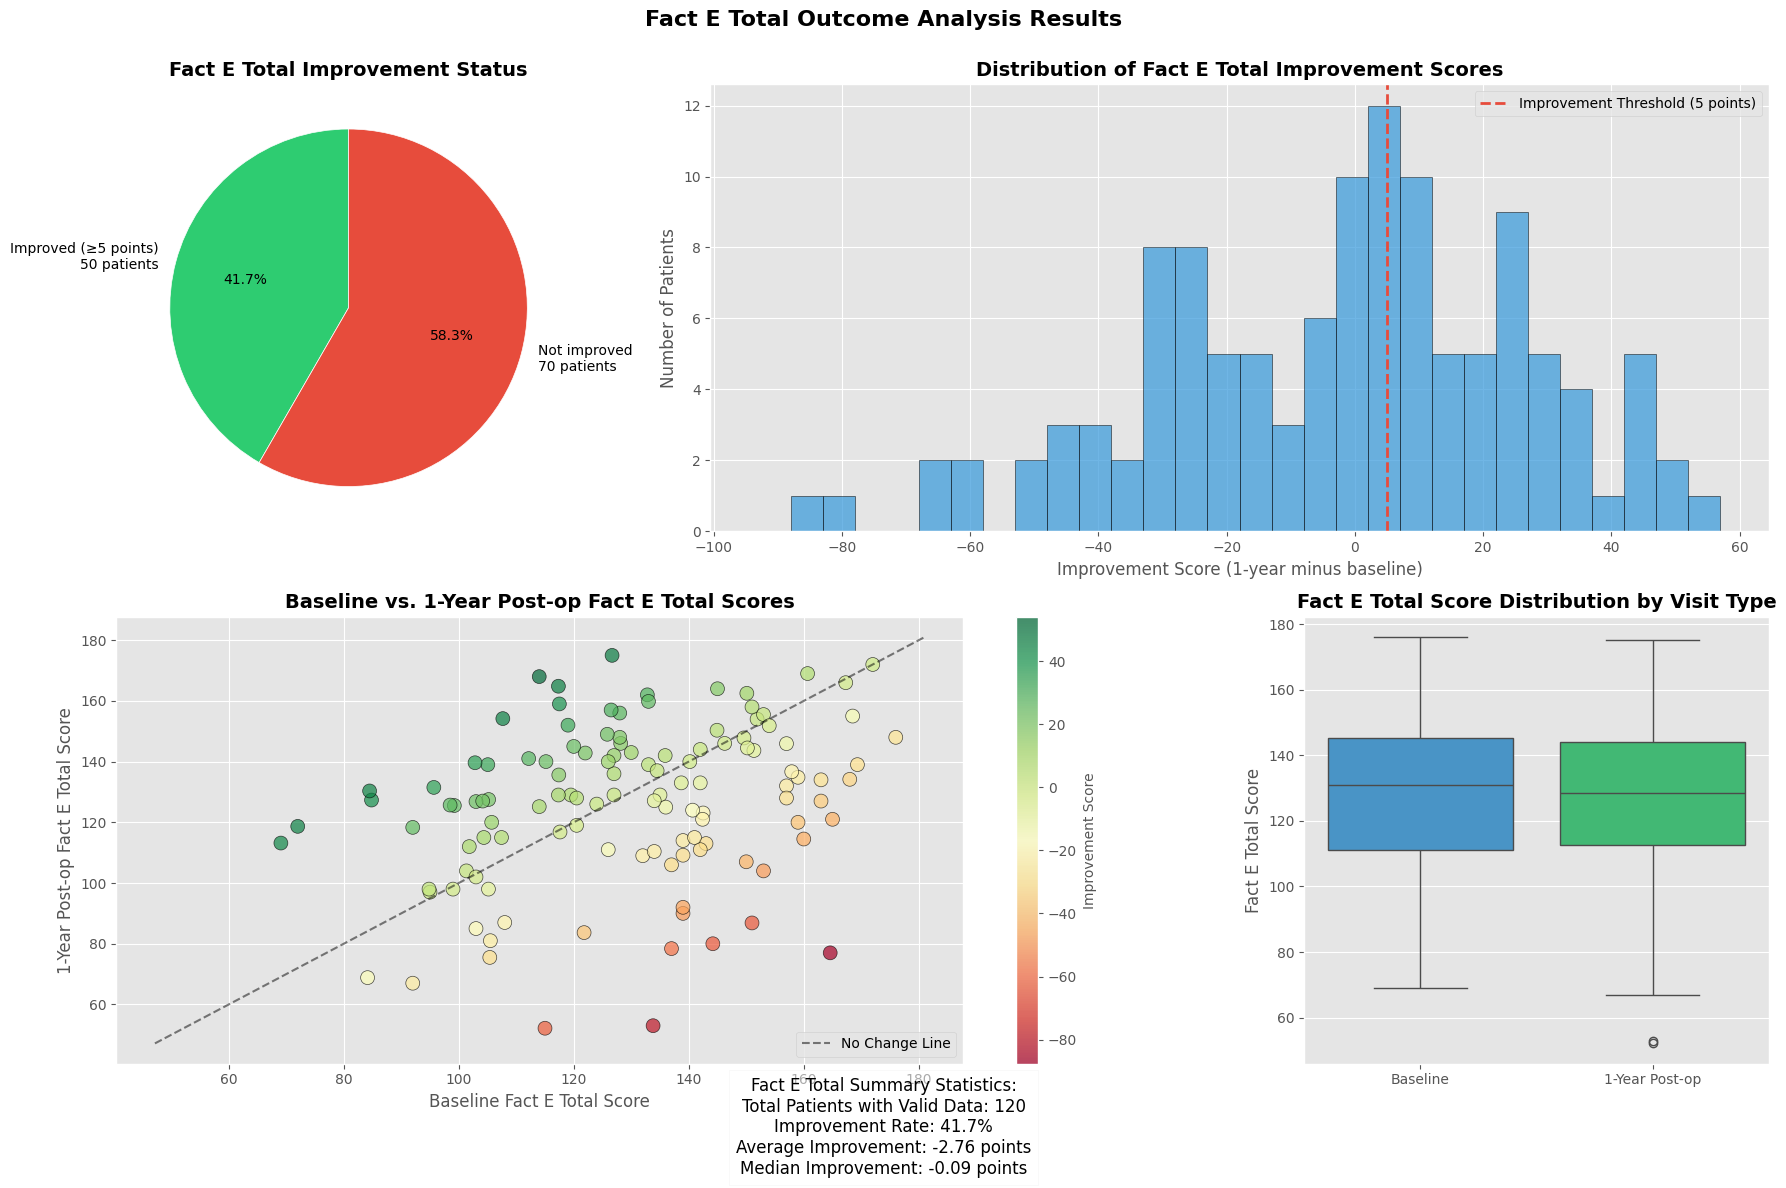

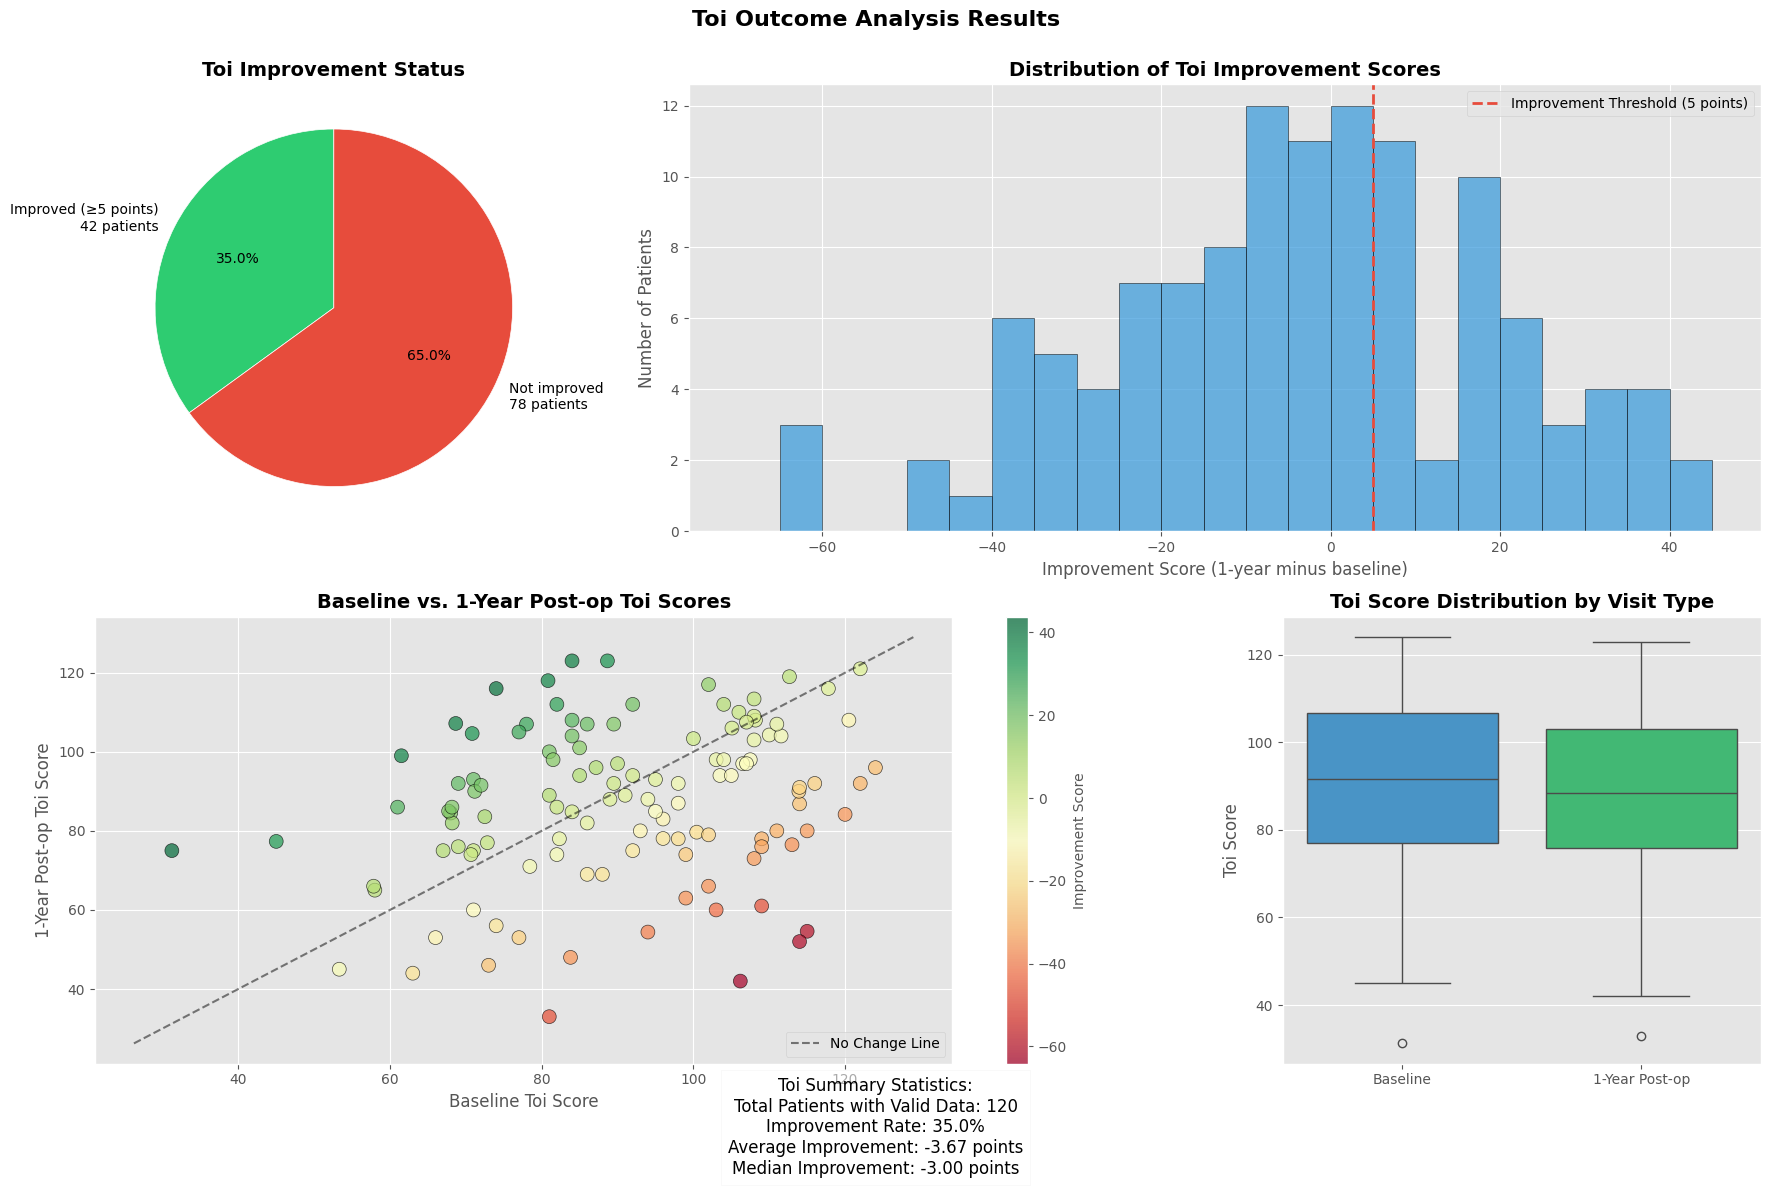

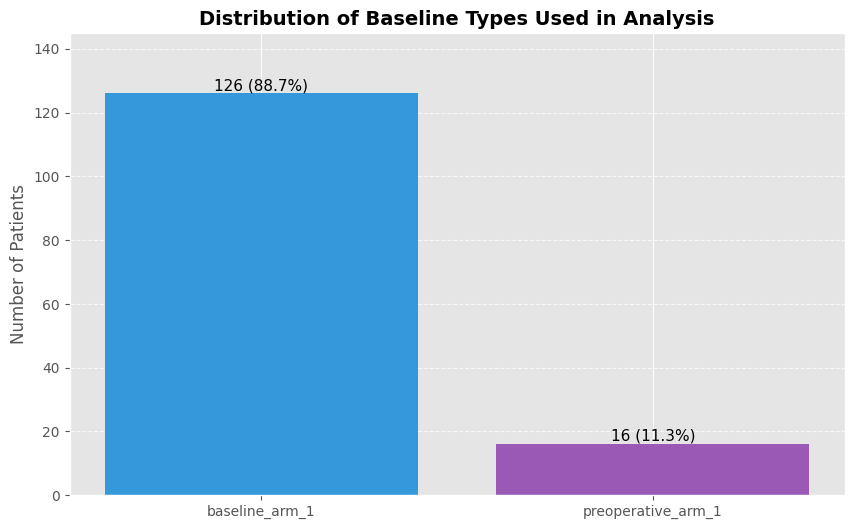

In [12]:
# Assuming results_df is available from the previous analysis
# If you need to recreate it, uncomment and run the code block below:
# filtered_df, results_df = analyze_patient_outcomes(df)

# Set the style
plt.style.use('ggplot')
sns.set_palette("colorblind")

# Define the score types to visualize
score_types = ['pwb_subscale_score', 'swb_subscale_score', 'ewb_subscale_score',
               'fwb_subscale_score', 'ecs_subscale_score', 'fact_g_total',
               'fact_e_total', 'toi']

# Create a separate figure for each score type
for score_type in score_types:
    # Create a figure with multiple subplots for the current score type
    fig = plt.figure(figsize=(18, 12))
    
    # 1. Pie chart showing percentage of patients who improved vs. didn't improve
    ax1 = plt.subplot2grid((2, 3), (0, 0))
    improved_count = results_df[f'{score_type}_has_improved'].sum()
    not_improved_count = results_df[f'{score_type}_has_improved'].notna().sum() - improved_count
    improvement_data = [improved_count, not_improved_count]
    labels = [f'Improved (≥5 points)\n{improved_count} patients', f'Not improved\n{not_improved_count} patients']
    colors = ['#2ecc71', '#e74c3c']
    ax1.pie(improvement_data, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'edgecolor': 'white'})
    ax1.set_title(f'{score_type.replace("_", " ").title()} Improvement Status', fontsize=14, fontweight='bold')

    # 2. Bar chart showing the distribution of improvement scores
    ax2 = plt.subplot2grid((2, 3), (0, 1), colspan=2)
    improvement_col = f'{score_type}_improvement'
    if improvement_col in results_df.columns:
        bins = np.arange(np.floor(results_df[improvement_col].min()) - 5, 
                        np.ceil(results_df[improvement_col].max()) + 5, 5)
        ax2.hist(results_df[improvement_col].dropna(), bins=bins, color='#3498db', alpha=0.7, edgecolor='black')
    ax2.axvline(x=5, color='#e74c3c', linestyle='--', linewidth=2, label='Improvement Threshold (5 points)')
    ax2.set_xlabel('Improvement Score (1-year minus baseline)', fontsize=12)
    ax2.set_ylabel('Number of Patients', fontsize=12)
    ax2.set_title(f'Distribution of {score_type.replace("_", " ").title()} Improvement Scores', fontsize=14, fontweight='bold')
    ax2.legend()

    # 3. Scatter plot of baseline vs one-year scores
    ax3 = plt.subplot2grid((2, 3), (1, 0), colspan=2)
    scatter = ax3.scatter(results_df[f'{score_type}_baseline'], results_df[f'{score_type}_one_year'], 
                         c=results_df[f'{score_type}_improvement'], cmap='RdYlGn', s=100, alpha=0.7, edgecolor='black')
    min_val = min(results_df[f'{score_type}_baseline'].min(), results_df[f'{score_type}_one_year'].min()) - 5
    max_val = max(results_df[f'{score_type}_baseline'].max(), results_df[f'{score_type}_one_year'].max()) + 5
    ax3.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='No Change Line')
    ax3.set_xlabel(f'Baseline {score_type.replace("_", " ").title()} Score', fontsize=12)
    ax3.set_ylabel(f'1-Year Post-op {score_type.replace("_", " ").title()} Score', fontsize=12)
    ax3.set_title(f'Baseline vs. 1-Year Post-op {score_type.replace("_", " ").title()} Scores', fontsize=14, fontweight='bold')
    cbar = plt.colorbar(scatter, ax=ax3)
    cbar.set_label('Improvement Score', fontsize=10)
    ax3.legend(loc='lower right')

    # 4. Box plot of scores by visit type
    ax4 = plt.subplot2grid((2, 3), (1, 2))
    box_data = pd.DataFrame({
        'Baseline': results_df[f'{score_type}_baseline'],
        '1-Year Post-op': results_df[f'{score_type}_one_year']
    })
    sns.boxplot(data=box_data, ax=ax4, palette=['#3498db', '#2ecc71'])
    ax4.set_ylabel(f'{score_type.replace("_", " ").title()} Score', fontsize=12)
    ax4.set_title(f'{score_type.replace("_", " ").title()} Score Distribution by Visit Type', fontsize=14, fontweight='bold')

    # Add a summary text box
    improved_count = results_df[f'{score_type}_has_improved'].sum()
    valid_count = results_df[f'{score_type}_improvement'].notna().sum()
    improvement_rate = (improved_count / valid_count * 100) if valid_count > 0 else 0
    avg_improvement = results_df[f'{score_type}_improvement'].mean()
    median_improvement = results_df[f'{score_type}_improvement'].median()
    plt.figtext(0.5, 0.01, 
               f"{score_type.replace('_', ' ').title()} Summary Statistics:\n"
               f"Total Patients with Valid Data: {valid_count}\n"
               f"Improvement Rate: {improvement_rate:.1f}%\n"
               f"Average Improvement: {avg_improvement:.2f} points\n"
               f"Median Improvement: {median_improvement:.2f} points",
               ha="center", fontsize=12, bbox={"facecolor":"white", "alpha":0.5, "pad":5})

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.suptitle(f'{score_type.replace("_", " ").title()} Outcome Analysis Results', fontsize=16, fontweight='bold', y=0.98)

    # Display the plot for this score type
    plt.show()

# Create additional visualization for baseline type distribution (unchanged)
plt.figure(figsize=(10, 6))
baseline_counts = results_df['baseline_type'].value_counts()
bars = plt.bar(baseline_counts.index, baseline_counts.values, color=['#3498db', '#9b59b6'])

# Add data labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height} ({height/len(results_df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11)

plt.title('Distribution of Baseline Types Used in Analysis', fontsize=14, fontweight='bold')
plt.ylabel('Number of Patients', fontsize=12)
plt.ylim(0, baseline_counts.max() * 1.15)  # Add some space for the labels
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Data set up

In [13]:
results_df = pd.read_csv("results.csv")

In [14]:
results_df

,id,baseline_type,pwb_subscale_score_baseline,pwb_subscale_score_one_year,pwb_subscale_score_improvement,pwb_subscale_score_has_improved,swb_subscale_score_baseline,swb_subscale_score_one_year,swb_subscale_score_improvement,swb_subscale_score_has_improved,...,fact_g_total_improvement,fact_g_total_has_improved,fact_e_total_baseline,fact_e_total_one_year,fact_e_total_improvement,fact_e_total_has_improved,toi_baseline,toi_one_year,toi_improvement,toi_has_improved
0,32,baseline_arm_1,24.5,27.0,2.5,False,22.0,28.0,6.0,True,...,32.5,True,117.5,159.0,41.5,True,89.5,107.0,17.5,True
1,76,preoperative_arm_1,7.0,7.0,0.0,False,23.0,21.0,-2.0,False,...,-10.0,False,95.0,97.0,2.0,False,58.0,65.0,7.0,True
2,125,baseline_arm_1,21.0,22.0,1.0,False,17.5,21.0,3.5,False,...,7.5,True,119.5,129.0,9.5,True,81.0,89.0,8.0,True
3,160,baseline_arm_1,21.0,28.0,7.0,True,20.0,22.0,2.0,False,...,13.0,True,119.0,152.0,33.0,True,78.0,107.0,29.0,True
4,198,baseline_arm_1,25.0,26.5,1.5,False,13.0,18.0,5.0,True,...,12.0,True,133.0,139.0,6.0,True,103.0,98.0,-5.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137,1571,baseline_arm_1,26.0,16.0,-10.0,False,28.0,28.0,0.0,False,...,-26.0,False,153.0,104.0,-49.0,False,109.0,61.0,-48.0,False
138,1572,baseline_arm_1,27.0,24.0,-3.0,False,13.0,21.0,8.0,True,...,-1.0,False,141.0,115.0,-26.0,False,109.0,76.0,-33.0,False
139,1615,baseline_arm_1,23.0,19.0,-4.0,False,24.0,22.0,-2.0,False,...,-1.0,False,126.0,111.0,-15.0,False,86.0,69.0,-17.0,False
140,1621,baseline_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
results_df = results_df[['id', 'fact_e_total_baseline', 'fact_e_total_one_year', 'fact_e_total_improvement', 'fact_e_total_has_improved']]


# Rename the specified columns
results_df = results_df.rename(columns={
    "fact_e_total_baseline": "Baseline",
    "fact_e_total_one_year": "Postop1yr",
    "fact_e_total_improvement": "Change"
})

results_df["Trend Category"] = results_df['fact_e_total_has_improved'].map({True: 'Improved', False: 'Decreased/Same'}).fillna(results_df['fact_e_total_has_improved'])

results_df = results_df.dropna(subset=['Trend Category'])
results_df["Trend Category"].value_counts()


Trend Category
Decreased/Same    70
Improved          50
Name: count, dtype: int64

In [16]:
# Set 'id' column as the index
results_df = results_df.set_index("id")

# Rename the index and columns to match the second image
results_df.index.name = "id"
results_df.columns.name = "Timepoint"

results_df
score_comparison=results_df.copy()

# statistically significantly associated with 0) FACT E baseline 

In [17]:
score_comparison

Timepoint,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,
32,117.5,159.000000,41.500000,True,Improved
76,95.0,97.000000,2.000000,False,Decreased/Same
125,119.5,129.000000,9.500000,True,Improved
160,119.0,152.000000,33.000000,True,Improved
198,133.0,139.000000,6.000000,True,Improved
...,...,...,...,...,...
1560,154.0,151.833333,-2.166667,False,Decreased/Same
1566,150.0,107.000000,-43.000000,False,Decreased/Same
1571,153.0,104.000000,-49.000000,False,Decreased/Same


In [18]:
# Create a clean dataframe with no missing values in Baseline
merged_df_baseline = score_comparison.copy()
merged_df_removedNA_baseline = merged_df_baseline.dropna(subset=["Baseline"])
merged_df_expanded_baseline = merged_df_removedNA_baseline.drop_duplicates()
merged_df_removedNA_baseline = merged_df_expanded_baseline.copy()
merged_df_removedNA_baseline

Timepoint,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,
32,117.5,159.000000,41.500000,True,Improved
76,95.0,97.000000,2.000000,False,Decreased/Same
125,119.5,129.000000,9.500000,True,Improved
160,119.0,152.000000,33.000000,True,Improved
198,133.0,139.000000,6.000000,True,Improved
...,...,...,...,...,...
1560,154.0,151.833333,-2.166667,False,Decreased/Same
1566,150.0,107.000000,-43.000000,False,Decreased/Same
1571,153.0,104.000000,-49.000000,False,Decreased/Same


In [19]:

# Show summary statistics by improvement group
print("\nBaseline scores by Trend Category:")
print(merged_df_removedNA_baseline.groupby("Trend Category")["Baseline"].describe())


Baseline scores by Trend Category:
                count        mean        std        min         25%  \
Trend Category                                                        
Decreased/Same   70.0  138.144791  22.180625  84.145833  126.250000   
Improved         50.0  116.570823  19.006636  69.070833  104.538889   

                       50%     75%         max  
Trend Category                                  
Decreased/Same  140.833333  153.75  176.000000  
Improved        117.450000  127.75  160.666667  


In [20]:
# Perform Mann-Whitney U test to compare Baseline scores between groups
improved_baseline = merged_df_removedNA_baseline[merged_df_removedNA_baseline["Trend Category"] == "Improved"]["Baseline"]
decreased_same_baseline = merged_df_removedNA_baseline[merged_df_removedNA_baseline["Trend Category"] == "Decreased/Same"]["Baseline"]

stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
print(f"\nMann-Whitney U test:")
print(f"Statistic: {stat}")
print(f"p-value: {p_value}")


Mann-Whitney U test:
Statistic: 783.0
p-value: 2.6735533877447416e-07


In [21]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_baseline["Trend Category_binary"] = merged_df_removedNA_baseline["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Logistic regression with Baseline as predictor
X = sm.add_constant(merged_df_removedNA_baseline["Baseline"])
y = merged_df_removedNA_baseline["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.565935
         Iterations 6

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  120
Model:                             Logit   Df Residuals:                      118
Method:                              MLE   Df Model:                            1
Date:                   Mon, 05 May 2025   Pseudo R-squ.:                  0.1668
Time:                           00:30:38   Log-Likelihood:                -67.912
converged:                          True   LL-Null:                       -81.503
Covariance Type:               nonrobust   LLR p-value:                 1.852e-07
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.7348      1.339      4.283      0.000


Odds Ratio for a 10-point increase in baseline score: 0.621
95% CI for a 10-point increase in baseline score: (0.506, 0.763)


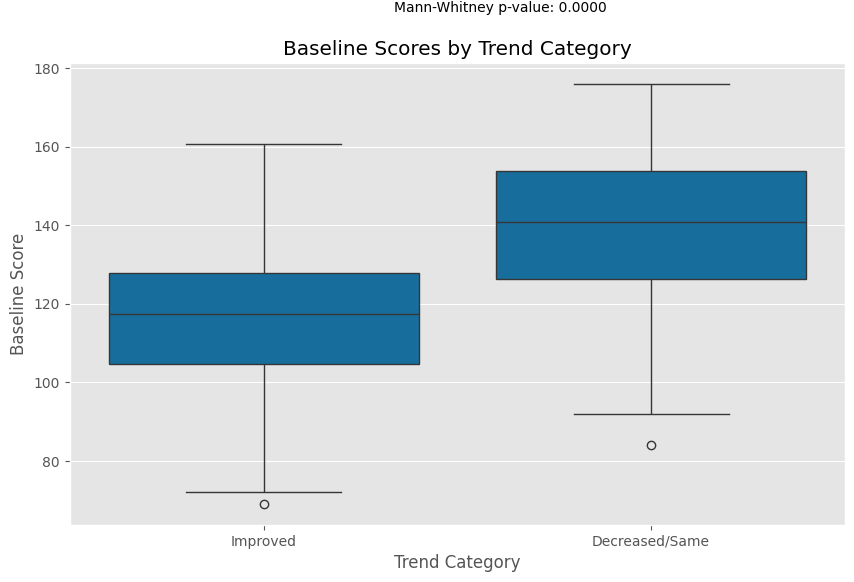

In [22]:
# Calculate odds ratio for a 10-point increase in baseline score
baseline_coef = result.params["Baseline"]
odds_ratio_10points = np.exp(baseline_coef * 10)
print(f"\nOdds Ratio for a 10-point increase in baseline score: {odds_ratio_10points:.3f}")

# Calculate confidence interval for the odds ratio
baseline_conf_int = result.conf_int().loc["Baseline"]
lower_ci_10points = np.exp(baseline_conf_int[0] * 10)
upper_ci_10points = np.exp(baseline_conf_int[1] * 10)
print(f"95% CI for a 10-point increase in baseline score: ({lower_ci_10points:.3f}, {upper_ci_10points:.3f})")

# Visualize with boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="Baseline", data=merged_df_removedNA_baseline)
plt.title("Baseline Scores by Trend Category")
plt.xlabel("Trend Category")
plt.ylabel("Baseline Score")
plt.annotate(f"Mann-Whitney p-value: {p_value:.4f}", xy=(0.5, 0.95), 
             xycoords='figure fraction', ha='center')
plt.show()

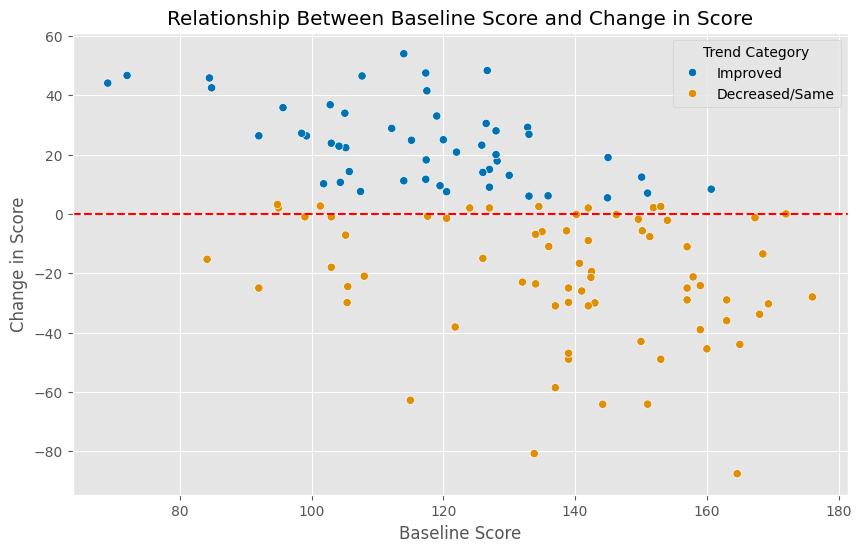

In [23]:

# Create a scatter plot of Baseline vs Change
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Baseline", y="Change", 
                hue="Trend Category", 
                data=merged_df_removedNA_baseline)
plt.title("Relationship Between Baseline Score and Change in Score")
plt.xlabel("Baseline Score")
plt.ylabel("Change in Score")
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at y=0
plt.legend(title="Trend Category")
plt.show()

# sensitivity analysis 0) FACT E baseline 

In [24]:
score_comparison

Timepoint,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,
32,117.5,159.000000,41.500000,True,Improved
76,95.0,97.000000,2.000000,False,Decreased/Same
125,119.5,129.000000,9.500000,True,Improved
160,119.0,152.000000,33.000000,True,Improved
198,133.0,139.000000,6.000000,True,Improved
...,...,...,...,...,...
1560,154.0,151.833333,-2.166667,False,Decreased/Same
1566,150.0,107.000000,-43.000000,False,Decreased/Same
1571,153.0,104.000000,-49.000000,False,Decreased/Same


Sensitivity Analysis Results:
    threshold  improvement_rate  mann_whitney_p  logistic_p  odds_ratio
0           0          0.500000    3.754009e-07    0.000007    0.954936
1           1          0.491667    7.091347e-08    0.000002    0.950497
2           2          0.491667    7.091347e-08    0.000002    0.950497
3           3          0.425000    6.304828e-08    0.000002    0.950104
4           4          0.416667    2.673553e-07    0.000005    0.953519
5           5          0.416667    2.673553e-07    0.000005    0.953519
6           6          0.408333    1.079553e-07    0.000003    0.951530
7           7          0.391667    6.059379e-08    0.000002    0.949567
8           8          0.366667    5.994109e-08    0.000002    0.948990
9           9          0.358333    1.085218e-08    0.000001    0.944446
10         10          0.341667    1.630609e-08    0.000001    0.944384


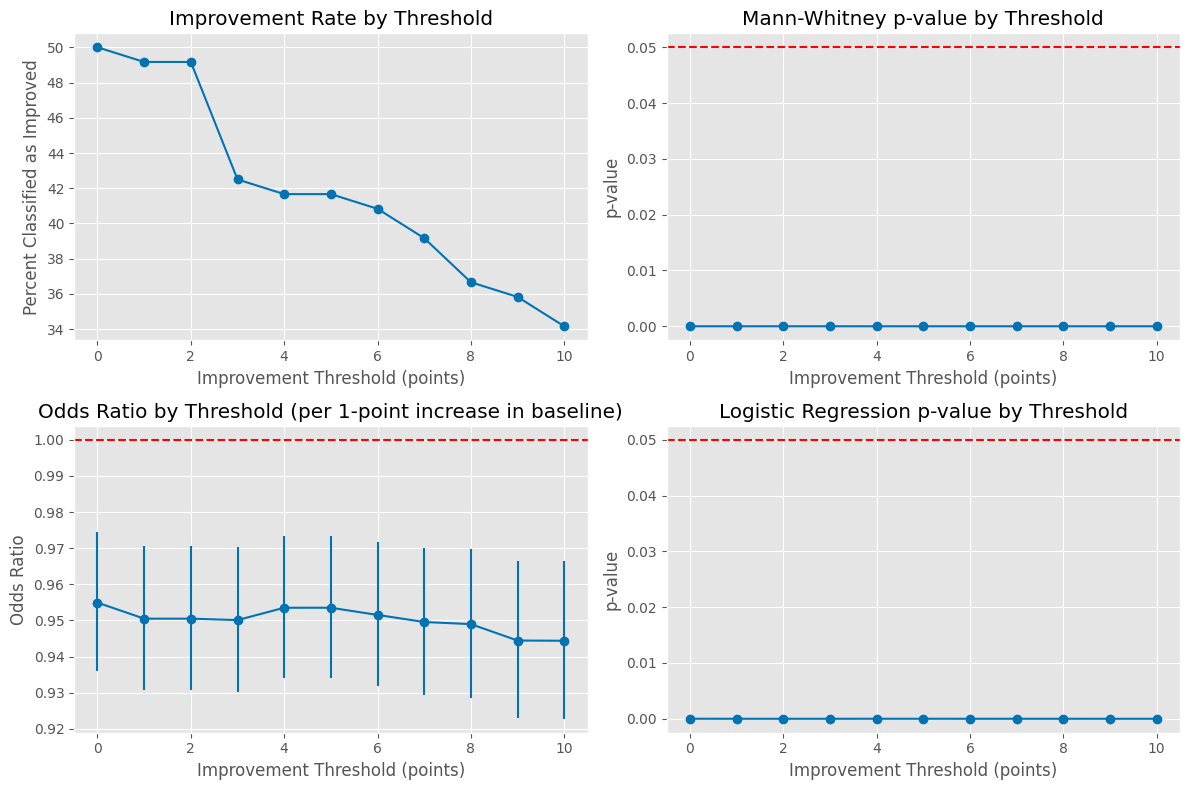


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              60                    60   50.000000   
1           1              59                    61   49.166667   
2           2              59                    61   49.166667   
3           3              51                    69   42.500000   
4           4              50                    70   41.666667   
5           5              50                    70   41.666667   
6           6              49                    71   40.833333   
7           7              47                    73   39.166667   
8           8              44                    76   36.666667   
9           9              43                    77   35.833333   
10         10              41                    79   34.166667   

    Decreased/Same %  
0          50.000000  
1          50.833333  
2          50.833333  
3          57.500000  
4          58.333333  
5          58.33

In [25]:
# Assuming score_comparison contains the necessary columns: id, Baseline, Change
# Let's create a function to perform the analysis at different thresholds

def analyze_improvement_threshold(data, threshold):
    """
    Analyze how the improvement threshold affects classification and baseline score relationship
    
    Parameters:
    data: DataFrame containing Baseline and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Mann-Whitney U test
    improved_baseline = df[df["Improved"]]["Baseline"]
    decreased_same_baseline = df[~df["Improved"]]["Baseline"]
    
    if len(improved_baseline) > 0 and len(decreased_same_baseline) > 0:
        stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
    else:
        stat, p_value = None, None
    
    # Logistic regression
    X = sm.add_constant(df["Baseline"])
    y = df["Trend Category_binary"]
    
    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        baseline_coef = result.params["Baseline"]
        baseline_p = result.pvalues["Baseline"]
        odds_ratio = np.exp(baseline_coef)
        
        # Confidence intervals
        baseline_conf_int = result.conf_int().loc["Baseline"]
        lower_ci = np.exp(baseline_conf_int[0])
        upper_ci = np.exp(baseline_conf_int[1])
    except:
        baseline_coef = None
        baseline_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "mann_whitney_stat": stat,
        "mann_whitney_p": p_value,
        "logistic_coef": baseline_coef,
        "logistic_p": baseline_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean = score_comparison.dropna(subset=["Baseline", "Change"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_improvement_threshold(merged_df_clean, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "mann_whitney_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["improvement_rate"] * 100, 'o-')
plt.title("Improvement Rate by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Percent Classified as Improved")
plt.grid(True)

# Plot p-values from Mann-Whitney test
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mann_whitney_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Mann-Whitney p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (per 1-point increase in baseline)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

# statistically significantly associated with 1) charlson comorbidity index (cci_total)

In [26]:
# Merge score_comparison with cci_total data
merged_df_cci = score_comparison.merge(filtered_df[["id", "cci_total"]], on="id", how="left")

# Remove rows where cci_total is missing
merged_df_removedNA_cci = merged_df_cci.dropna(subset=["cci_total"])
merged_df_expanded_cci = merged_df_removedNA_cci.drop_duplicates()
merged_df_removedNA_cci = merged_df_expanded_cci.copy()
merged_df_removedNA_cci

,id,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,cci_total
2,32,117.500000,159.000000,41.500000,True,Improved,2.0
39,198,133.000000,139.000000,6.000000,True,Improved,4.0
51,230,133.800000,53.000000,-80.800000,False,Decreased/Same,2.0
58,275,128.166667,146.000000,17.833333,True,Improved,5.0
66,307,105.200000,127.515152,22.315152,True,Improved,3.0
...,...,...,...,...,...,...,...
1281,1560,154.000000,151.833333,-2.166667,False,Decreased/Same,4.0
1290,1566,150.000000,107.000000,-43.000000,False,Decreased/Same,4.0
1298,1571,153.000000,104.000000,-49.000000,False,Decreased/Same,6.0
1312,1572,141.000000,115.000000,-26.000000,False,Decreased/Same,4.0


In [27]:
# Separate hospital cci values by Trend Category
cci_improved = merged_df_removedNA_cci.loc[merged_df_removedNA_cci["Trend Category"] == "Improved", "cci_total"]
cci_not_improved = merged_df_removedNA_cci.loc[merged_df_removedNA_cci["Trend Category"] == "Decreased/Same", "cci_total"]

# Mann-Whitney U Test
u_stat, p_value = stats.mannwhitneyu(cci_improved, cci_not_improved)

print(f"Mann-Whitney U Test statistic: {u_stat}")
print(f"Mann-Whitney U Test p-value: {p_value}")

Mann-Whitney U Test statistic: 1263.5
Mann-Whitney U Test p-value: 0.18872037881054493


In [28]:
# Calculate mean cci for each category
avg_cci_improved = cci_improved.mean()
avg_cci_not_improved = cci_not_improved.mean()

print(f"Average cci for Improved: {avg_cci_improved:.2f}")
print(f"Average cci for Not Improved: {avg_cci_not_improved:.2f}")

Average cci for Improved: 4.38
Average cci for Not Improved: 3.83


/tmp/ipykernel_66406/1911050323.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Trend Category", y="cci_total", data=merged_df_removedNA_cci, palette="Set2")


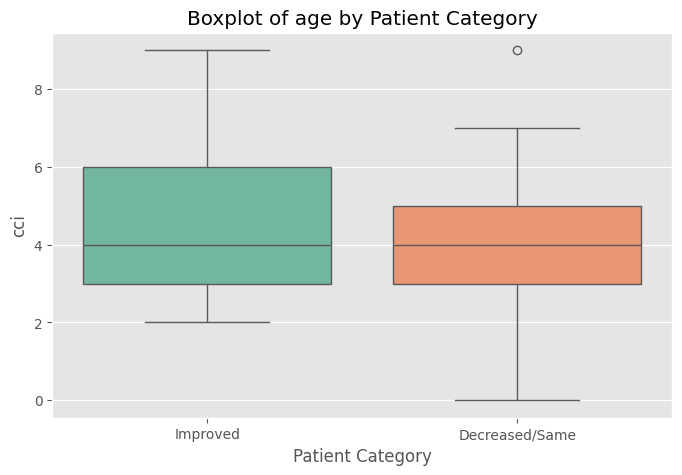

In [29]:
# Encode Trend Category as binary
merged_df_removedNA_cci["Trend Category_binary"] = merged_df_removedNA_cci["Trend Category"].map({"Improved": 1, "Decreased/Same": 0})

## ==== Boxplot ====
plt.figure(figsize=(8, 5))
sns.boxplot(x="Trend Category", y="cci_total", data=merged_df_removedNA_cci, palette="Set2")
plt.xlabel("Patient Category")
plt.ylabel("cci")
plt.title("Boxplot of age by Patient Category")
plt.show()

# sensitivity analysis 1) charlson comorbidity index (cci_total)

In [30]:
merged_df_removedNA_cci

,id,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,cci_total,Trend Category_binary
2,32,117.500000,159.000000,41.500000,True,Improved,2.0,1
39,198,133.000000,139.000000,6.000000,True,Improved,4.0,1
51,230,133.800000,53.000000,-80.800000,False,Decreased/Same,2.0,0
58,275,128.166667,146.000000,17.833333,True,Improved,5.0,1
66,307,105.200000,127.515152,22.315152,True,Improved,3.0,1
...,...,...,...,...,...,...,...,...
1281,1560,154.000000,151.833333,-2.166667,False,Decreased/Same,4.0,0
1290,1566,150.000000,107.000000,-43.000000,False,Decreased/Same,4.0,0
1298,1571,153.000000,104.000000,-49.000000,False,Decreased/Same,6.0,0
1312,1572,141.000000,115.000000,-26.000000,False,Decreased/Same,4.0,0


In [31]:
def analyze_cci_threshold_relationship(data, threshold):
    """
    Analyze how the CCI total score relates to improvement at different thresholds
    
    Parameters:
    data: DataFrame containing Baseline, Change, and cci_total columns
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    
    # Check for missing CCI values
    df = df.dropna(subset=["cci_total"])
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count if total_count > 0 else 0
    
    # Mann-Whitney U test to compare CCI between improved and not improved groups
    improved_cci = df[df["Improved"]]["cci_total"]
    decreased_same_cci = df[~df["Improved"]]["cci_total"]
    
    if len(improved_cci) > 0 and len(decreased_same_cci) > 0:
        stat, p_value = stats.mannwhitneyu(improved_cci, decreased_same_cci)
    else:
        stat, p_value = None, None
    
    # Mean CCI in each group
    mean_cci_improved = improved_cci.mean() if len(improved_cci) > 0 else None
    mean_cci_not_improved = decreased_same_cci.mean() if len(decreased_same_cci) > 0 else None
    
    # Logistic regression
    X = sm.add_constant(df["cci_total"])
    y = df["Improved"].astype(int)
    
    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        cci_coef = result.params["cci_total"]
        cci_p = result.pvalues["cci_total"]
        odds_ratio = np.exp(cci_coef)
        
        # Confidence intervals
        cci_conf_int = result.conf_int().loc["cci_total"]
        lower_ci = np.exp(cci_conf_int[0])
        upper_ci = np.exp(cci_conf_int[1])
    except:
        cci_coef = None
        cci_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "mean_cci_improved": mean_cci_improved,
        "mean_cci_not_improved": mean_cci_not_improved,
        "mann_whitney_stat": stat,
        "mann_whitney_p": p_value,
        "logistic_coef": cci_coef,
        "logistic_p": cci_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Assuming the data from your table is in a DataFrame named df
# For this analysis, we need the columns: Baseline, Postop1yr, Change, cci_total
# (We're using the data you provided in the image)

# Make sure the dataset is clean for analysis
clean_df = merged_df_removedNA_cci.dropna(subset=["Change", "cci_total"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_cci_threshold_relationship(clean_df, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis of CCI Total and Improvement at Different Thresholds:")
print(sensitivity_df[["threshold", "improvement_rate", "mean_cci_improved", 
                      "mean_cci_not_improved", "mann_whitney_p", "odds_ratio"]].round(4))

Sensitivity Analysis of CCI Total and Improvement at Different Thresholds:
    threshold  improvement_rate  mean_cci_improved  mean_cci_not_improved  \
0           0            0.4792             4.3913                 3.7200   
1           1            0.4688             4.4222                 3.7059   
2           2            0.4688             4.4222                 3.7059   
3           3            0.3958             4.4211                 3.7931   
4           4            0.3854             4.3784                 3.8305   
5           5            0.3854             4.3784                 3.8305   
6           6            0.3750             4.4444                 3.8000   
7           7            0.3542             4.5294                 3.7742   
8           8            0.3333             4.5938                 3.7656   
9           9            0.3333             4.5938                 3.7656   
10         10            0.3229             4.5484                 3.8000   



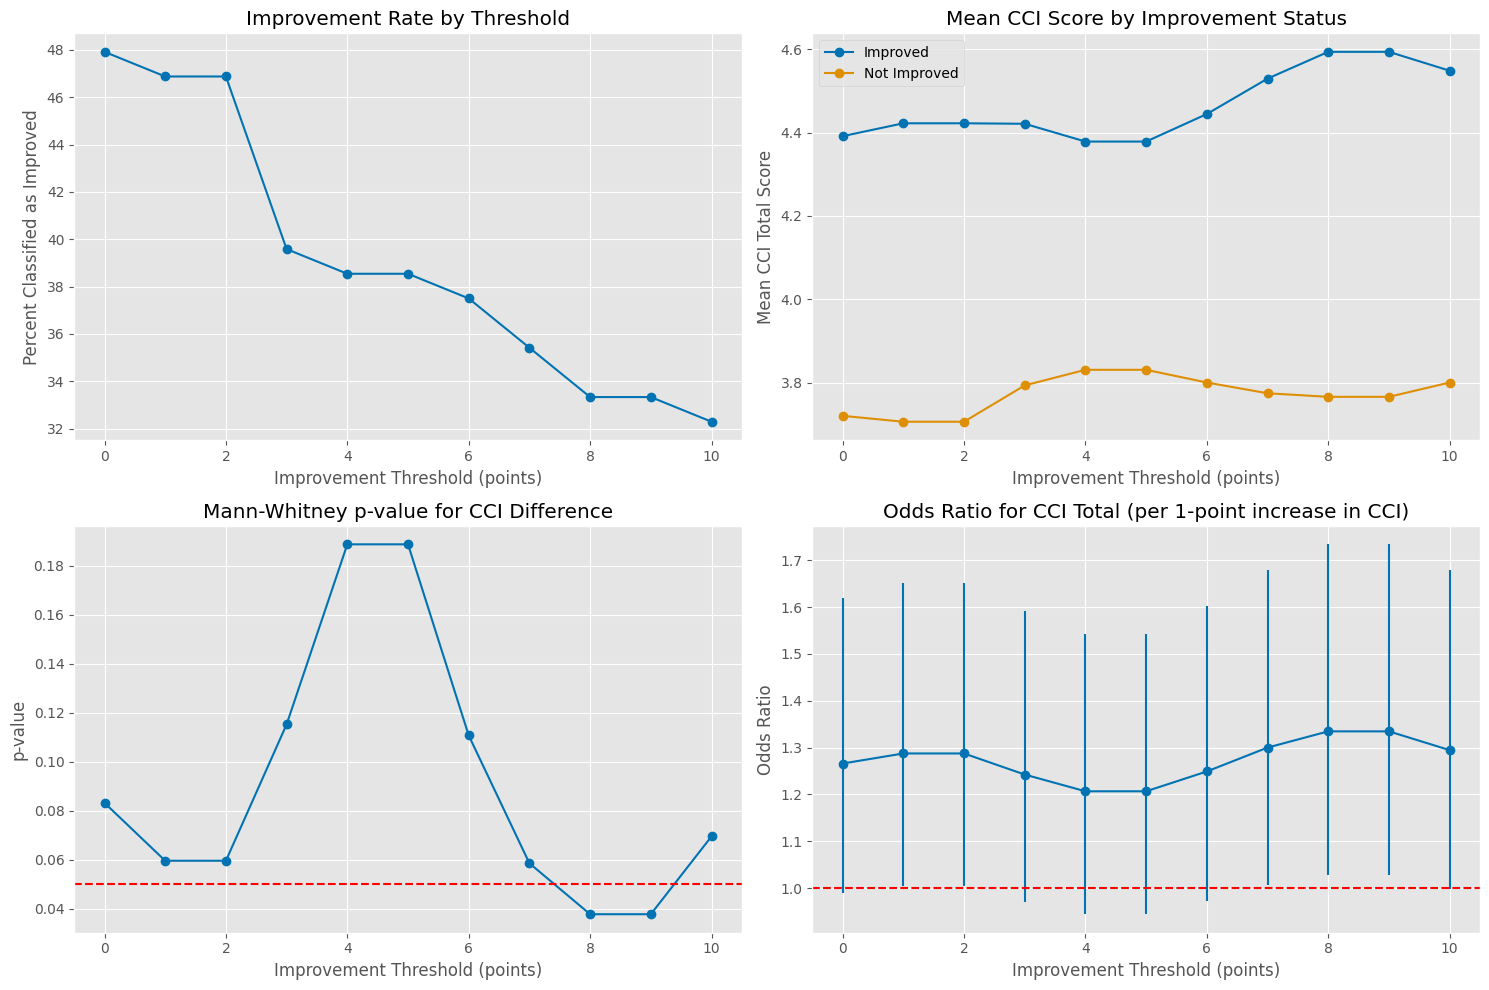

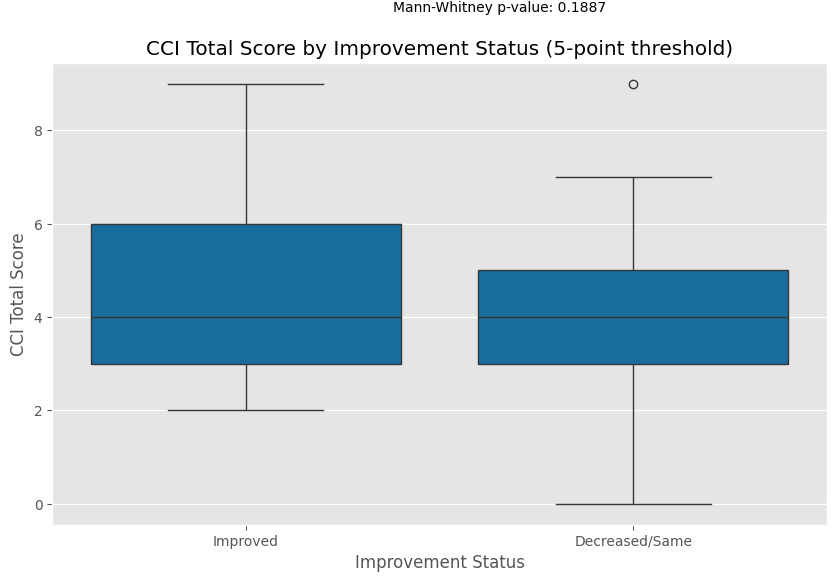

In [32]:
# Create plots to visualize the results
plt.figure(figsize=(15, 10))

# Plot 1: Improvement rate by threshold
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["improvement_rate"] * 100, 'o-')
plt.title("Improvement Rate by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Percent Classified as Improved")
plt.grid(True)

# Plot 2: Mean CCI scores by improvement status across thresholds
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_cci_improved"], 'o-', label='Improved')
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_cci_not_improved"], 'o-', label='Not Improved')
plt.title("Mean CCI Score by Improvement Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Mean CCI Total Score")
plt.legend()
plt.grid(True)

# Plot 3: Mann-Whitney p-values for CCI differences
plt.subplot(2, 2, 3)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mann_whitney_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Mann-Whitney p-value for CCI Difference")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot 4: Odds ratios from logistic regression
plt.subplot(2, 2, 4)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio for CCI Total (per 1-point increase in CCI)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

plt.tight_layout()
plt.show()

# Additional analysis: Create boxplots of CCI by improvement status at the 5-point threshold
threshold_5 = clean_df.copy()
threshold_5["Improved"] = threshold_5["Change"] >= 5
threshold_5["Trend Category"] = threshold_5["Improved"].map({True: "Improved", False: "Decreased/Same"})

plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="cci_total", data=threshold_5)
plt.title("CCI Total Score by Improvement Status (5-point threshold)")
plt.xlabel("Improvement Status")
plt.ylabel("CCI Total Score")

# Perform Mann-Whitney test at the 5-point threshold specifically
improved_cci_5 = threshold_5[threshold_5["Improved"]]["cci_total"]
not_improved_cci_5 = threshold_5[~threshold_5["Improved"]]["cci_total"]
stat_5, p_value_5 = stats.mannwhitneyu(improved_cci_5, not_improved_cci_5)

plt.annotate(f"Mann-Whitney p-value: {p_value_5:.4f}", xy=(0.5, 0.95), 
             xycoords='figure fraction', ha='center')
plt.show()

# statistically significantly associated with 2) age (age_diagnosis)

In [33]:
# Merge score_comparison with los data
merged_df_age = score_comparison.merge(filtered_df[["id", "age_diagnosis"]], on="id", how="left")

# Remove rows where los is missing
merged_df_removedNA_age = merged_df_age.dropna(subset=["age_diagnosis"])
merged_df_expanded_age = merged_df_removedNA_age.drop_duplicates()
merged_df_removedNA_age = merged_df_expanded_age.copy()
merged_df_removedNA_age

,id,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,age_diagnosis
1,32,117.5,159.000000,41.500000,True,Improved,29.722718
12,76,95.0,97.000000,2.000000,False,Decreased/Same,57.597350
26,125,119.5,129.000000,9.500000,True,Improved,64.110830
32,160,119.0,152.000000,33.000000,True,Improved,50.804602
41,198,133.0,139.000000,6.000000,True,Improved,66.229970
...,...,...,...,...,...,...,...
1284,1560,154.0,151.833333,-2.166667,False,Decreased/Same,66.599588
1292,1566,150.0,107.000000,-43.000000,False,Decreased/Same,69.876863
1297,1571,153.0,104.000000,-49.000000,False,Decreased/Same,79.245980
1309,1572,141.0,115.000000,-26.000000,False,Decreased/Same,60.529648


In [34]:
# Separate hospital age values by Trend Category
age_improved = merged_df_removedNA_age.loc[merged_df_removedNA_age["Trend Category"] == "Improved", "age_diagnosis"]
age_not_improved = merged_df_removedNA_age.loc[merged_df_removedNA_age["Trend Category"] == "Decreased/Same", "age_diagnosis"]

# Mann-Whitney U Test
u_stat, p_value = stats.mannwhitneyu(age_improved, age_not_improved)

print(f"Mann-Whitney U Test statistic: {u_stat}")
print(f"Mann-Whitney U Test p-value: {p_value}")

Mann-Whitney U Test statistic: 1429.0
Mann-Whitney U Test p-value: 0.7888252071009184


In [35]:
# Calculate mean age for each category
avg_age_improved = age_improved.mean()
avg_age_not_improved = age_not_improved.mean()

print(f"Average age for Improved: {avg_age_improved:.2f}")
print(f"Average age for Not Improved: {avg_age_not_improved:.2f}")

Average age for Improved: 65.05
Average age for Not Improved: 64.34


/tmp/ipykernel_66406/2892828158.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Trend Category", y="age_diagnosis", data=merged_df_removedNA_age, palette="Set2")


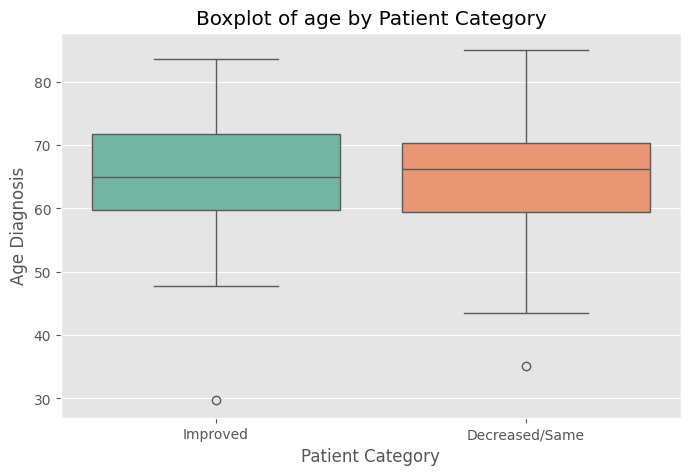

In [36]:
# Encode Trend Category as binary
merged_df_removedNA_age["Trend Category_binary"] = merged_df_removedNA_age["Trend Category"].map({"Improved": 1, "Decreased/Same": 0})

## ==== Boxplot ====
plt.figure(figsize=(8, 5))
sns.boxplot(x="Trend Category", y="age_diagnosis", data=merged_df_removedNA_age, palette="Set2")
plt.xlabel("Patient Category")
plt.ylabel("Age Diagnosis")
plt.title("Boxplot of age by Patient Category")
plt.show()

# sensitivity analysis 2) age (age_diagnosis)

In [37]:
merged_df_removedNA_age

,id,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,age_diagnosis,Trend Category_binary
1,32,117.5,159.000000,41.500000,True,Improved,29.722718,1
12,76,95.0,97.000000,2.000000,False,Decreased/Same,57.597350,0
26,125,119.5,129.000000,9.500000,True,Improved,64.110830,1
32,160,119.0,152.000000,33.000000,True,Improved,50.804602,1
41,198,133.0,139.000000,6.000000,True,Improved,66.229970,1
...,...,...,...,...,...,...,...,...
1284,1560,154.0,151.833333,-2.166667,False,Decreased/Same,66.599588,0
1292,1566,150.0,107.000000,-43.000000,False,Decreased/Same,69.876863,0
1297,1571,153.0,104.000000,-49.000000,False,Decreased/Same,79.245980,0
1309,1572,141.0,115.000000,-26.000000,False,Decreased/Same,60.529648,0


In [38]:
def analyze_age_diagnosis_threshold_relationship(data, threshold):
    """
    Analyze how age at diagnosis relates to improvement at different thresholds
    
    Parameters:
    data: DataFrame containing Change and age_diagnosis columns
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    
    # Check for missing age values
    df = df.dropna(subset=["age_diagnosis"])
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count if total_count > 0 else 0
    
    # Mann-Whitney U test to compare age between improved and not improved groups
    improved_age = df[df["Improved"]]["age_diagnosis"]
    decreased_same_age = df[~df["Improved"]]["age_diagnosis"]
    
    if len(improved_age) > 0 and len(decreased_same_age) > 0:
        stat, p_value = stats.mannwhitneyu(improved_age, decreased_same_age)
    else:
        stat, p_value = None, None
    
    # Mean age in each group
    mean_age_improved = improved_age.mean() if len(improved_age) > 0 else None
    mean_age_not_improved = decreased_same_age.mean() if len(decreased_same_age) > 0 else None
    
    # Logistic regression
    X = sm.add_constant(df["age_diagnosis"])
    y = df["Improved"].astype(int)
    
    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        age_coef = result.params["age_diagnosis"]
        age_p = result.pvalues["age_diagnosis"]
        odds_ratio = np.exp(age_coef)
        
        # Confidence intervals
        age_conf_int = result.conf_int().loc["age_diagnosis"]
        lower_ci = np.exp(age_conf_int[0])
        upper_ci = np.exp(age_conf_int[1])
    except:
        age_coef = None
        age_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "mean_age_improved": mean_age_improved,
        "mean_age_not_improved": mean_age_not_improved,
        "mann_whitney_stat": stat,
        "mann_whitney_p": p_value,
        "logistic_coef": age_coef,
        "logistic_p": age_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Make sure the dataset is clean for analysis
clean_df = merged_df_removedNA_age.dropna(subset=["Change", "age_diagnosis"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_age_diagnosis_threshold_relationship(clean_df, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis of Age at Diagnosis and Improvement at Different Thresholds:")
print(sensitivity_df[["threshold", "improvement_rate", "mean_age_improved", 
                     "mean_age_not_improved", "mann_whitney_p", "odds_ratio"]].round(4))

Sensitivity Analysis of Age at Diagnosis and Improvement at Different Thresholds:
    threshold  improvement_rate  mean_age_improved  mean_age_not_improved  \
0           0            0.4815            64.6338                64.5995   
1           1            0.4722            64.5860                64.6429   
2           2            0.4722            64.5860                64.6429   
3           3            0.3981            64.7711                64.5134   
4           4            0.3889            65.0547                64.3368   
5           5            0.3889            65.0547                64.3368   
6           6            0.3796            64.9610                64.4049   
7           7            0.3611            64.9944                64.4022   
8           8            0.3426            65.2172                64.3027   
9           9            0.3333            64.8223                64.5129   
10         10            0.3241            64.8426                64.50

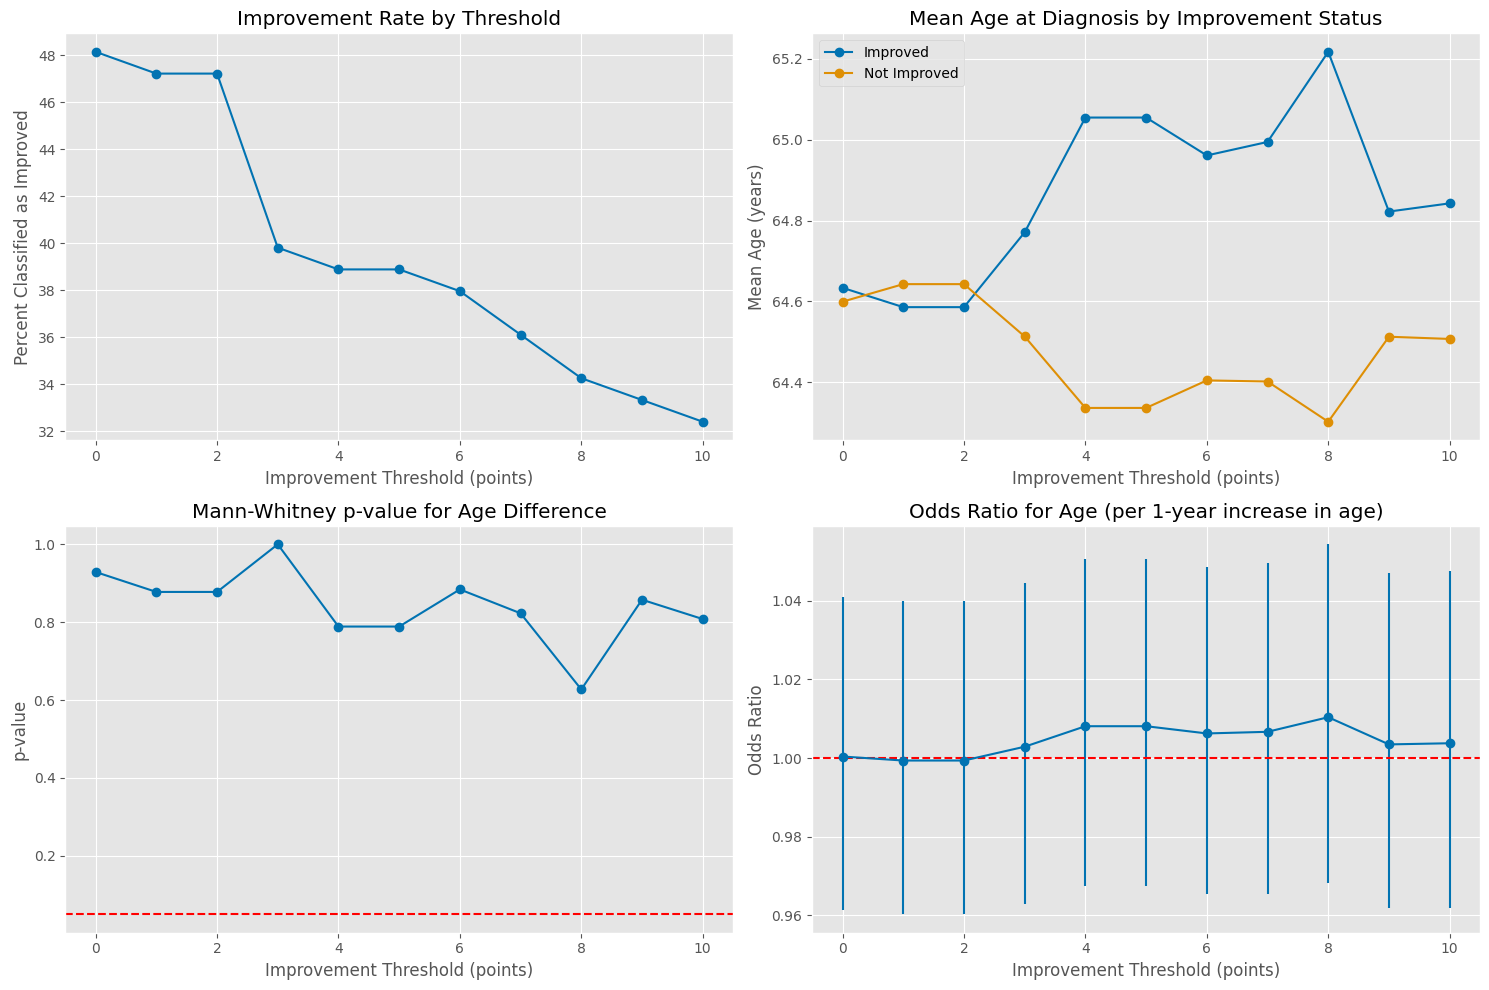

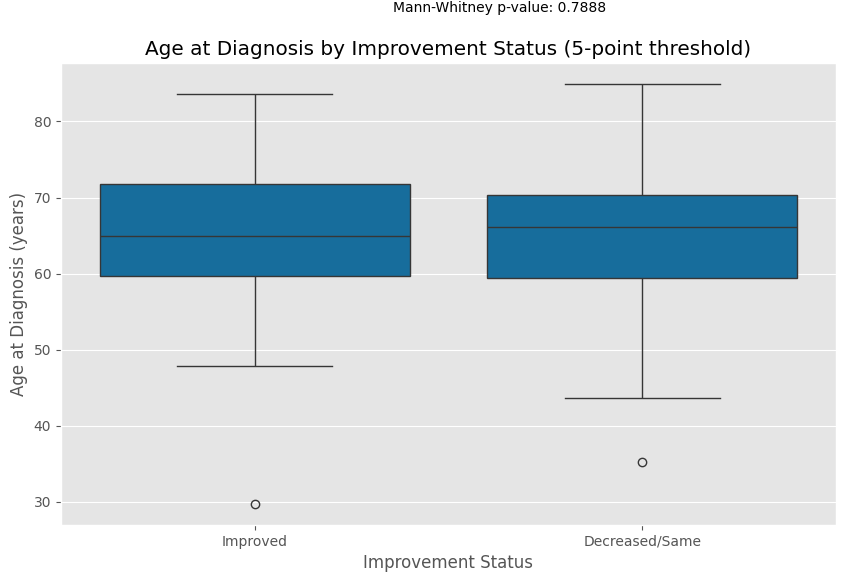

Optimization terminated successfully.
         Current function value: 0.667563
         Iterations 4

Logistic Regression Results at 5-point threshold:
                           Logit Regression Results                           
Dep. Variable:               Improved   No. Observations:                  108
Model:                          Logit   Df Residuals:                      106
Method:                           MLE   Df Model:                            1
Date:                Mon, 05 May 2025   Pseudo R-squ.:                0.001025
Time:                        00:30:42   Log-Likelihood:                -72.097
converged:                       True   LL-Null:                       -72.171
Covariance Type:            nonrobust   LLR p-value:                    0.7005
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.9730      1.375     -0.708     

In [39]:

# Create plots to visualize the results
plt.figure(figsize=(15, 10))

# Plot 1: Improvement rate by threshold
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["improvement_rate"] * 100, 'o-')
plt.title("Improvement Rate by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Percent Classified as Improved")
plt.grid(True)

# Plot 2: Mean age by improvement status across thresholds
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_age_improved"], 'o-', label='Improved')
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_age_not_improved"], 'o-', label='Not Improved')
plt.title("Mean Age at Diagnosis by Improvement Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Mean Age (years)")
plt.legend()
plt.grid(True)

# Plot 3: Mann-Whitney p-values for age differences
plt.subplot(2, 2, 3)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mann_whitney_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Mann-Whitney p-value for Age Difference")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot 4: Odds ratios from logistic regression
plt.subplot(2, 2, 4)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio for Age (per 1-year increase in age)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

plt.tight_layout()
plt.show()

# Additional analysis: Create boxplots of age by improvement status at the 5-point threshold
threshold_5 = clean_df.copy()
threshold_5["Improved"] = threshold_5["Change"] >= 5
threshold_5["Trend Category"] = threshold_5["Improved"].map({True: "Improved", False: "Decreased/Same"})

plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="age_diagnosis", data=threshold_5)
plt.title("Age at Diagnosis by Improvement Status (5-point threshold)")
plt.xlabel("Improvement Status")
plt.ylabel("Age at Diagnosis (years)")

# Perform Mann-Whitney test at the 5-point threshold specifically
improved_age_5 = threshold_5[threshold_5["Improved"]]["age_diagnosis"]
not_improved_age_5 = threshold_5[~threshold_5["Improved"]]["age_diagnosis"]
stat_5, p_value_5 = stats.mannwhitneyu(improved_age_5, not_improved_age_5)

plt.annotate(f"Mann-Whitney p-value: {p_value_5:.4f}", xy=(0.5, 0.95), 
             xycoords='figure fraction', ha='center')
plt.show()

# Logistic regression for the 5-point threshold (standard analysis)
X_5 = sm.add_constant(threshold_5["age_diagnosis"])
y_5 = threshold_5["Improved"].astype(int)
logit_model_5 = sm.Logit(y_5, X_5)
result_5 = logit_model_5.fit()

print("\nLogistic Regression Results at 5-point threshold:")
print(result_5.summary())

# Calculate odds ratio and 95% CI for a 10-year increase in age
age_coef_5 = result_5.params["age_diagnosis"]
odds_ratio_10years = np.exp(age_coef_5 * 10)

age_conf_int_5 = result_5.conf_int().loc["age_diagnosis"]
lower_ci_10years = np.exp(age_conf_int_5[0] * 10)
upper_ci_10years = np.exp(age_conf_int_5[1] * 10)

print(f"\nOdds Ratio for a 10-year increase in age: {odds_ratio_10years:.3f}")
print(f"95% CI for a 10-year increase in age: ({lower_ci_10years:.3f}, {upper_ci_10years:.3f})")

# statistically significantly associated with 3) surgery type (procedure123456)

In [40]:
# Merge score_comparison with procedure123456 data
merged_df_procedure = score_comparison.merge(filtered_df[["id", "procedure123456"]], on="id", how="left")

# Remove rows where procedure123456 is missing
merged_df_removedNA_procedure = merged_df_procedure.dropna(subset=["procedure123456"])
merged_df_expanded_procedure = merged_df_removedNA_procedure.drop_duplicates()
merged_df_removedNA_procedure = merged_df_expanded_procedure.copy()
merged_df_removedNA_procedure

,id,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,procedure123456
0,32,117.5,159.000000,41.500000,True,Improved,1.0
11,76,95.0,97.000000,2.000000,False,Decreased/Same,1.0
27,125,119.5,129.000000,9.500000,True,Improved,1.0
29,160,119.0,152.000000,33.000000,True,Improved,1.0
38,198,133.0,139.000000,6.000000,True,Improved,2.0
...,...,...,...,...,...,...,...
1279,1560,154.0,151.833333,-2.166667,False,Decreased/Same,2.0
1289,1566,150.0,107.000000,-43.000000,False,Decreased/Same,1.0
1300,1571,153.0,104.000000,-49.000000,False,Decreased/Same,1.0
1314,1572,141.0,115.000000,-26.000000,False,Decreased/Same,1.0


In [41]:
# Create a contingency table
contingency_table_procedure = pd.crosstab(merged_df_removedNA_procedure["Trend Category"], merged_df_removedNA_procedure["procedure123456"])
print(contingency_table_procedure)

# Perform Chi-Square test
chi2_stat, p_val, dof, expected = stats.chi2_contingency(contingency_table_procedure)

print(f"Chi-Square statistic: {chi2_stat}")
print(f"P-value: {p_val}")


procedure123456  1.0  2.0  3.0  4.0  5.0  8.0
Trend Category                               
Decreased/Same    38   13    1   10    4    1
Improved          31    8    2    2    1    2
Chi-Square statistic: 6.005372408817377
P-value: 0.3056965106900292


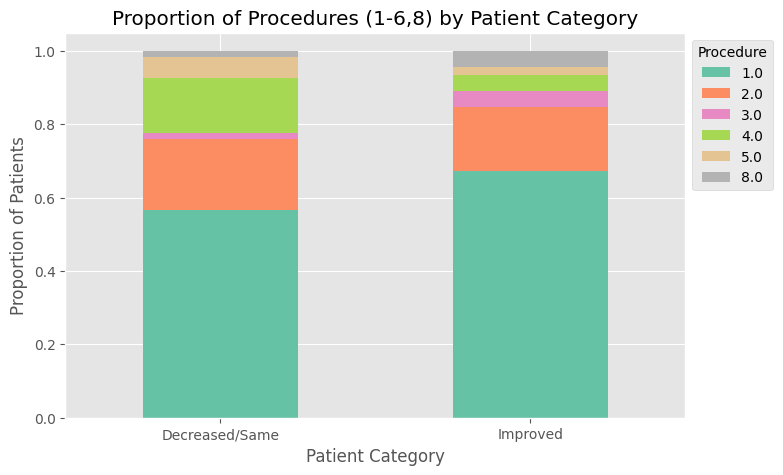

In [42]:
# Create proportion table
proportions = merged_df_removedNA_procedure.groupby("Trend Category")["procedure123456"].value_counts(normalize=True).unstack()

# Plot stacked bar chart
proportions.plot(kind="bar", stacked=True, colormap="Set2", figsize=(8, 5))

# Customize plot appearance
plt.xlabel("Patient Category")
plt.ylabel("Proportion of Patients")
plt.title("Proportion of Procedures (1-6,8) by Patient Category")
plt.legend(title="Procedure", bbox_to_anchor=(1, 1))  # Move legend outside the plot
plt.xticks(rotation=0)  # Keep x-axis labels readable
plt.show()


# sensitivity analysis 3) surgery type (procedure123456)

In [43]:
merged_df_removedNA_procedure

,id,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,procedure123456
0,32,117.5,159.000000,41.500000,True,Improved,1.0
11,76,95.0,97.000000,2.000000,False,Decreased/Same,1.0
27,125,119.5,129.000000,9.500000,True,Improved,1.0
29,160,119.0,152.000000,33.000000,True,Improved,1.0
38,198,133.0,139.000000,6.000000,True,Improved,2.0
...,...,...,...,...,...,...,...
1279,1560,154.0,151.833333,-2.166667,False,Decreased/Same,2.0
1289,1566,150.0,107.000000,-43.000000,False,Decreased/Same,1.0
1300,1571,153.0,104.000000,-49.000000,False,Decreased/Same,1.0
1314,1572,141.0,115.000000,-26.000000,False,Decreased/Same,1.0


In [44]:
def analyze_procedure_threshold_relationship(data, threshold):
    """
    Analyze how procedure type relates to improvement at different thresholds
    
    Parameters:
    data: DataFrame containing Change and procedure123456 columns
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    
    # Check for missing procedure values
    df = df.dropna(subset=["procedure123456"])
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count if total_count > 0 else 0
    
    # Create a contingency table
    contingency_table = pd.crosstab(df["procedure123456"], df["Improved"])
    
    # Chi-square test
    try:
        chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency_table)
    except:
        chi2_stat, chi2_p, dof, expected = None, None, None, None
    
    # Calculate improvement rate for each procedure
    proc_improvement_rates = {}
    for proc_type in df["procedure123456"].unique():
        proc_df = df[df["procedure123456"] == proc_type]
        if len(proc_df) > 0:
            proc_improvement_rates[proc_type] = proc_df["Improved"].mean()
    
    # Logistic regression with procedure as categorical
    try:
        # Create dummy variables for procedure
        proc_dummies = pd.get_dummies(df["procedure123456"], prefix="Proc", drop_first=True)
        
        # Add constant
        X = sm.add_constant(proc_dummies)
        y = df["Improved"].astype(int)
        
        # Fit model
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        
        # Extract p-value for overall model
        lr_p_value = result.llr_pvalue
    except:
        lr_p_value = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2_stat,
        "chi2_p": chi2_p,
        "proc_improvement_rates": proc_improvement_rates,
        "lr_p_value": lr_p_value
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Make sure the dataset is clean for analysis
clean_df = merged_df_removedNA_procedure.dropna(subset=["Change", "procedure123456"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_procedure_threshold_relationship(clean_df, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis of Procedure Type and Improvement at Different Thresholds:")
print(sensitivity_df[["threshold", "improvement_rate", "chi2_p", "lr_p_value"]].round(4))

Sensitivity Analysis of Procedure Type and Improvement at Different Thresholds:
    threshold  improvement_rate  chi2_p lr_p_value
0           0            0.4956  0.2858       None
1           1            0.4867  0.3261       None
2           2            0.4867  0.3261       None
3           3            0.4159  0.3150       None
4           4            0.4071  0.3057       None
5           5            0.4071  0.3057       None
6           6            0.3982  0.3344       None
7           7            0.3805  0.3298       None
8           8            0.3540  0.2424       None
9           9            0.3451  0.1348       None
10         10            0.3274  0.1773       None


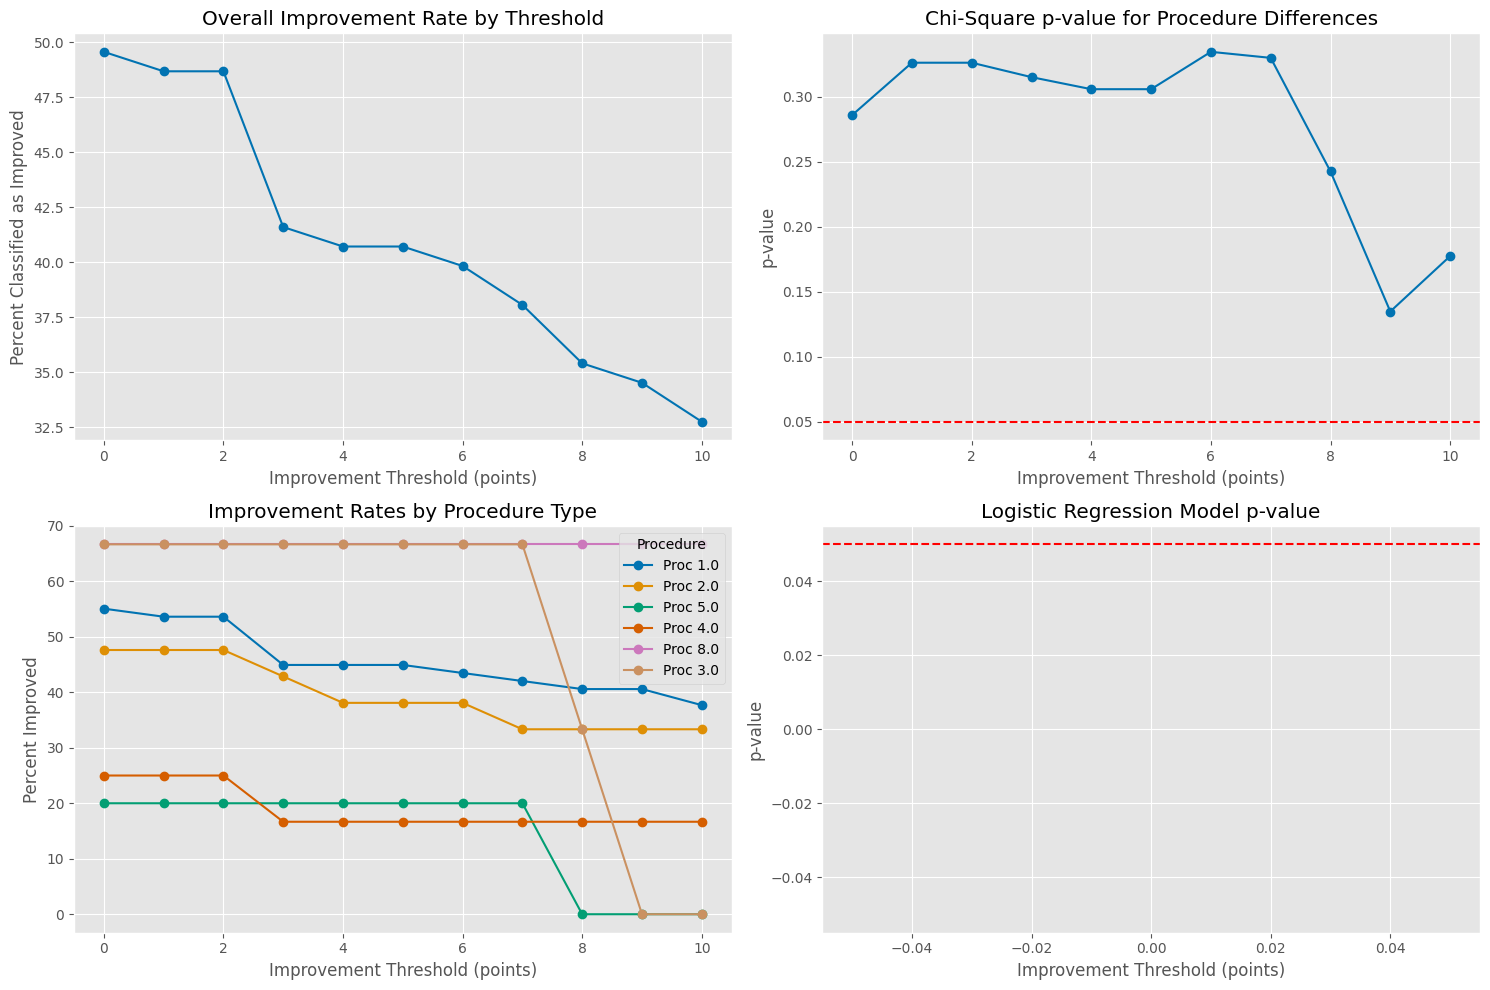


Contingency Table at 5-point threshold:
Trend Category   Decreased/Same  Improved
procedure123456                          
1.0                          38        31
2.0                          13         8
3.0                           1         2
4.0                          10         2
5.0                           4         1
8.0                           1         2

Chi-Square Test at 5-point threshold:
Chi-square statistic: 6.0054
p-value: 0.3057
Degrees of freedom: 5


<Figure size 1200x700 with 0 Axes>

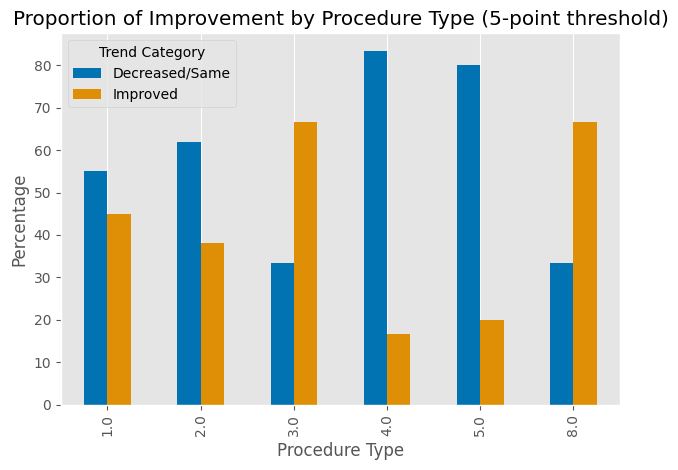


Odds Ratios for Procedure Types (relative to reference procedure):
                   2.5%     97.5%        OR
age_diagnosis  0.967423  1.050458  1.008086


In [45]:


# Extract procedure-specific improvement rates for each threshold
proc_rates_by_threshold = {}
for idx, row in sensitivity_df.iterrows():
    threshold = row["threshold"]
    proc_rates = row["proc_improvement_rates"]
    if proc_rates is not None:
        proc_rates_by_threshold[threshold] = proc_rates

# Convert to DataFrame for easier plotting
proc_rates_df = pd.DataFrame(proc_rates_by_threshold).T
proc_rates_df.index.name = "threshold"
proc_rates_df = proc_rates_df.reset_index()

# Create plots to visualize the results
plt.figure(figsize=(15, 10))

# Plot 1: Improvement rate by threshold
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["improvement_rate"] * 100, 'o-')
plt.title("Overall Improvement Rate by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Percent Classified as Improved")
plt.grid(True)

# Plot 2: Chi-square p-values for procedure differences
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["chi2_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Chi-Square p-value for Procedure Differences")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot 3: Improvement rates by procedure across thresholds
plt.subplot(2, 2, 3)
for col in proc_rates_df.columns:
    if col != "threshold":
        plt.plot(proc_rates_df["threshold"], proc_rates_df[col] * 100, 'o-', label=f"Proc {col}")
plt.title("Improvement Rates by Procedure Type")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Percent Improved")
plt.legend(title="Procedure")
plt.grid(True)

# Plot 4: Logistic regression p-values
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["lr_p_value"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression Model p-value")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Additional analysis: Detailed look at 5-point threshold
threshold_5 = clean_df.copy()
threshold_5["Improved"] = threshold_5["Change"] >= 5
threshold_5["Trend Category"] = threshold_5["Improved"].map({True: "Improved", False: "Decreased/Same"})

# Create contingency table for procedure vs improvement at 5-point threshold
contingency_5 = pd.crosstab(threshold_5["procedure123456"], threshold_5["Trend Category"])
print("\nContingency Table at 5-point threshold:")
print(contingency_5)

# Chi-square test
chi2_stat_5, chi2_p_5, dof_5, expected_5 = stats.chi2_contingency(contingency_5)
print(f"\nChi-Square Test at 5-point threshold:")
print(f"Chi-square statistic: {chi2_stat_5:.4f}")
print(f"p-value: {chi2_p_5:.4f}")
print(f"Degrees of freedom: {dof_5}")

# Visualize with a bar plot
plt.figure(figsize=(12, 7))
proportions = pd.crosstab(
    threshold_5["procedure123456"], 
    threshold_5["Trend Category"], 
    normalize="index"
) * 100

proportions.plot(kind="bar", stacked=False)
plt.title("Proportion of Improvement by Procedure Type (5-point threshold)")
plt.xlabel("Procedure Type")
plt.ylabel("Percentage")
plt.legend(title="Trend Category")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Calculate odds ratios and confidence intervals
print("\nOdds Ratios for Procedure Types (relative to reference procedure):")
params = result_5.params
conf = result_5.conf_int()
conf['OR'] = params
conf.columns = ['2.5%', '97.5%', 'OR']
conf['OR'] = np.exp(conf['OR'])
conf['2.5%'] = np.exp(conf['2.5%'])
conf['97.5%'] = np.exp(conf['97.5%'])
print(conf.iloc[1:])  # Skip the constant

# statistically significantly associated with 4) pathological stage (path_esoph_stage)

In [46]:
# Merge score_comparison with path_esoph_stage data
merged_df_stage = score_comparison.merge(filtered_df[["id", "path_esoph_stage"]], on="id", how="left")

In [47]:
# Define mapping for path_esoph_stage as requested
stage_mapping = {
    '1a': 1, 
    '1b': 1,
    '2a': 2, 
    '2b': 2,
    '3a': 3, 
    '3b': 3,
    '4a': 4, 
    '4b': 4,
    '5': float('nan'),  # Map 5 to NaN as requested
    '0': 0,
    'nan': float('nan')  # Handle existing NaN values
}

# Apply mapping to convert stages
merged_df_stage["path_esoph_stage_numeric"] = merged_df_stage["path_esoph_stage"].map(stage_mapping)

# Remove rows where path_esoph_stage is missing after mapping
merged_df_removedNA_stage = merged_df_stage.dropna(subset=["path_esoph_stage_numeric"])
merged_df_expanded_stage = merged_df_removedNA_stage.drop_duplicates()
merged_df_removedNA_stage = merged_df_expanded_stage.copy()
merged_df_removedNA_stage

,id,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,path_esoph_stage,path_esoph_stage_numeric
21,125,119.500000,129.000000,9.500000,True,Improved,3b,3.0
36,160,119.000000,152.000000,33.000000,True,Improved,3b,3.0
53,230,133.800000,53.000000,-80.800000,False,Decreased/Same,2b,2.0
82,364,140.181818,140.000000,-0.181818,False,Decreased/Same,3b,3.0
93,442,143.000000,113.000000,-30.000000,False,Decreased/Same,3a,3.0
187,508,101.333333,104.000000,2.666667,False,Decreased/Same,3b,3.0
257,536,117.611111,116.812500,-0.798611,False,Decreased/Same,0,0.0
284,539,144.916667,150.333333,5.416667,True,Improved,4a,4.0
295,543,128.000000,148.000000,20.000000,True,Improved,3b,3.0
311,545,103.000000,102.000000,-1.000000,False,Decreased/Same,0,0.0


In [48]:
# Create a contingency table
contingency_table_stage = pd.crosstab(merged_df_removedNA_stage["Trend Category"], 
                                     merged_df_removedNA_stage["path_esoph_stage_numeric"])
print(contingency_table_stage)

# Chi-square test
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table_stage)
print(f"Chi-Square Test p-value: {p_value}")

path_esoph_stage_numeric  0.0  1.0  2.0  3.0  4.0
Trend Category                                   
Decreased/Same              6    2   10   10    2
Improved                    2    3    6    8    3
Chi-Square Test p-value: 0.6537138742105042


In [49]:
# Fisher's exact test - may need to collapse categories if too many levels
try:
    odds_ratio, p_value = stats.fisher_exact(contingency_table_stage)
    print(f"Fisher's Exact Test p-value: {p_value}")
except ValueError:
    print("Fisher's exact test couldn't be performed - too many categories or imbalanced data")
    # Alternative: collapse categories or use another test

Fisher's exact test couldn't be performed - too many categories or imbalanced data


In [50]:
# For logistic regression, we need to consider how to handle multiple stage levels
# Option 1: Convert to ordinal variable (assuming stage progression is meaningful)
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_stage["Trend Category_binary"] = merged_df_removedNA_stage["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Logistic Regression Model - using stage as an ordinal predictor
X = sm.add_constant(merged_df_removedNA_stage["path_esoph_stage_numeric"])  # Predictor
y = merged_df_removedNA_stage["Trend Category_binary"]  # Outcome (0/1)
logit_model = sm.Logit(y, X)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.672473
         Iterations 4
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                   52
Model:                             Logit   Df Residuals:                       50
Method:                              MLE   Df Model:                            1
Date:                   Mon, 05 May 2025   Pseudo R-squ.:                 0.01291
Time:                           00:30:45   Log-Likelihood:                -34.969
converged:                          True   LL-Null:                       -35.426
Covariance Type:               nonrobust   LLR p-value:                    0.3389
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -0.8050      0.603     -1.33

# sensitivity analysis 4) pathological stage (path_esoph_stage)

In [51]:
merged_df_removedNA_stage

,id,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,path_esoph_stage,path_esoph_stage_numeric,Trend Category_binary
21,125,119.500000,129.000000,9.500000,True,Improved,3b,3.0,1
36,160,119.000000,152.000000,33.000000,True,Improved,3b,3.0,1
53,230,133.800000,53.000000,-80.800000,False,Decreased/Same,2b,2.0,0
82,364,140.181818,140.000000,-0.181818,False,Decreased/Same,3b,3.0,0
93,442,143.000000,113.000000,-30.000000,False,Decreased/Same,3a,3.0,0
187,508,101.333333,104.000000,2.666667,False,Decreased/Same,3b,3.0,0
257,536,117.611111,116.812500,-0.798611,False,Decreased/Same,0,0.0,0
284,539,144.916667,150.333333,5.416667,True,Improved,4a,4.0,1
295,543,128.000000,148.000000,20.000000,True,Improved,3b,3.0,1
311,545,103.000000,102.000000,-1.000000,False,Decreased/Same,0,0.0,0


In [52]:
def analyze_stage_threshold_relationship(data, threshold):
    """
    Analyze how esophageal stage relates to improvement at different thresholds
    
    Parameters:
    data: DataFrame containing Change and path_esoph_stage_numeric columns
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    
    # Check for missing stage values
    df = df.dropna(subset=["path_esoph_stage_numeric"])
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count if total_count > 0 else 0
    
    # Create a contingency table
    contingency_table = pd.crosstab(df["path_esoph_stage_numeric"], df["Improved"])
    
    # Chi-square test
    try:
        chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency_table)
    except:
        chi2_stat, chi2_p, dof, expected = None, None, None, None
    
    # Calculate improvement rate for each stage
    stage_improvement_rates = {}
    for stage in df["path_esoph_stage_numeric"].unique():
        stage_df = df[df["path_esoph_stage_numeric"] == stage]
        if len(stage_df) > 0:
            stage_improvement_rates[stage] = stage_df["Improved"].mean()
    
    # Logistic regression with stage as categorical
    try:
        # Create dummy variables for stage
        stage_dummies = pd.get_dummies(df["path_esoph_stage_numeric"], prefix="Stage", drop_first=True)
        
        # Add constant
        X = sm.add_constant(stage_dummies)
        y = df["Improved"].astype(int)
        
        # Fit model
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        
        # Extract p-value for overall model
        lr_p_value = result.llr_pvalue
    except:
        lr_p_value = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2_stat,
        "chi2_p": chi2_p,
        "stage_improvement_rates": stage_improvement_rates,
        "lr_p_value": lr_p_value
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Make sure the dataset is clean for analysis
clean_df = merged_df_removedNA_stage.dropna(subset=["Change", "path_esoph_stage_numeric"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_stage_threshold_relationship(clean_df, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis of Esophageal Stage and Improvement at Different Thresholds:")
print(sensitivity_df[["threshold", "improvement_rate", "chi2_p", "lr_p_value"]].round(4))

Sensitivity Analysis of Esophageal Stage and Improvement at Different Thresholds:
    threshold  improvement_rate  chi2_p lr_p_value
0           0            0.5192  0.7034       None
1           1            0.5000  0.6005       None
2           2            0.5000  0.6005       None
3           3            0.4423  0.6973       None
4           4            0.4231  0.6537       None
5           5            0.4231  0.6537       None
6           6            0.4038  0.7790       None
7           7            0.3846  0.6951       None
8           8            0.3462  0.3592       None
9           9            0.3269  0.1900       None
10         10            0.3077  0.2492       None


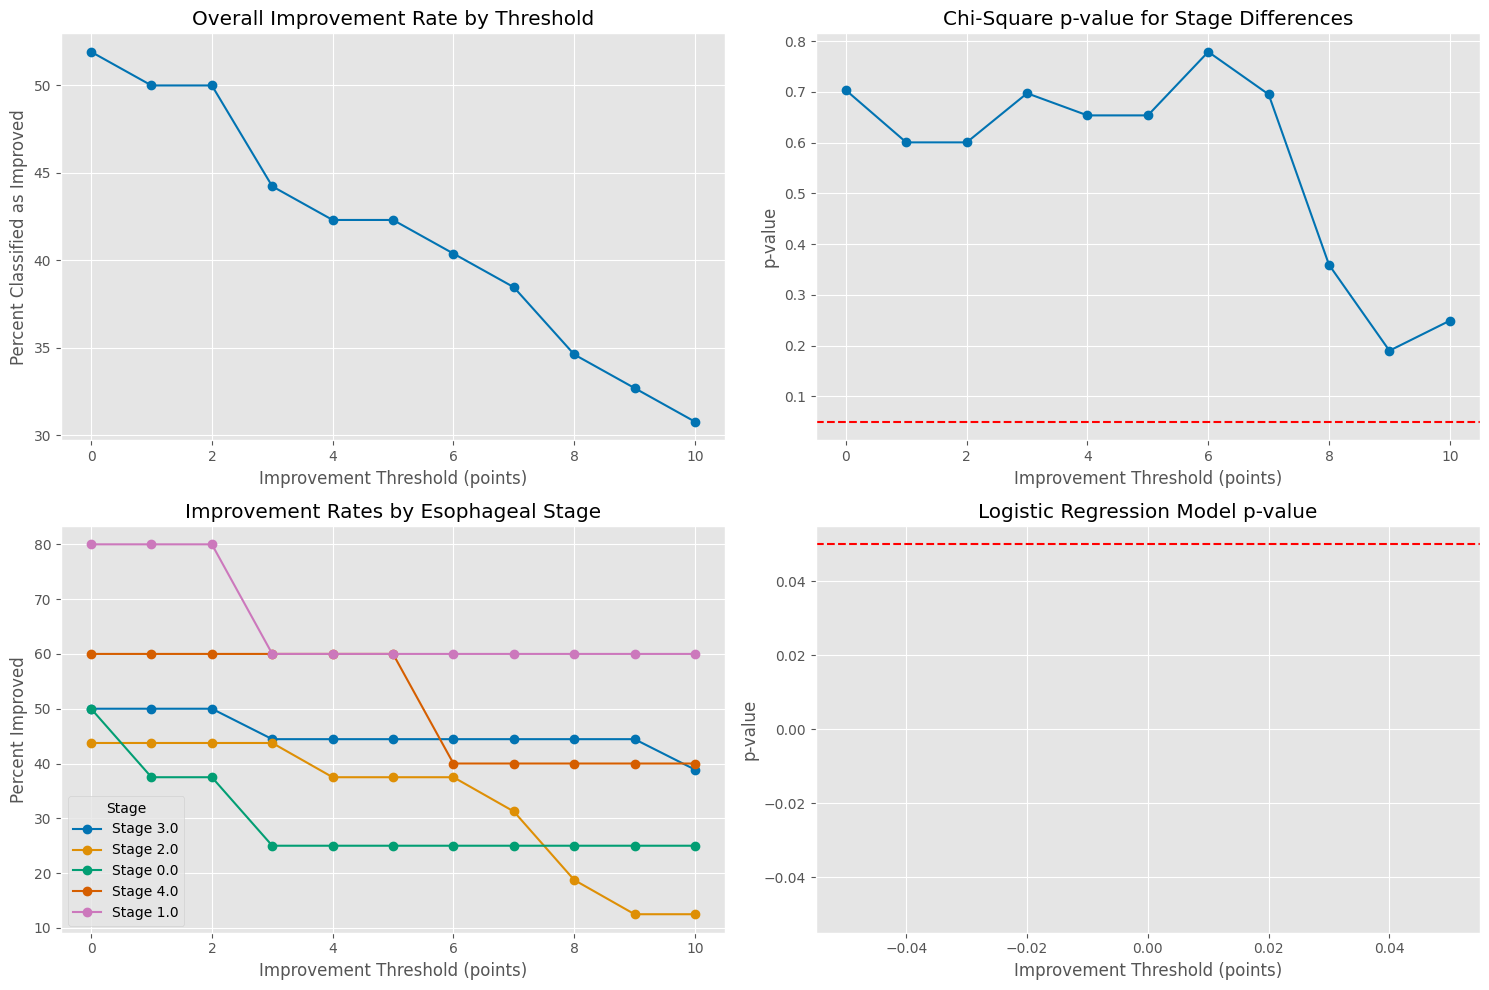


Contingency Table at 5-point threshold:
Trend Category            Decreased/Same  Improved
path_esoph_stage_numeric                          
0.0                                    6         2
1.0                                    2         3
2.0                                   10         6
3.0                                   10         8
4.0                                    2         3

Chi-Square Test at 5-point threshold:
Chi-square statistic: 2.4494
p-value: 0.6537
Degrees of freedom: 4


<Figure size 1200x700 with 0 Axes>

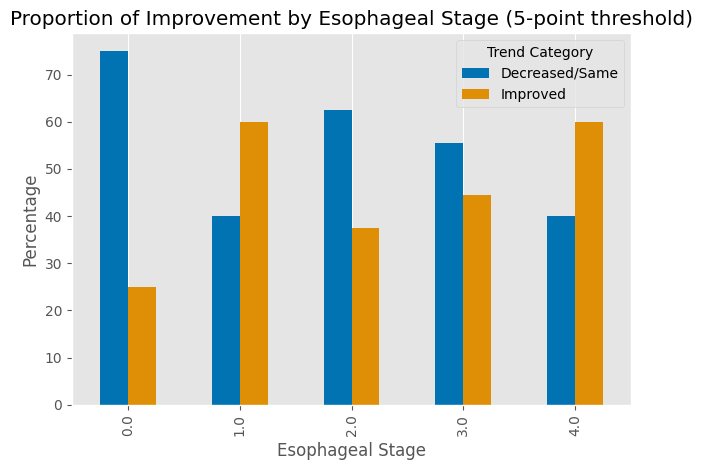

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [53]:

# Extract stage-specific improvement rates for each threshold
stage_rates_by_threshold = {}
for idx, row in sensitivity_df.iterrows():
    threshold = row["threshold"]
    stage_rates = row["stage_improvement_rates"]
    if stage_rates is not None:
        stage_rates_by_threshold[threshold] = stage_rates

# Convert to DataFrame for easier plotting
stage_rates_df = pd.DataFrame(stage_rates_by_threshold).T
stage_rates_df.index.name = "threshold"
stage_rates_df = stage_rates_df.reset_index()

# Create plots to visualize the results
plt.figure(figsize=(15, 10))

# Plot 1: Improvement rate by threshold
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["improvement_rate"] * 100, 'o-')
plt.title("Overall Improvement Rate by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Percent Classified as Improved")
plt.grid(True)

# Plot 2: Chi-square p-values for stage differences
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["chi2_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Chi-Square p-value for Stage Differences")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot 3: Improvement rates by stage across thresholds
plt.subplot(2, 2, 3)
for col in stage_rates_df.columns:
    if col != "threshold":
        plt.plot(stage_rates_df["threshold"], stage_rates_df[col] * 100, 'o-', label=f"Stage {col}")
plt.title("Improvement Rates by Esophageal Stage")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Percent Improved")
plt.legend(title="Stage")
plt.grid(True)

# Plot 4: Logistic regression p-values
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["lr_p_value"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression Model p-value")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Additional analysis: Detailed look at 5-point threshold
threshold_5 = clean_df.copy()
threshold_5["Improved"] = threshold_5["Change"] >= 5
threshold_5["Trend Category"] = threshold_5["Improved"].map({True: "Improved", False: "Decreased/Same"})

# Create contingency table for stage vs improvement at 5-point threshold
contingency_5 = pd.crosstab(threshold_5["path_esoph_stage_numeric"], threshold_5["Trend Category"])
print("\nContingency Table at 5-point threshold:")
print(contingency_5)

# Chi-square test
chi2_stat_5, chi2_p_5, dof_5, expected_5 = stats.chi2_contingency(contingency_5)
print(f"\nChi-Square Test at 5-point threshold:")
print(f"Chi-square statistic: {chi2_stat_5:.4f}")
print(f"p-value: {chi2_p_5:.4f}")
print(f"Degrees of freedom: {dof_5}")

# Visualize with a bar plot
plt.figure(figsize=(12, 7))
proportions = pd.crosstab(
    threshold_5["path_esoph_stage_numeric"], 
    threshold_5["Trend Category"], 
    normalize="index"
) * 100

proportions.plot(kind="bar", stacked=False)
plt.title("Proportion of Improvement by Esophageal Stage (5-point threshold)")
plt.xlabel("Esophageal Stage")
plt.ylabel("Percentage")
plt.legend(title="Trend Category")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Logistic regression for stage at 5-point threshold
stage_dummies_5 = pd.get_dummies(threshold_5["path_esoph_stage_numeric"], prefix="Stage", drop_first=True)
X_5 = sm.add_constant(stage_dummies_5)
y_5 = threshold_5["Improved"].astype(int)

logit_model_5 = sm.Logit(y_5, X_5)
result_5 = logit_model_5.fit()

print("\nLogistic Regression Results at 5-point threshold:")
print(result_5.summary())

# Calculate odds ratios and confidence intervals
print("\nOdds Ratios for Esophageal Stages (relative to reference stage):")
params = result_5.params
conf = result_5.conf_int()
conf['OR'] = params
conf.columns = ['2.5%', '97.5%', 'OR']
conf['OR'] = np.exp(conf['OR'])
conf['2.5%'] = np.exp(conf['2.5%'])
conf['97.5%'] = np.exp(conf['97.5%'])
print(conf.iloc[1:])  # Skip the constant

# Create a map from numeric stages to text descriptions for better interpretation
stage_descriptions = {
    0: "Stage 0",
    1: "Stage 1",
    2: "Stage 2",
    3: "Stage 3",
    4: "Stage 4"
}

# Create a version of the bar chart with better labels
plt.figure(figsize=(12, 7))
proportions.rename(index=stage_descriptions, inplace=True)
proportions.plot(kind="bar", stacked=False)
plt.title("Proportion of Improvement by Esophageal Stage (5-point threshold)")
plt.xlabel("Esophageal Stage")
plt.ylabel("Percentage")
plt.legend(title="Trend Category")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# statistically significantly associated with 5) level of tumor (level_tumor)

In [55]:
# Merge score_comparison with level_tumor data
merged_df_level = score_comparison.merge(filtered_df[["id", "level_tumor"]], on="id", how="left")

# Remove rows where level_tumor is missing
merged_df_removedNA_level = merged_df_level.dropna(subset=["level_tumor"])
merged_df_expanded_level = merged_df_removedNA_level.drop_duplicates()
merged_df_removedNA_level = merged_df_expanded_level.copy()
merged_df_removedNA_level

,id,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,level_tumor
1,32,117.5,159.000000,41.500000,True,Improved,4.0
12,76,95.0,97.000000,2.000000,False,Decreased/Same,4.0
26,125,119.5,129.000000,9.500000,True,Improved,4.0
32,160,119.0,152.000000,33.000000,True,Improved,6.0
41,198,133.0,139.000000,6.000000,True,Improved,4.0
...,...,...,...,...,...,...,...
1284,1560,154.0,151.833333,-2.166667,False,Decreased/Same,4.0
1292,1566,150.0,107.000000,-43.000000,False,Decreased/Same,6.0
1297,1571,153.0,104.000000,-49.000000,False,Decreased/Same,6.0
1309,1572,141.0,115.000000,-26.000000,False,Decreased/Same,6.0


In [56]:
# Create a contingency table
contingency_table_level = pd.crosstab(merged_df_removedNA_level["Trend Category"], 
                                     merged_df_removedNA_level["level_tumor"])
print("Contingency Table:")
print(contingency_table_level)

# Chi-square test
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table_level)
print(f"Chi-Square Test p-value: {p_value}")

Contingency Table:
level_tumor     1.0  2.0  3.0  4.0  5.0  6.0  7.0
Trend Category                                   
Decreased/Same    1    0    8   29    4   15   12
Improved          0    2    1   23    6   13    5
Chi-Square Test p-value: 0.1343354131537942


In [57]:
# Fisher's exact test - may not work if the table is too large
try:
    odds_ratio, p_value = stats.fisher_exact(contingency_table_level)
    print(f"Fisher's Exact Test p-value: {p_value}")
except ValueError:
    print("Fisher's exact test couldn't be performed - too many categories or imbalanced data")
    

Fisher's exact test couldn't be performed - too many categories or imbalanced data


# sensitivity analysis 5) level of tumor (level_tumor)

In [58]:
merged_df_removedNA_level

,id,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,level_tumor
1,32,117.5,159.000000,41.500000,True,Improved,4.0
12,76,95.0,97.000000,2.000000,False,Decreased/Same,4.0
26,125,119.5,129.000000,9.500000,True,Improved,4.0
32,160,119.0,152.000000,33.000000,True,Improved,6.0
41,198,133.0,139.000000,6.000000,True,Improved,4.0
...,...,...,...,...,...,...,...
1284,1560,154.0,151.833333,-2.166667,False,Decreased/Same,4.0
1292,1566,150.0,107.000000,-43.000000,False,Decreased/Same,6.0
1297,1571,153.0,104.000000,-49.000000,False,Decreased/Same,6.0
1309,1572,141.0,115.000000,-26.000000,False,Decreased/Same,6.0


In [72]:
def analyze_tumor_level_threshold_relationship(data, threshold):
    """
    Analyze how tumor level relates to improvement at different thresholds
    
    Parameters:
    data: DataFrame containing Change and level_tumor columns
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    
    # Check for missing tumor level values
    df = df.dropna(subset=["level_tumor"])
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count if total_count > 0 else 0
    
    # Create a contingency table
    contingency_table = pd.crosstab(df["level_tumor"], df["Improved"])
    
    # Chi-square test
    try:
        chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency_table)
    except:
        chi2_stat, chi2_p, dof, expected = None, None, None, None
    
    # Calculate improvement rate for each tumor level
    level_improvement_rates = {}
    for level in df["level_tumor"].unique():
        level_df = df[df["level_tumor"] == level]
        if len(level_df) > 0:
            level_improvement_rates[level] = level_df["Improved"].mean()
    
    # Logistic regression with tumor level as categorical
    try:
        # Create dummy variables for tumor level
        level_dummies = pd.get_dummies(df["level_tumor"], prefix="Level", drop_first=True)
        
        # Add constant
        X = sm.add_constant(level_dummies)
        y = df["Improved"].astype(int)
        
        # Fit model
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        
        # Extract p-value for overall model
        lr_p_value = result.llr_pvalue
    except:
        lr_p_value = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2_stat,
        "chi2_p": chi2_p,
        "level_improvement_rates": level_improvement_rates,
        "lr_p_value": lr_p_value
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Make sure the dataset is clean for analysis
clean_df = merged_df_removedNA_level.dropna(subset=["Change", "level_tumor"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_tumor_level_threshold_relationship(clean_df, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis of Tumor Level and Improvement at Different Thresholds:")
print(sensitivity_df[["threshold", "improvement_rate", "chi2_p", "lr_p_value"]].round(4))

Sensitivity Analysis of Tumor Level and Improvement at Different Thresholds:
    threshold  improvement_rate  chi2_p lr_p_value
0           0            0.5042  0.3363       None
1           1            0.4958  0.3589       None
2           2            0.4958  0.3589       None
3           3            0.4286  0.1267       None
4           4            0.4202  0.1343       None
5           5            0.4202  0.1343       None
6           6            0.4118  0.1380       None
7           7            0.3950  0.1531       None
8           8            0.3697  0.0610       None
9           9            0.3613  0.0290       None
10         10            0.3445  0.0281       None


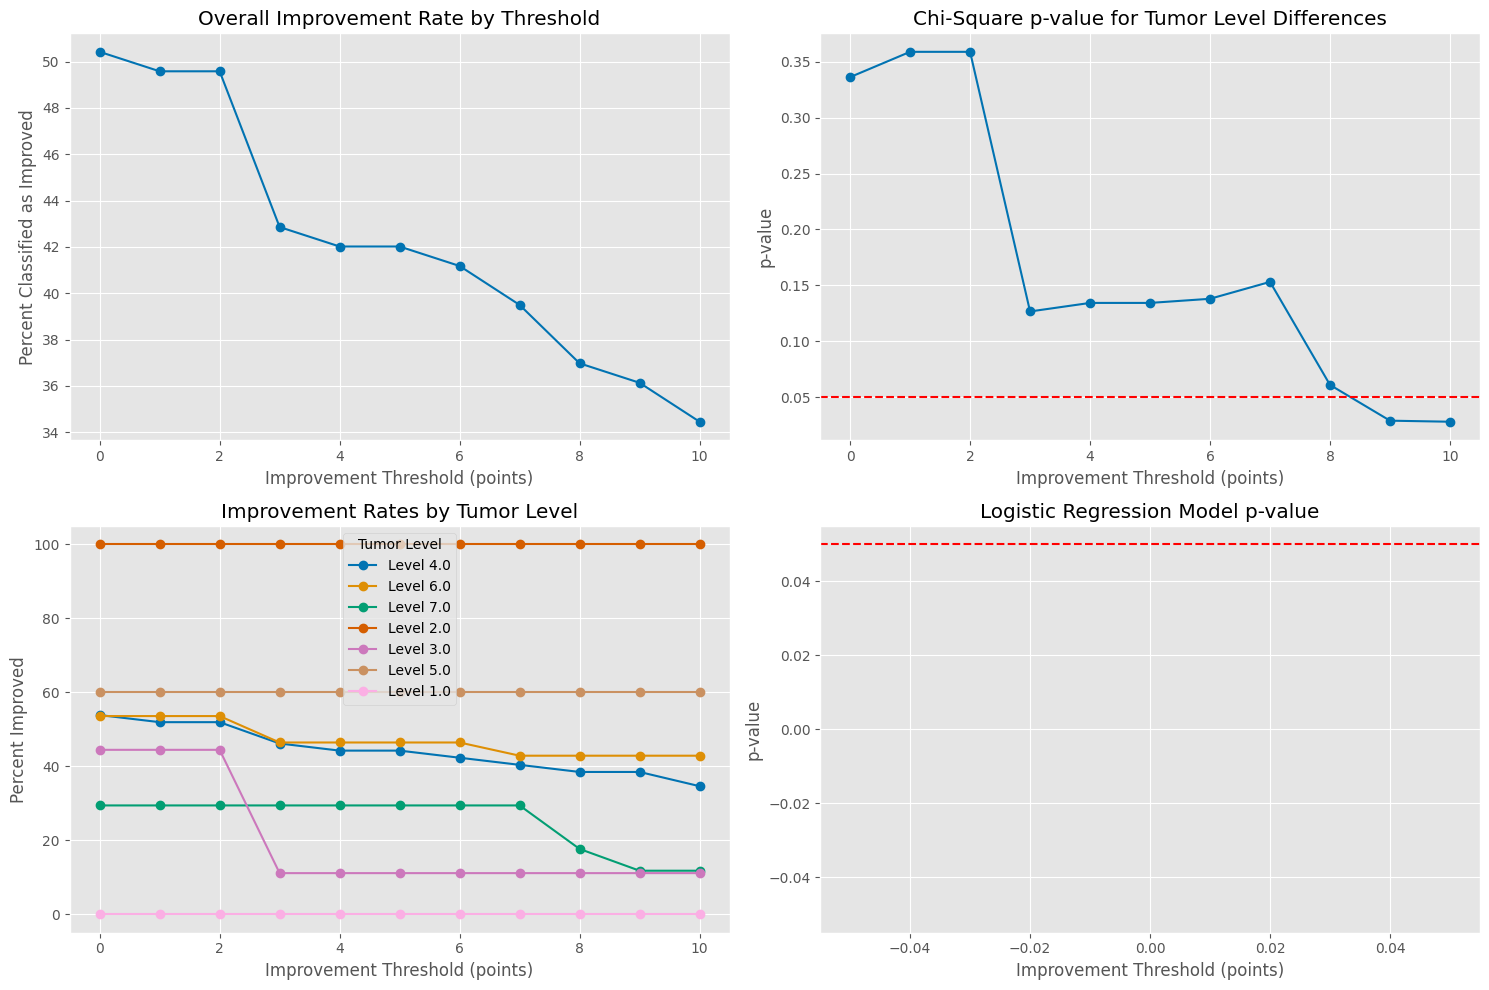


Contingency Table at 5-point threshold:
Trend Category  Decreased/Same  Improved
level_tumor                             
1.0                          1         0
2.0                          0         2
3.0                          8         1
4.0                         29        23
5.0                          4         6
6.0                         15        13
7.0                         12         5

Chi-Square Test at 5-point threshold:
Chi-square statistic: 9.7776
p-value: 0.1343
Degrees of freedom: 6


<Figure size 1200x700 with 0 Axes>

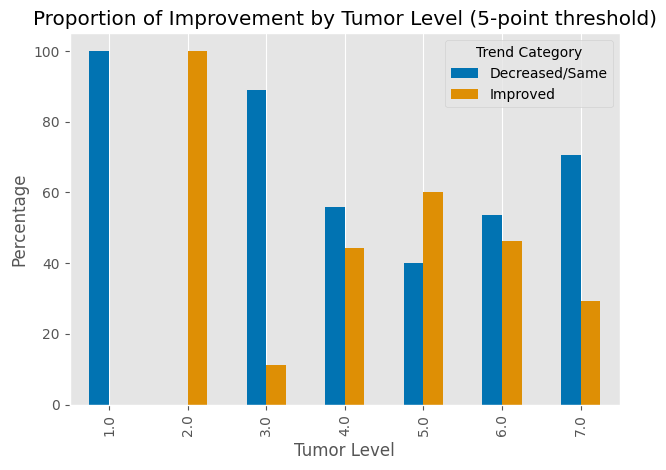

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [71]:

# Extract tumor level-specific improvement rates for each threshold
level_rates_by_threshold = {}
for idx, row in sensitivity_df.iterrows():
    threshold = row["threshold"]
    level_rates = row["level_improvement_rates"]
    if level_rates is not None:
        level_rates_by_threshold[threshold] = level_rates

# Convert to DataFrame for easier plotting
level_rates_df = pd.DataFrame(level_rates_by_threshold).T
level_rates_df.index.name = "threshold"
level_rates_df = level_rates_df.reset_index()

# Create plots to visualize the results
plt.figure(figsize=(15, 10))

# Plot 1: Improvement rate by threshold
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["improvement_rate"] * 100, 'o-')
plt.title("Overall Improvement Rate by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Percent Classified as Improved")
plt.grid(True)

# Plot 2: Chi-square p-values for tumor level differences
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["chi2_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Chi-Square p-value for Tumor Level Differences")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot 3: Improvement rates by tumor level across thresholds
plt.subplot(2, 2, 3)
for col in level_rates_df.columns:
    if col != "threshold":
        plt.plot(level_rates_df["threshold"], level_rates_df[col] * 100, 'o-', label=f"Level {col}")
plt.title("Improvement Rates by Tumor Level")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Percent Improved")
plt.legend(title="Tumor Level")
plt.grid(True)

# Plot 4: Logistic regression p-values
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["lr_p_value"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression Model p-value")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Additional analysis: Detailed look at 5-point threshold
threshold_5 = clean_df.copy()
threshold_5["Improved"] = threshold_5["Change"] >= 5
threshold_5["Trend Category"] = threshold_5["Improved"].map({True: "Improved", False: "Decreased/Same"})

# Create contingency table for tumor level vs improvement at 5-point threshold
contingency_5 = pd.crosstab(threshold_5["level_tumor"], threshold_5["Trend Category"])
print("\nContingency Table at 5-point threshold:")
print(contingency_5)

# Chi-square test
chi2_stat_5, chi2_p_5, dof_5, expected_5 = stats.chi2_contingency(contingency_5)
print(f"\nChi-Square Test at 5-point threshold:")
print(f"Chi-square statistic: {chi2_stat_5:.4f}")
print(f"p-value: {chi2_p_5:.4f}")
print(f"Degrees of freedom: {dof_5}")

# Visualize with a bar plot
plt.figure(figsize=(12, 7))
proportions = pd.crosstab(
    threshold_5["level_tumor"], 
    threshold_5["Trend Category"], 
    normalize="index"
) * 100

proportions.plot(kind="bar", stacked=False)
plt.title("Proportion of Improvement by Tumor Level (5-point threshold)")
plt.xlabel("Tumor Level")
plt.ylabel("Percentage")
plt.legend(title="Trend Category")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Logistic regression for tumor level at 5-point threshold
level_dummies_5 = pd.get_dummies(threshold_5["level_tumor"], prefix="Level", drop_first=True)
X_5 = sm.add_constant(level_dummies_5)
y_5 = threshold_5["Improved"].astype(int)

logit_model_5 = sm.Logit(y_5, X_5)
result_5 = logit_model_5.fit()

print("\nLogistic Regression Results at 5-point threshold:")
print(result_5.summary())

# Calculate odds ratios and confidence intervals
print("\nOdds Ratios for Tumor Levels (relative to reference level):")
params = result_5.params
conf = result_5.conf_int()
conf['OR'] = params
conf.columns = ['2.5%', '97.5%', 'OR']
conf['OR'] = np.exp(conf['OR'])
conf['2.5%'] = np.exp(conf['2.5%'])
conf['97.5%'] = np.exp(conf['97.5%'])
print(conf.iloc[1:])  # Skip the constant

# Count sample sizes for each tumor level
level_counts = threshold_5["level_tumor"].value_counts().sort_index()
print("\nSample size for each tumor level:")
print(level_counts)

# statistically significantly associated with 6) histology (path_histology)

### single column

In [64]:
# Check for patients with multiple histologies

# Define histology columns
histology_columns = [
    "path_histology___noca",
    "path_histology___hgd",
    "path_histology___cis",
    "path_histology___adeno",
    "path_histology___scc",
    "path_histology___nec",
    "path_histology___other"
]

# Count how many histology types each patient has
filtered_df["histology_count"] = filtered_df[histology_columns].sum(axis=1)

# Summarize the results
print("\n### Multiple Histology Analysis ###\n")
print(f"Total patients: {len(filtered_df)}")

# Count patients by number of histologies
histology_distribution = filtered_df["histology_count"].value_counts().sort_index()
print("\nDistribution of patients by number of histology types:")
print(histology_distribution)

# Calculate percentage with multiple histologies
multiple_count = (filtered_df["histology_count"] > 1).sum()
multiple_percent = (multiple_count / len(filtered_df)) * 100
print(f"\nPatients with multiple histologies: {multiple_count} ({multiple_percent:.2f}%)")

# Optional: Show sample of patients with multiple histologies
if multiple_count > 0:
    print("\nSample of patients with multiple histologies:")
    multiple_histology_patients = filtered_df[filtered_df["histology_count"] > 1]
    print(multiple_histology_patients[["id"] + histology_columns].head())


### Multiple Histology Analysis ###

Total patients: 1963

Distribution of patients by number of histology types:
histology_count
0.0    1755
1.0     182
2.0      24
3.0       2
Name: count, dtype: int64

Patients with multiple histologies: 26 (1.32%)

Sample of patients with multiple histologies:
       id  path_histology___noca  path_histology___hgd  path_histology___cis  \
1414  198                    0.0                   1.0                   0.0   
2472  307                    0.0                   1.0                   0.0   
3855  481                    0.0                   1.0                   1.0   
4143  508                    0.0                   0.0                   0.0   
4187  512                    0.0                   1.0                   0.0   

      path_histology___adeno  path_histology___scc  path_histology___nec  \
1414                     1.0                   0.0                   0.0   
2472                     1.0                   0.0                 

In [66]:
# List of binary histology columns
histology_columns = [
    "path_histology___noca",
    "path_histology___hgd",
    "path_histology___cis",
    "path_histology___adeno",
    "path_histology___scc",
    "path_histology___nec",
    "path_histology___other"
]

# Merge data (assuming score_comparison and filtered_df are already defined)
merged_df = score_comparison.merge(filtered_df[["id"] + histology_columns], on="id", how="left")
merged_df = merged_df.dropna(subset=histology_columns)
merged_df = merged_df.drop_duplicates()

# Count histology types per patient
merged_df['histology_count'] = merged_df[histology_columns].sum(axis=1)

# Filter to keep only patients with exactly one histology type
single_histology_df = merged_df[merged_df['histology_count'] == 1].copy()
print(f"Patients with exactly one histology type: {len(single_histology_df)}")

# Create a categorical histology variable
histology_mapping = {
    "path_histology___noca": "NOCA",
    "path_histology___hgd": "HGD",
    "path_histology___cis": "CIS",
    "path_histology___adeno": "Adenocarcinoma",
    "path_histology___scc": "SCC",
    "path_histology___nec": "NEC",
    "path_histology___other": "Other"
}

# Initialize the categorical variable
single_histology_df['histology_type'] = None

# Assign the appropriate histology type to each patient
for col, histology_name in histology_mapping.items():
    single_histology_df.loc[single_histology_df[col] == 1, 'histology_type'] = histology_name

# Create a contingency table
contingency_table = pd.crosstab(single_histology_df["Trend Category"], single_histology_df["histology_type"])
print("\nContingency Table (counts):")
print(contingency_table)

# Add row percentages
percentage_table = pd.crosstab(
    single_histology_df["Trend Category"], 
    single_histology_df["histology_type"], 
    normalize="index"
) * 100
print("\nPercentage Table (row %):")
print(percentage_table.round(1))

# Chi-square test
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-Square Test:")
print(f"Statistic: {chi2_stat:.2f}")
print(f"p-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

# Check if sample size is adequate for chi-square
min_expected = expected.min()
if min_expected < 5:
    print(f"\nWarning: Minimum expected count is {min_expected:.2f}, which is less than 5.")
    print("Chi-square test may not be valid. Consider combining rare categories.")

Patients with exactly one histology type: 108

Contingency Table (counts):
histology_type  Adenocarcinoma  HGD  NOCA  Other  SCC
Trend Category                                       
Decreased/Same              42    1    10      0    9
Improved                    34    0     9      1    2

Percentage Table (row %):
histology_type  Adenocarcinoma  HGD  NOCA  Other   SCC
Trend Category                                        
Decreased/Same            67.7  1.6  16.1    0.0  14.5
Improved                  73.9  0.0  19.6    2.2   4.3

Chi-Square Test:
Statistic: 5.09
p-value: 0.2781
Degrees of freedom: 4

Chi-square test may not be valid. Consider combining rare categories.


### mutlti columns


### Analyzing: path_histology___noca ###

(123, 7)
path_histology___noca  0.0  1.0
Trend Category                 
Decreased/Same          60   11
Improved                43    9
Chi-Square Test p-value: 0.9823536275729264
Fisher's Exact Test p-value: 0.8088940429167435
                             Logit Regression Results                            
Dep. Variable:     path_histology___noca   No. Observations:                  123
Model:                             Logit   Df Residuals:                      121
Method:                              MLE   Df Model:                            1
Date:                   Thu, 17 Apr 2025   Pseudo R-squ.:               0.0006620
Time:                           01:42:35   Log-Likelihood:                -54.571
converged:                          True   LL-Null:                       -54.607
Covariance Type:               nonrobust   LLR p-value:                    0.7880
                            coef    std err          z      P>|z|      [

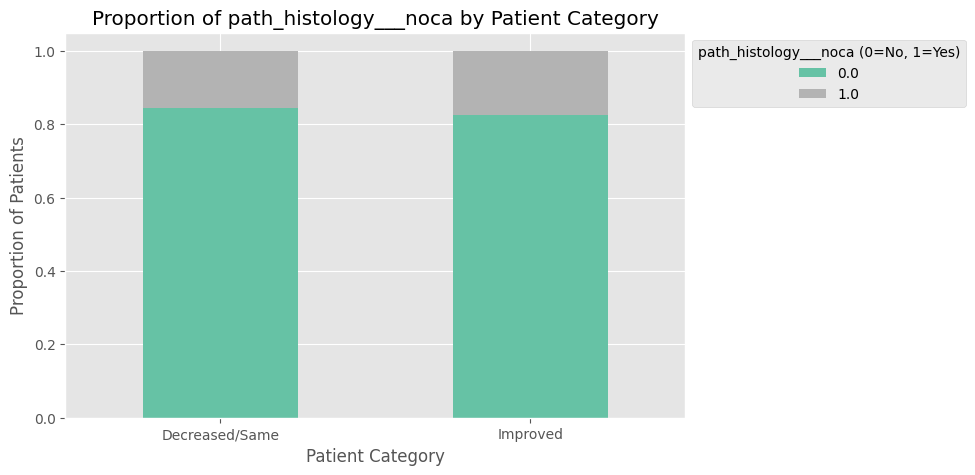


### Analyzing: path_histology___hgd ###

(120, 7)
path_histology___hgd  0.0  1.0
Trend Category                
Decreased/Same         64    6
Improved               45    5
Chi-Square Test p-value: 1.0
Fisher's Exact Test p-value: 1.0
                            Logit Regression Results                            
Dep. Variable:     path_histology___hgd   No. Observations:                  120
Model:                            Logit   Df Residuals:                      118
Method:                             MLE   Df Model:                            1
Date:                  Thu, 17 Apr 2025   Pseudo R-squ.:               0.0009656
Time:                          01:42:35   Log-Likelihood:                -36.730
converged:                         True   LL-Null:                       -36.765
Covariance Type:              nonrobust   LLR p-value:                    0.7899
                            coef    std err          z      P>|z|      [0.025      0.975]
-------------------------

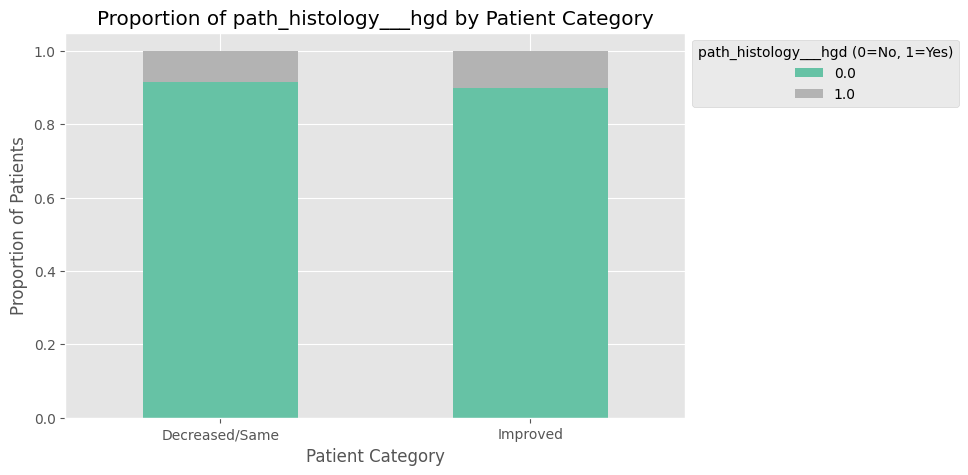


### Analyzing: path_histology___cis ###

(119, 7)
path_histology___cis  0.0  1.0
Trend Category                
Decreased/Same         68    1
Improved               49    1
Chi-Square Test p-value: 1.0
Fisher's Exact Test p-value: 1.0
                            Logit Regression Results                            
Dep. Variable:     path_histology___cis   No. Observations:                  119
Model:                            Logit   Df Residuals:                      117
Method:                             MLE   Df Model:                            1
Date:                  Thu, 17 Apr 2025   Pseudo R-squ.:                0.002587
Time:                          01:42:35   Log-Likelihood:                -10.129
converged:                         True   LL-Null:                       -10.155
Covariance Type:              nonrobust   LLR p-value:                    0.8187
                            coef    std err          z      P>|z|      [0.025      0.975]
-------------------------

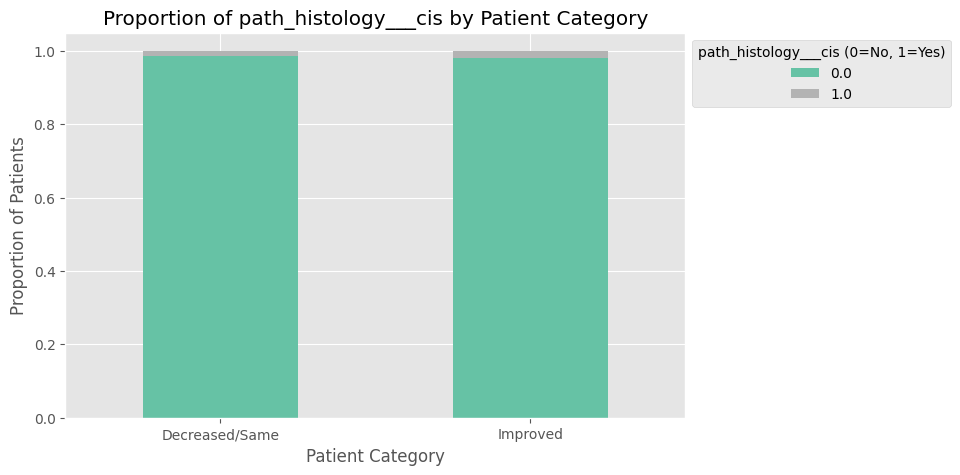


### Analyzing: path_histology___adeno ###

(123, 7)
path_histology___adeno  0.0  1.0
Trend Category                  
Decreased/Same           22   49
Improved                 13   39
Chi-Square Test p-value: 0.5998791321095512
Fisher's Exact Test p-value: 0.5461127305085702
                             Logit Regression Results                             
Dep. Variable:     path_histology___adeno   No. Observations:                  123
Model:                              Logit   Df Residuals:                      121
Method:                               MLE   Df Model:                            1
Date:                    Thu, 17 Apr 2025   Pseudo R-squ.:                0.003625
Time:                            01:42:35   Log-Likelihood:                -73.190
converged:                           True   LL-Null:                       -73.456
Covariance Type:                nonrobust   LLR p-value:                    0.4655
                            coef    std err          z     

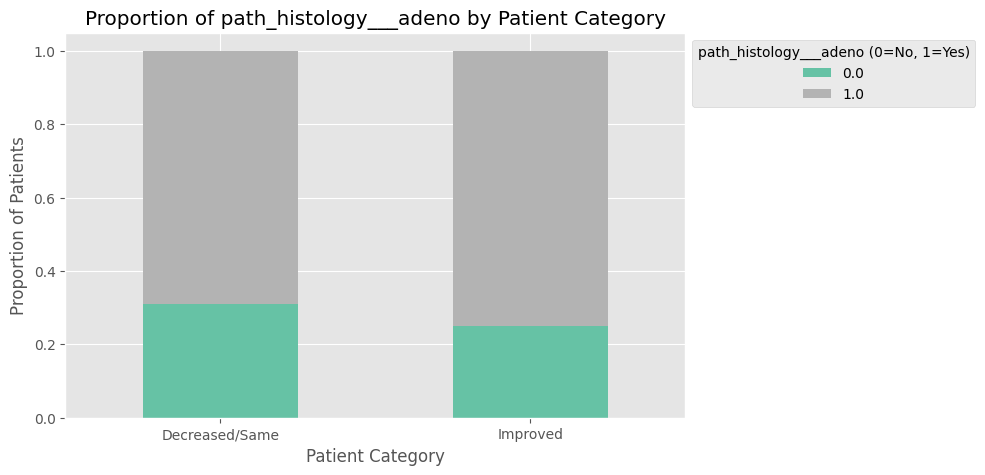


### Analyzing: path_histology___scc ###

(119, 7)
path_histology___scc  0.0  1.0
Trend Category                
Decreased/Same         59   10
Improved               47    3
Chi-Square Test p-value: 0.24271632969201623
Fisher's Exact Test p-value: 0.2331991192701075
                            Logit Regression Results                            
Dep. Variable:     path_histology___scc   No. Observations:                  119
Model:                            Logit   Df Residuals:                      117
Method:                             MLE   Df Model:                            1
Date:                  Thu, 17 Apr 2025   Pseudo R-squ.:                 0.02791
Time:                          01:42:36   Log-Likelihood:                -39.901
converged:                         True   LL-Null:                       -41.047
Covariance Type:              nonrobust   LLR p-value:                    0.1301
                            coef    std err          z      P>|z|      [0.025      0

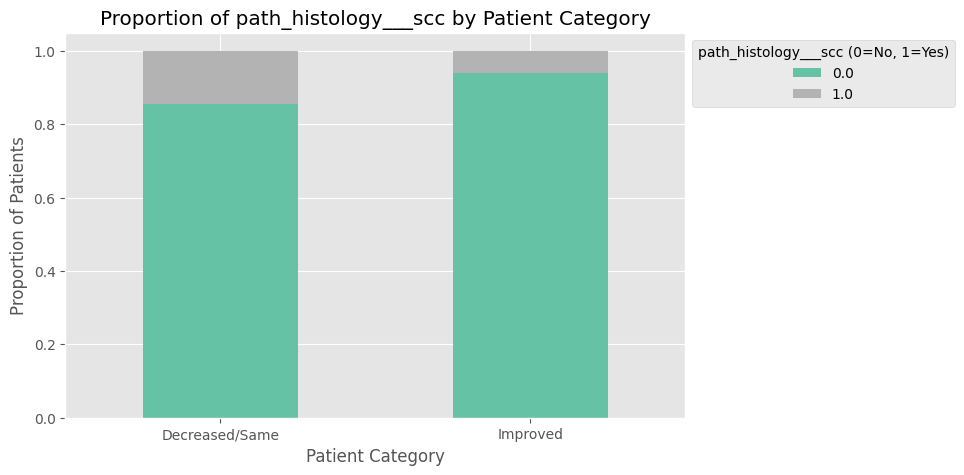


### Analyzing: path_histology___nec ###

(119, 7)
path_histology___nec  0.0  1.0
Trend Category                
Decreased/Same         68    1
Improved               50    0
Chi-Square Test p-value: 1.0
Fisher's Exact Test p-value: 1.0
                            Logit Regression Results                            
Dep. Variable:     path_histology___nec   No. Observations:                  119
Model:                            Logit   Df Residuals:                      117
Method:                             MLE   Df Model:                            1
Date:                  Thu, 17 Apr 2025   Pseudo R-squ.:                 0.09491
Time:                          01:42:36   Log-Likelihood:                -5.2268
converged:                        False   LL-Null:                       -5.7749
Covariance Type:              nonrobust   LLR p-value:                    0.2951
                            coef    std err          z      P>|z|      [0.025      0.975]
-------------------------

/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


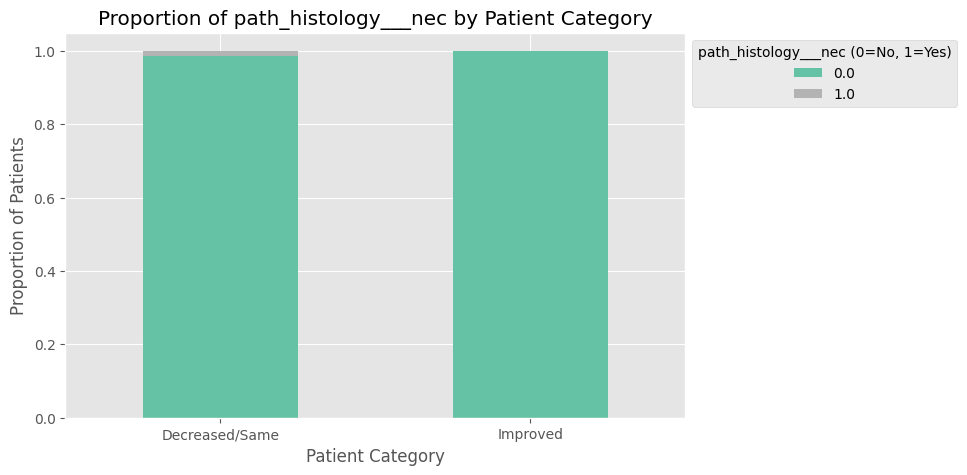


### Analyzing: path_histology___other ###

(119, 7)
path_histology___other  0.0  1.0
Trend Category                  
Decreased/Same           65    4
Improved                 48    2
Chi-Square Test p-value: 0.9857732355230522
Fisher's Exact Test p-value: 1.0
                             Logit Regression Results                             
Dep. Variable:     path_histology___other   No. Observations:                  119
Model:                              Logit   Df Residuals:                      117
Method:                               MLE   Df Model:                            1
Date:                    Thu, 17 Apr 2025   Pseudo R-squ.:                0.004212
Time:                            01:42:36   Log-Likelihood:                -23.670
converged:                           True   LL-Null:                       -23.770
Covariance Type:                nonrobust   LLR p-value:                    0.6545
                            coef    std err          z      P>|z|      [0.

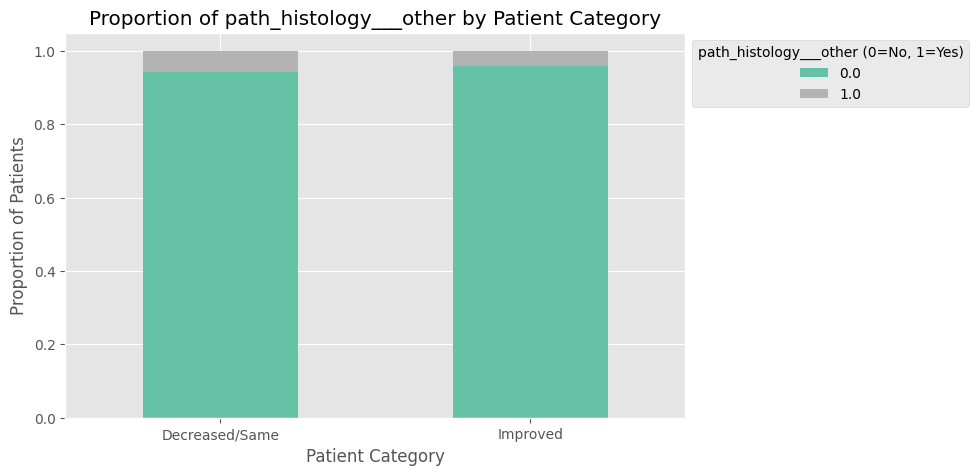

In [ ]:
# List of binary histology columns
histology_columns = [
    "path_histology___noca", 
    "path_histology___hgd", 
    "path_histology___cis", 
    "path_histology___adeno", 
    "path_histology___scc", 
    "path_histology___nec", 
    "path_histology___other"
]

for col in histology_columns:
    print(f"\n### Analyzing: {col} ###\n")
    
    # Merge data
    merged_df = score_comparison.merge(filtered_df[["id", col]], on="id", how="left")
    
    # Remove rows where histology data is missing
    merged_df = merged_df.dropna(subset=[col])
    merged_df = merged_df.drop_duplicates()
    print(merged_df.shape)
    
    # Create a contingency table
    contingency_table = pd.crosstab(merged_df["Trend Category"], merged_df[col])
    print(contingency_table)
    
    # Chi-square test
    chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    print(f"Chi-Square Test p-value: {p_value}")
    
    # Fisher's Exact Test (only if 2x2 table)
    if contingency_table.shape == (2, 2):
        odds_ratio, p_value_fisher = stats.fisher_exact(contingency_table)
        print(f"Fisher's Exact Test p-value: {p_value_fisher}")
    
    # Convert Trend Category to binary (1 = Improved, 0 = Decreased/Same)
    merged_df["Trend Category_binary"] = merged_df["Trend Category"].map({"Improved": 1, "Decreased/Same": 0})
    
    # Logistic Regression Model
    X = sm.add_constant(merged_df["Trend Category_binary"])
    y = merged_df[col]  # Histology variable (0/1)
    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        print(result.summary())
    except Exception as e:
        print(f"Logistic regression failed: {e}")
    
    # Create proportion table
    proportions = merged_df.groupby("Trend Category")[col].value_counts(normalize=True).unstack()
    
    # Plot bar chart
    proportions.plot(kind="bar", stacked=True, colormap="Set2", figsize=(8, 5))
    plt.xlabel("Patient Category")
    plt.ylabel("Proportion of Patients")
    plt.title(f"Proportion of {col} by Patient Category")
    plt.legend(title=f"{col} (0=No, 1=Yes)", bbox_to_anchor=(1, 1))
    plt.xticks(rotation=0)
    plt.show()

# sensitivity analysis 6) histology (path_histology)

### single column

In [73]:
single_histology_df

,id,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,path_histology___noca,path_histology___hgd,path_histology___cis,path_histology___adeno,path_histology___scc,path_histology___nec,path_histology___other,histology_count,histology_type
7,32,117.5,159.000000,41.500000,True,Improved,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NOCA
14,76,95.0,97.000000,2.000000,False,Decreased/Same,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,Adenocarcinoma
21,125,119.5,129.000000,9.500000,True,Improved,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,Adenocarcinoma
36,160,119.0,152.000000,33.000000,True,Improved,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,Adenocarcinoma
53,230,133.8,53.000000,-80.800000,False,Decreased/Same,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,Adenocarcinoma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1270,1531,139.0,109.166667,-29.833333,False,Decreased/Same,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,Adenocarcinoma
1283,1560,154.0,151.833333,-2.166667,False,Decreased/Same,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,Adenocarcinoma
1295,1566,150.0,107.000000,-43.000000,False,Decreased/Same,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,Adenocarcinoma
1303,1571,153.0,104.000000,-49.000000,False,Decreased/Same,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NOCA


In [74]:
def analyze_histology_threshold_relationship(data, threshold):
    """
    Analyze how histology relates to improvement at different thresholds
    
    Parameters:
    data: DataFrame containing Change and histology_type columns
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    
    # Check for missing histology type values
    df = df.dropna(subset=["histology_type"])
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count if total_count > 0 else 0
    
    # Create a contingency table
    contingency_table = pd.crosstab(df["histology_type"], df["Trend Category"])
    
    # Chi-square test
    try:
        chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency_table)
    except:
        chi2_stat, chi2_p, dof, expected = None, None, None, None
    
    # Calculate improvement rate for each histology type
    histology_improvement_rates = {}
    for histology in df["histology_type"].unique():
        histology_df = df[df["histology_type"] == histology]
        if len(histology_df) > 0:
            histology_improvement_rates[histology] = histology_df["Improved"].mean()
    
    # Logistic regression with histology as categorical
    try:
        # Create dummy variables for histology
        histology_dummies = pd.get_dummies(df["histology_type"], prefix="Histology", drop_first=True)
        
        # Add constant
        X = sm.add_constant(histology_dummies)
        y = df["Improved"].astype(int)
        
        # Fit model
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        
        # Extract p-value for overall model
        lr_p_value = result.llr_pvalue
    except:
        lr_p_value = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2_stat,
        "chi2_p": chi2_p,
        "histology_improvement_rates": histology_improvement_rates,
        "lr_p_value": lr_p_value
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Use the existing single_histology_df
clean_df = single_histology_df.dropna(subset=["Change", "histology_type"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_histology_threshold_relationship(clean_df, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis of Histology Type and Improvement at Different Thresholds:")
print(sensitivity_df[["threshold", "improvement_rate", "chi2_p", "lr_p_value"]].round(4))



Sensitivity Analysis of Histology Type and Improvement at Different Thresholds:
    threshold  improvement_rate  chi2_p lr_p_value
0           0            0.5000  0.3085       None
1           1            0.5000  0.3085       None
2           2            0.5000  0.3085       None
3           3            0.4352  0.2622       None
4           4            0.4259  0.2781       None
5           5            0.4259  0.2781       None
6           6            0.4074  0.3193       None
7           7            0.3981  0.3391       None
8           8            0.3704  0.3776       None
9           9            0.3611  0.3821       None
10         10            0.3426  0.1913       None


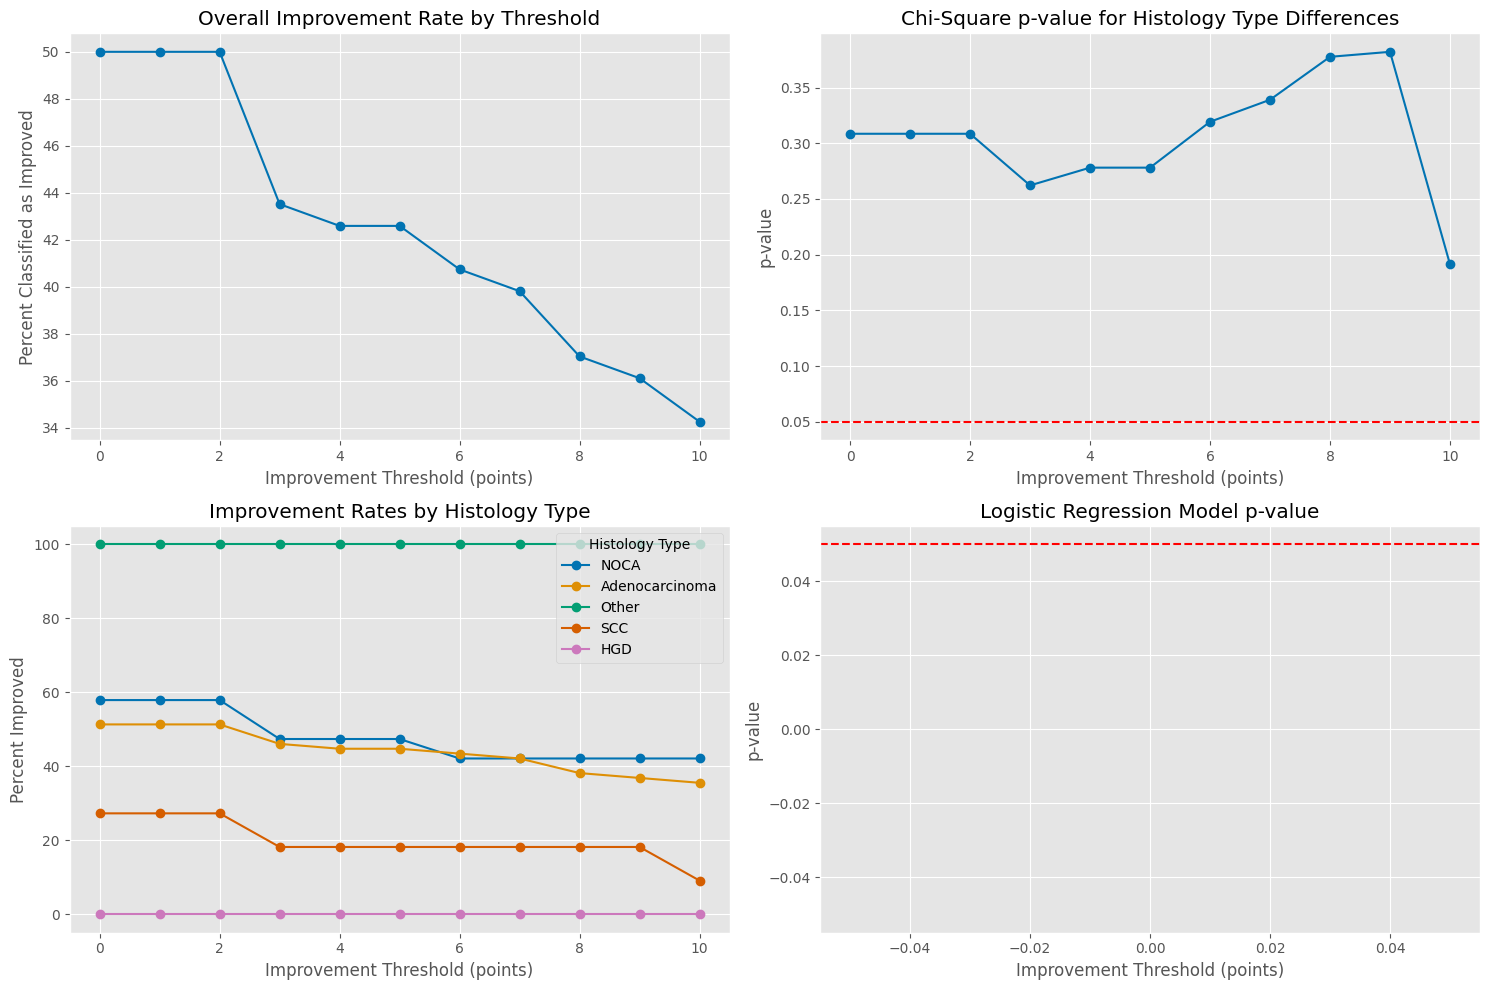


Contingency Table at 5-point threshold:
Trend Category  Decreased/Same  Improved
histology_type                          
Adenocarcinoma              42        34
HGD                          1         0
NOCA                        10         9
Other                        0         1
SCC                          9         2

Chi-Square Test at 5-point threshold:
Chi-square statistic: 5.0906
p-value: 0.2781
Degrees of freedom: 4


<Figure size 1200x700 with 0 Axes>

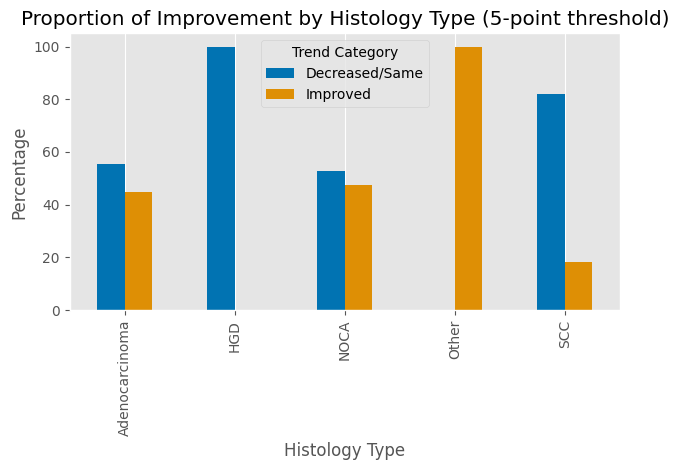

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [75]:
# Extract histology-specific improvement rates for each threshold
histology_rates_by_threshold = {}
for idx, row in sensitivity_df.iterrows():
    threshold = row["threshold"]
    histology_rates = row["histology_improvement_rates"]
    if histology_rates is not None:
        histology_rates_by_threshold[threshold] = histology_rates

# Convert to DataFrame for easier plotting
histology_rates_df = pd.DataFrame(histology_rates_by_threshold).T
histology_rates_df.index.name = "threshold"
histology_rates_df = histology_rates_df.reset_index()

# Create plots to visualize the results
plt.figure(figsize=(15, 10))

# Plot 1: Improvement rate by threshold
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["improvement_rate"] * 100, 'o-')
plt.title("Overall Improvement Rate by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Percent Classified as Improved")
plt.grid(True)

# Plot 2: Chi-square p-values for histology differences
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["chi2_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Chi-Square p-value for Histology Type Differences")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot 3: Improvement rates by histology across thresholds
plt.subplot(2, 2, 3)
for col in histology_rates_df.columns:
    if col != "threshold":
        plt.plot(histology_rates_df["threshold"], histology_rates_df[col] * 100, 'o-', label=col)
plt.title("Improvement Rates by Histology Type")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Percent Improved")
plt.legend(title="Histology Type")
plt.grid(True)

# Plot 4: Logistic regression p-values
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["lr_p_value"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression Model p-value")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Additional analysis: Detailed look at 5-point threshold
threshold_5 = clean_df.copy()
threshold_5["Improved"] = threshold_5["Change"] >= 5
threshold_5["Trend Category"] = threshold_5["Improved"].map({True: "Improved", False: "Decreased/Same"})

# Create contingency table for histology vs improvement at 5-point threshold
contingency_5 = pd.crosstab(threshold_5["histology_type"], threshold_5["Trend Category"])
print("\nContingency Table at 5-point threshold:")
print(contingency_5)

# Chi-square test
chi2_stat_5, chi2_p_5, dof_5, expected_5 = stats.chi2_contingency(contingency_5)
print(f"\nChi-Square Test at 5-point threshold:")
print(f"Chi-square statistic: {chi2_stat_5:.4f}")
print(f"p-value: {chi2_p_5:.4f}")
print(f"Degrees of freedom: {dof_5}")

# Visualize with a bar plot
plt.figure(figsize=(12, 7))
proportions = pd.crosstab(
    threshold_5["histology_type"], 
    threshold_5["Trend Category"], 
    normalize="index"
) * 100

proportions.plot(kind="bar", stacked=False)
plt.title("Proportion of Improvement by Histology Type (5-point threshold)")
plt.xlabel("Histology Type")
plt.ylabel("Percentage")
plt.legend(title="Trend Category")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Logistic regression for histology at 5-point threshold
histology_dummies_5 = pd.get_dummies(threshold_5["histology_type"], prefix="Histology", drop_first=True)
X_5 = sm.add_constant(histology_dummies_5)
y_5 = threshold_5["Improved"].astype(int)

logit_model_5 = sm.Logit(y_5, X_5)
result_5 = logit_model_5.fit()

print("\nLogistic Regression Results at 5-point threshold:")
print(result_5.summary())

# Calculate odds ratios and confidence intervals
print("\nOdds Ratios for Histology Types (relative to reference level):")
params = result_5.params
conf = result_5.conf_int()
conf['OR'] = params
conf.columns = ['2.5%', '97.5%', 'OR']
conf['OR'] = np.exp(conf['OR'])
conf['2.5%'] = np.exp(conf['2.5%'])
conf['97.5%'] = np.exp(conf['97.5%'])
print(conf.iloc[1:])  # Skip the constant

# Count sample sizes for each histology type
histology_counts = threshold_5["histology_type"].value_counts().sort_index()
print("\nSample size for each histology type:")
print(histology_counts)

### multiple columns

/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_66406/32114075.py:87: RuntimeWarning: overflow encountered in exp
  upper_ci = np.exp(var_conf_int[1])
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_66406/32114075.py:87: RuntimeWarning: overflow encountered in exp
  upper_ci = np.exp(var_conf_int[1])
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_66406/32114075.py:87: RuntimeWarning: overflow enc

Chi-square Test p-values across thresholds:
variable   path_histology___adeno  path_histology___cis  path_histology___hgd  \
threshold                                                                       
0                          0.9119                   1.0                1.0000   
1                          0.6975                   1.0                1.0000   
2                          0.6975                   1.0                1.0000   
3                          0.6499                   1.0                1.0000   
4                          0.7317                   1.0                1.0000   
5                          0.7317                   1.0                1.0000   
6                          0.6060                   1.0                0.9487   
7                          0.7703                   1.0                1.0000   
8                          1.0000                   1.0                1.0000   
9                          1.0000                   1.0          

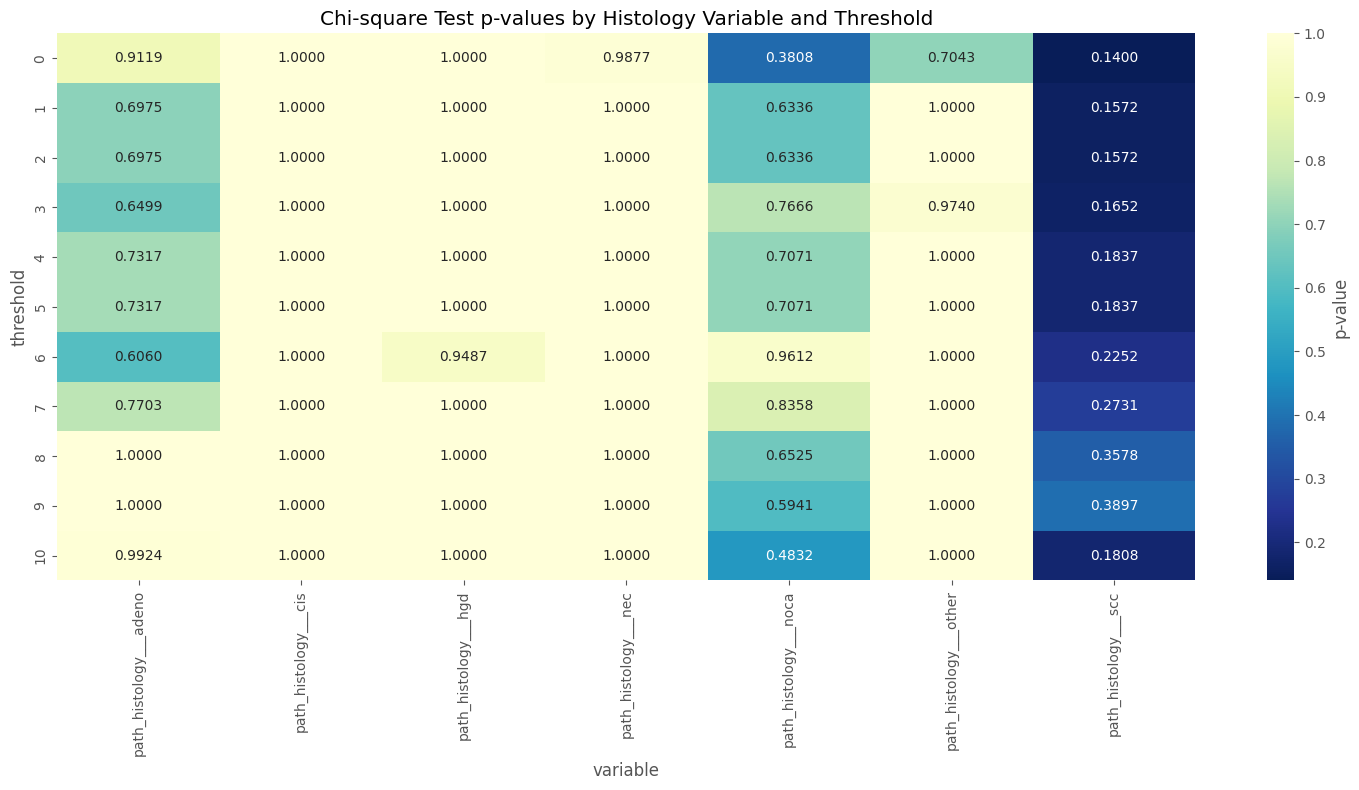

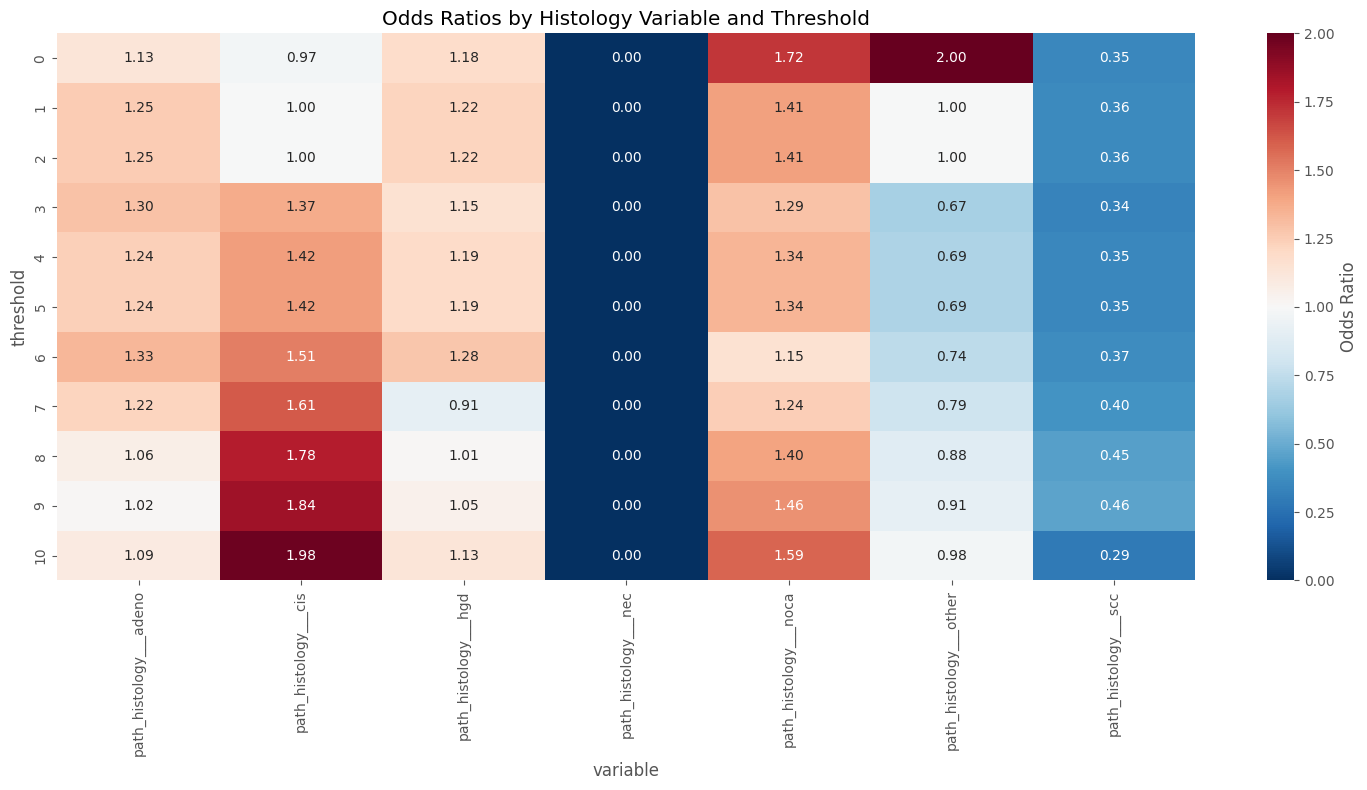

<Figure size 1500x800 with 0 Axes>

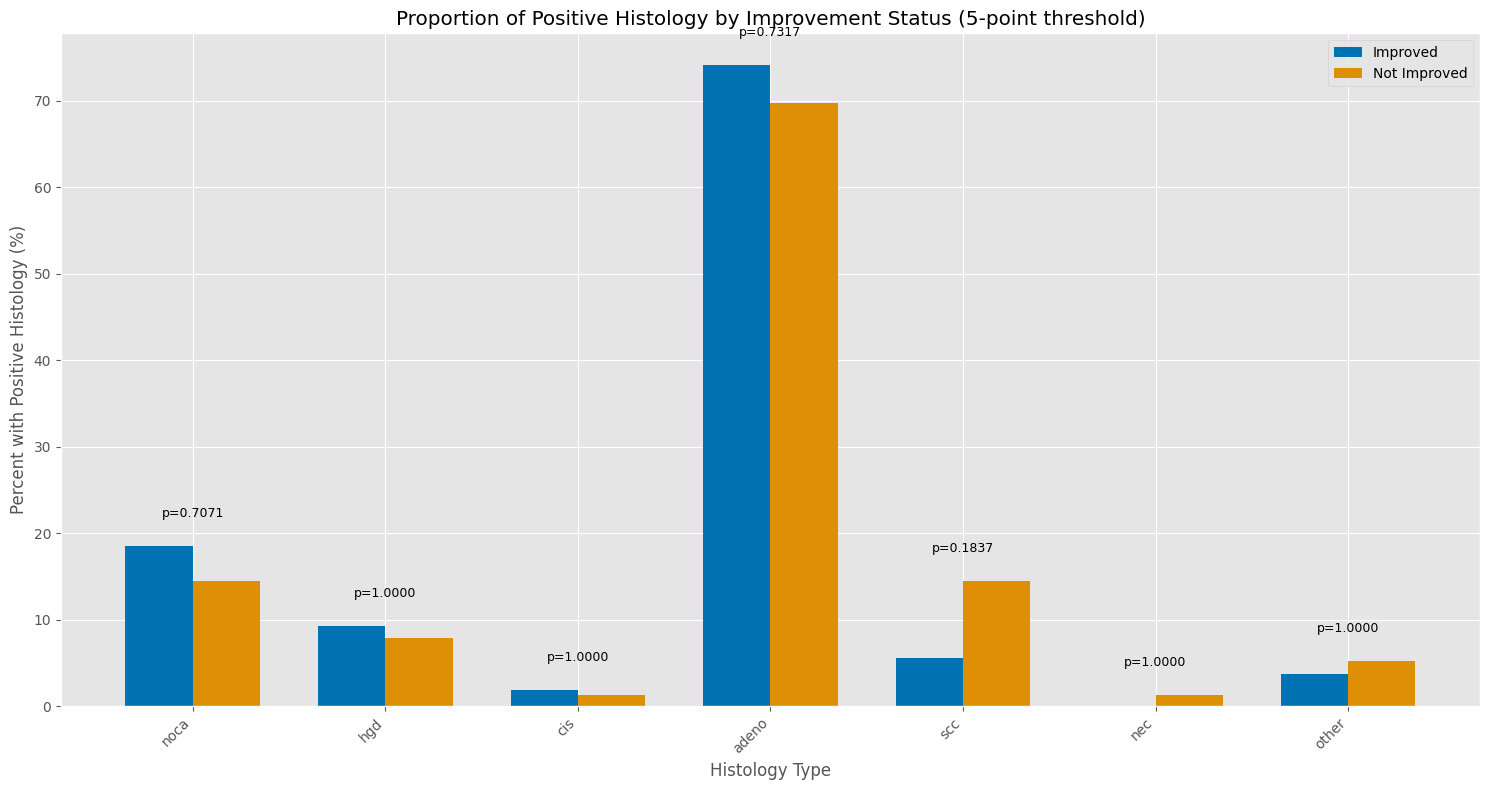


Chi-square Test Results at 5-point threshold:
Variable                  Chi-square    p-value
--------------------------------------------
noca                      0.14       0.7071
Contingency table for noca:
          Not Improved  Improved
Negative            65        44
Positive            11        10

hgd                       0.00       1.0000
Contingency table for hgd:
          Not Improved  Improved
Negative            70        49
Positive             6         5

cis                       0.00       1.0000
Contingency table for cis:
          Not Improved  Improved
Negative            75        53
Positive             1         1

adeno                     0.12       0.7317
Contingency table for adeno:
          Not Improved  Improved
Negative            23        14
Positive            53        40

scc                       1.77       0.1837
Contingency table for scc:
          Not Improved  Improved
Negative            65        51
Positive            11         3

ne

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
import seaborn as sns

# Define the list of histology columns
histology_columns = [
    "path_histology___noca",
    "path_histology___hgd",
    "path_histology___cis", 
    "path_histology___adeno",
    "path_histology___scc",
    "path_histology___nec",
    "path_histology___other"
]

def analyze_binary_variable_threshold(data, binary_var, threshold):
    """
    Analyze how a single binary variable relates to improvement at different thresholds
    
    Parameters:
    data: DataFrame containing Change and the binary variable
    binary_var: Name of the binary variable to analyze
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    
    # Remove rows where the binary variable is missing
    df = df.dropna(subset=[binary_var])
    
    # Ensure binary variable is numeric
    df[binary_var] = df[binary_var].astype(float)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count if total_count > 0 else 0
    
    # Chi-square test for binary variable vs improvement
    contingency = pd.crosstab(df[binary_var], df["Improved"])
    
    # Make sure the contingency table has both 0 and 1 values for the binary variable
    if contingency.shape[0] == 2:
        try:
            chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency)
        except:
            chi2_stat, chi2_p, dof, expected = None, None, None, None
    else:
        chi2_stat, chi2_p, dof, expected = None, None, None, None
    
    # Calculate proportion of patients with positive binary variable by improvement status
    if len(df[df["Improved"]]) > 0:
        pos_rate_improved = df[df["Improved"]][binary_var].mean()
    else:
        pos_rate_improved = None
        
    if len(df[~df["Improved"]]) > 0:
        pos_rate_not_improved = df[~df["Improved"]][binary_var].mean()
    else:
        pos_rate_not_improved = None
    
    # Logistic regression
    try:
        X = sm.add_constant(df[binary_var])
        y = df["Improved"].astype(int)
        
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        
        var_coef = result.params[binary_var]
        var_p = result.pvalues[binary_var]
        var_or = np.exp(var_coef)
        
        # Confidence intervals
        var_conf_int = result.conf_int().loc[binary_var]
        lower_ci = np.exp(var_conf_int[0])
        upper_ci = np.exp(var_conf_int[1])
    except:
        var_coef, var_p, var_or = None, None, None
        lower_ci, upper_ci = None, None
    
    return {
        "variable": binary_var,
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2_stat,
        "chi2_p": chi2_p,
        "pos_rate_improved": pos_rate_improved,
        "pos_rate_not_improved": pos_rate_not_improved,
        "logistic_coef": var_coef,
        "logistic_p": var_p,
        "odds_ratio_lr": var_or,
        "or_lower_ci": lower_ci,
        "or_upper_ci": upper_ci
    }

# Run the analysis for all histology variables across different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
all_results = []

# Merge histology data with score comparison data
histology_data = score_comparison.merge(
    filtered_df[["id"] + histology_columns], 
    on="id", 
    how="left"
)

# Run analysis for each variable and threshold
for var in histology_columns:
    for threshold in thresholds:
        result = analyze_binary_variable_threshold(histology_data, var, threshold)
        all_results.append(result)

# Convert to DataFrame for easier analysis
all_sensitivity_df = pd.DataFrame(all_results)

# Create a pivot table to see p-values for all variables across thresholds
pvalue_pivot = all_sensitivity_df.pivot(index="threshold", columns="variable", values="chi2_p")
print("Chi-square Test p-values across thresholds:")
print(pvalue_pivot.round(4))

# Create a pivot table for odds ratios from logistic regression
or_pivot = all_sensitivity_df.pivot(index="threshold", columns="variable", values="odds_ratio_lr")
print("\nOdds Ratios across thresholds:")
print(or_pivot.round(2))

# Create heatmaps to visualize results
plt.figure(figsize=(15, 8))
sns.heatmap(pvalue_pivot, annot=True, cmap="YlGnBu_r", fmt=".4f", cbar_kws={'label': 'p-value'})
plt.title("Chi-square Test p-values by Histology Variable and Threshold")
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 8))
sns.heatmap(or_pivot, annot=True, cmap="RdBu_r", center=1, fmt=".2f", cbar_kws={'label': 'Odds Ratio'})
plt.title("Odds Ratios by Histology Variable and Threshold")
plt.tight_layout()
plt.show()

# Detailed analysis at 5-point threshold
threshold_5_results = all_sensitivity_df[all_sensitivity_df["threshold"] == 5]

# Create a bar chart for the proportion of positive histology by improvement status
plt.figure(figsize=(15, 8))

variable_names = []
improved_rates = []
not_improved_rates = []

for _, row in threshold_5_results.iterrows():
    variable_names.append(row["variable"].replace("path_histology___", ""))
    improved_rates.append(row["pos_rate_improved"] * 100 if row["pos_rate_improved"] is not None else 0)
    not_improved_rates.append(row["pos_rate_not_improved"] * 100 if row["pos_rate_not_improved"] is not None else 0)

x = np.arange(len(variable_names))
width = 0.35

fig, ax = plt.subplots(figsize=(15, 8))
rects1 = ax.bar(x - width/2, improved_rates, width, label='Improved')
rects2 = ax.bar(x + width/2, not_improved_rates, width, label='Not Improved')

ax.set_xlabel('Histology Type')
ax.set_ylabel('Percent with Positive Histology (%)')
ax.set_title('Proportion of Positive Histology by Improvement Status (5-point threshold)')
ax.set_xticks(x)
ax.set_xticklabels(variable_names, rotation=45, ha='right')
ax.legend()

# Add p-value annotations using chi-square test
for i, var in enumerate(variable_names):
    full_var = "path_histology___" + var
    p_val = threshold_5_results[threshold_5_results["variable"] == full_var]["chi2_p"].values[0]
    if pd.notna(p_val):
        ax.text(i, max(improved_rates[i], not_improved_rates[i]) + 3, f'p={p_val:.4f}', 
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# For each histology variable at the 5-point threshold, create a contingency table and report chi-square results
print("\nChi-square Test Results at 5-point threshold:")
print("Variable                  Chi-square    p-value")
print("--------------------------------------------")

for var in histology_columns:
    # Create a contingency table for this variable at threshold 5
    threshold_5 = histology_data.copy()
    threshold_5["Improved"] = threshold_5["Change"] >= 5
    threshold_5 = threshold_5.dropna(subset=[var])
    threshold_5[var] = threshold_5[var].astype(float)
    
    contingency = pd.crosstab(threshold_5[var], threshold_5["Improved"])
    
    if contingency.shape[0] == 2:  # Make sure we have both 0 and 1 values
        try:
            chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency)
            var_name = var.replace("path_histology___", "")
            print(f"{var_name.ljust(25)} {chi2_stat:.2f}       {chi2_p:.4f}")
            
            # Print the contingency table for better interpretation
            print(f"Contingency table for {var_name}:")
            contingency.columns = ["Not Improved", "Improved"]
            contingency.index = ["Negative", "Positive"]
            print(contingency)
            print()
        except:
            var_name = var.replace("path_histology___", "")
            print(f"{var_name.ljust(25)} Not available")
    else:
        var_name = var.replace("path_histology___", "")
        print(f"{var_name.ljust(25)} Not available (insufficient data)")

# Logistic regression summary for all variables at 5-point threshold
print("\nLogistic Regression Results at 5-point threshold:")
print("Variable                  Odds Ratio    95% CI           p-value")
print("----------------------------------------------------------------")
for _, row in threshold_5_results.iterrows():
    var_name = row["variable"].replace("path_histology___", "")
    or_val = row["odds_ratio_lr"]
    lower_ci = row["or_lower_ci"]
    upper_ci = row["or_upper_ci"]
    p_val = row["logistic_p"]
    
    if pd.notna(or_val) and pd.notna(lower_ci) and pd.notna(upper_ci) and pd.notna(p_val):
        print(f"{var_name.ljust(25)} {or_val:.2f}      ({lower_ci:.2f}-{upper_ci:.2f})    {p_val:.4f}")
    else:
        print(f"{var_name.ljust(25)} Not available")

# statistically significantly associated with 7) bmi

Initial BMI statistics:
count     116.000000
mean       57.098182
std       334.560076
min         1.000100
25%        22.971075
50%        25.903922
75%        30.052663
max      3628.610829
Name: bmi, dtype: float64


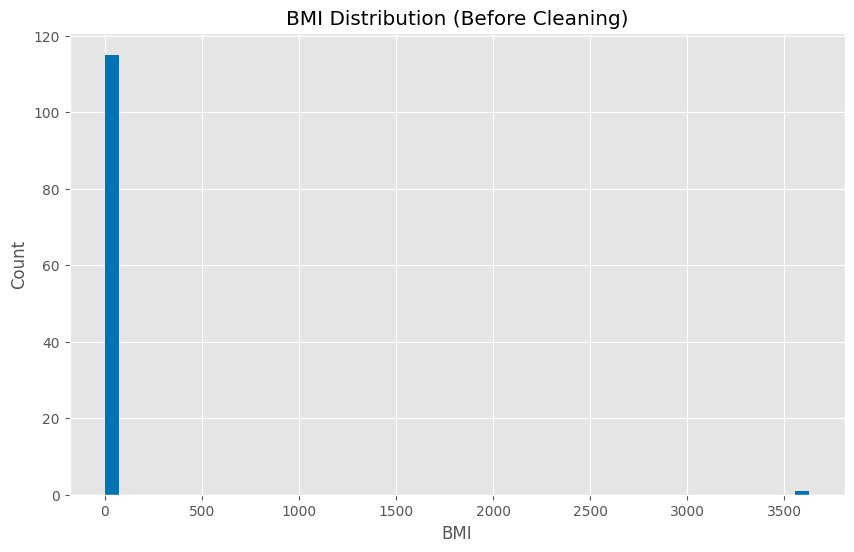

In [129]:
# Merge score_comparison with BMI data
merged_df_bmi = score_comparison.merge(filtered_df[["id", "bmi"]], on="id", how="left")

# Print initial BMI statistics to identify outliers
print("Initial BMI statistics:")
print(merged_df_bmi["bmi"].describe())

# Plot histogram to visualize the distribution before cleaning
plt.figure(figsize=(10, 6))
plt.hist(merged_df_bmi["bmi"].dropna(), bins=50)
plt.title("BMI Distribution (Before Cleaning)")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

In [130]:
# Define acceptable BMI range based on literature
# Lowest documented ~7 (severe starvation), highest ~186 (extreme case)
# Add some margin to be inclusive
MIN_BMI = 7
MAX_BMI = 186

# Flag outliers
outliers = merged_df_bmi[(merged_df_bmi["bmi"] < MIN_BMI) | (merged_df_bmi["bmi"] > MAX_BMI)]
print(f"\nOutliers detected ({len(outliers)} rows):")
print(outliers[["id", "bmi"]])

# Remove outliers and missing values
merged_df_bmi_clean = merged_df_bmi[(merged_df_bmi["bmi"] >= MIN_BMI) & 
                                   (merged_df_bmi["bmi"] <= MAX_BMI)]
merged_df_bmi_clean = merged_df_bmi_clean.dropna(subset=["bmi"])
merged_df_bmi_clean = merged_df_bmi_clean.drop_duplicates()
print(merged_df_bmi_clean.shape)


Outliers detected (3 rows):
      id          bmi
66   307     1.000100
698  780     1.000100
796  889  3628.610829
(110, 7)


In [131]:

# Perform Mann-Whitney U test
improved_bmi = merged_df_bmi_clean[merged_df_bmi_clean["Trend Category"] == "Improved"]["bmi"]
decreased_same_bmi = merged_df_bmi_clean[merged_df_bmi_clean["Trend Category"] == "Decreased/Same"]["bmi"]

stat, p_value = stats.mannwhitneyu(improved_bmi, decreased_same_bmi)
print(f"\nMann-Whitney U test:")
print(f"Statistic: {stat}")
print(f"p-value: {p_value}")


Mann-Whitney U test:
Statistic: 1423.0
p-value: 0.8125787001567815


In [132]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_bmi_clean["Trend Category_binary"] = merged_df_bmi_clean["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Approach 1: Treat BMI as continuous variable
print("\n### Analysis treating BMI as continuous ###")

# Logistic Regression with BMI as continuous variable
X_cont = sm.add_constant(merged_df_bmi_clean["bmi"])
y = merged_df_bmi_clean["Trend Category_binary"]

logit_model_cont = sm.Logit(y, X_cont)
result_cont = logit_model_cont.fit()
print(result_cont.summary())


### Analysis treating BMI as continuous ###
Optimization terminated successfully.
         Current function value: 0.675976
         Iterations 4
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  110
Model:                             Logit   Df Residuals:                      108
Method:                              MLE   Df Model:                            1
Date:                   Fri, 18 Apr 2025   Pseudo R-squ.:               0.0008131
Time:                           02:55:59   Log-Likelihood:                -74.357
converged:                          True   LL-Null:                       -74.418
Covariance Type:               nonrobust   LLR p-value:                    0.7279
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0706      0.877     -0

In [133]:
# Calculate odds ratio for a 5-unit increase in BMI
bmi_coef = result_cont.params["bmi"]
odds_ratio_5units = np.exp(bmi_coef * 5)
print(f"\nOdds Ratio for a 5-unit increase in BMI: {odds_ratio_5units:.3f}")

# Calculate confidence interval for the odds ratio
bmi_conf_int = result_cont.conf_int().loc["bmi"]
lower_ci_5units = np.exp(bmi_conf_int[0] * 5)
upper_ci_5units = np.exp(bmi_conf_int[1] * 5)
print(f"95% CI for a 5-unit increase in BMI: ({lower_ci_5units:.3f}, {upper_ci_5units:.3f})")

# Approach 2: Categorize BMI into clinical categories
print("\n### Analysis with BMI categories ###")

# Define clinical BMI categories
def categorize_bmi(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

# Add BMI category column
merged_df_bmi_clean["bmi_category"] = merged_df_bmi_clean["bmi"].apply(categorize_bmi)

# Create contingency table
contingency_table_bmi = pd.crosstab(merged_df_bmi_clean["Trend Category"], 
                                   merged_df_bmi_clean["bmi_category"])
print("Contingency Table:")
print(contingency_table_bmi)

# Chi-square test
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table_bmi)
print(f"Chi-Square Test p-value: {p_value}")


Odds Ratio for a 5-unit increase in BMI: 0.946
95% CI for a 5-unit increase in BMI: (0.689, 1.297)

### Analysis with BMI categories ###
Contingency Table:
bmi_category    Normal  Obese  Overweight  Underweight
Trend Category                                        
Decreased/Same      22     20          18            5
Improved            16      9          18            2
Chi-Square Test p-value: 0.41310404375205534


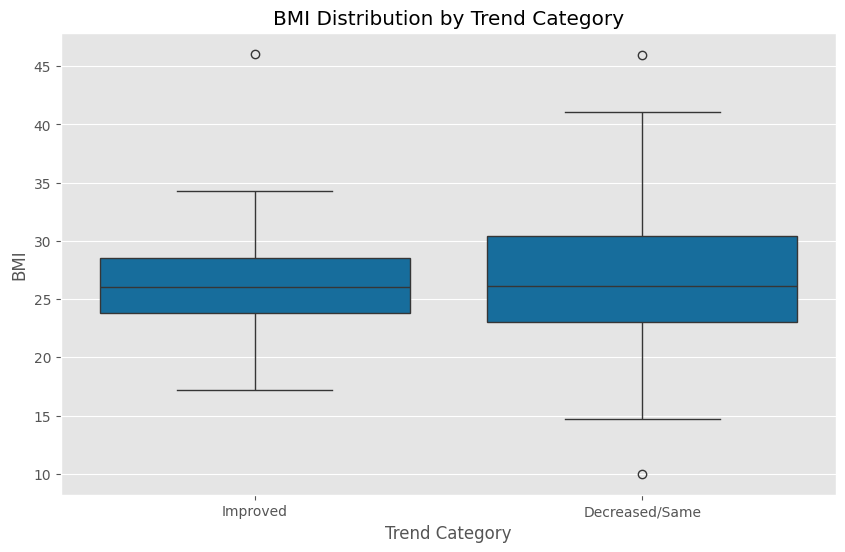

<Figure size 1000x600 with 0 Axes>

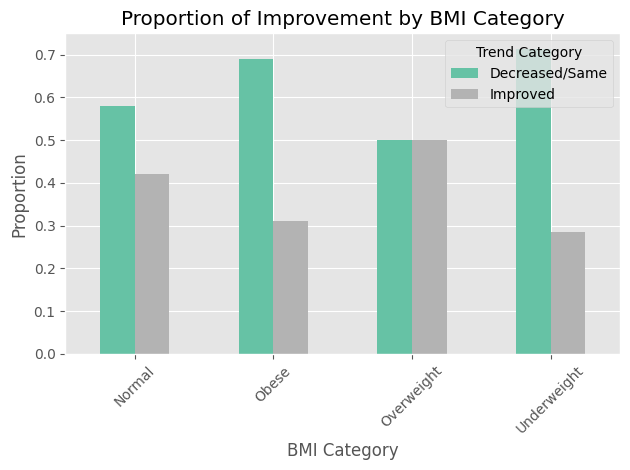

In [134]:

# Visualize the relationship between BMI and improvement
plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="bmi", data=merged_df_bmi_clean)
plt.title("BMI Distribution by Trend Category")
plt.xlabel("Trend Category")
plt.ylabel("BMI")
plt.show()

# Visualize the relationship between BMI categories and Trend Category
plt.figure(figsize=(10, 6))
proportions = pd.crosstab(merged_df_bmi_clean["bmi_category"], 
                         merged_df_bmi_clean["Trend Category"], 
                         normalize="index")
proportions.plot(kind="bar", stacked=False, colormap="Set2")
plt.title("Proportion of Improvement by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Proportion")
plt.legend(title="Trend Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# sensitivity analysis 7) bmi

In [135]:
merged_df_bmi_clean

,id,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,bmi,Trend Category_binary,bmi_category
2,32,117.5,159.000000,41.500000,True,Improved,46.075514,1,Obese
10,76,95.0,97.000000,2.000000,False,Decreased/Same,25.360019,0,Overweight
25,125,119.5,129.000000,9.500000,True,Improved,34.213824,1,Obese
28,160,119.0,152.000000,33.000000,True,Improved,27.115631,1,Overweight
39,198,133.0,139.000000,6.000000,True,Improved,32.922429,1,Obese
...,...,...,...,...,...,...,...,...,...
1281,1560,154.0,151.833333,-2.166667,False,Decreased/Same,33.593750,0,Obese
1290,1566,150.0,107.000000,-43.000000,False,Decreased/Same,27.297959,0,Overweight
1298,1571,153.0,104.000000,-49.000000,False,Decreased/Same,33.217993,0,Obese
1312,1572,141.0,115.000000,-26.000000,False,Decreased/Same,39.100346,0,Obese


In [138]:
def analyze_bmi_threshold_relationship(data, threshold):
    """
    Analyze how BMI relates to improvement at different thresholds
    
    Parameters:
    data: DataFrame containing Change and BMI columns
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    
    # Remove rows where BMI is missing
    df = df.dropna(subset=["bmi"])
    
    # Remove unrealistic BMI values (below 10 or above 100)
    df = df[(df["bmi"] >= 10) & (df["bmi"] <= 100)]
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count if total_count > 0 else 0
    
    # Mann-Whitney U test to compare BMI between improved and not improved groups
    improved_bmi = df[df["Improved"]]["bmi"]
    decreased_same_bmi = df[~df["Improved"]]["bmi"]
    
    if len(improved_bmi) > 0 and len(decreased_same_bmi) > 0:
        stat, p_value = stats.mannwhitneyu(improved_bmi, decreased_same_bmi)
    else:
        stat, p_value = None, None
    
    # Mean and median BMI in each group
    mean_bmi_improved = improved_bmi.mean() if len(improved_bmi) > 0 else None
    mean_bmi_not_improved = decreased_same_bmi.mean() if len(decreased_same_bmi) > 0 else None
    median_bmi_improved = improved_bmi.median() if len(improved_bmi) > 0 else None
    median_bmi_not_improved = decreased_same_bmi.median() if len(decreased_same_bmi) > 0 else None
    
    # Logistic regression with BMI as predictor
    try:
        X = sm.add_constant(df["bmi"])
        y = df["Improved"].astype(int)
        
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        
        bmi_coef = result.params["bmi"]
        bmi_p = result.pvalues["bmi"]
        odds_ratio = np.exp(bmi_coef)
        
        # Calculate odds ratio for 5-unit increase in BMI
        odds_ratio_5unit = np.exp(bmi_coef * 5)
        
        # Confidence intervals
        bmi_conf_int = result.conf_int().loc["bmi"]
        lower_ci = np.exp(bmi_conf_int[0])
        upper_ci = np.exp(bmi_conf_int[1])
        
        # Confidence intervals for 5-unit increase
        lower_ci_5unit = np.exp(bmi_conf_int[0] * 5)
        upper_ci_5unit = np.exp(bmi_conf_int[1] * 5)
    except:
        bmi_coef, bmi_p, odds_ratio = None, None, None
        odds_ratio_5unit = None
        lower_ci, upper_ci = None, None
        lower_ci_5unit, upper_ci_5unit = None, None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "mann_whitney_stat": stat,
        "mann_whitney_p": p_value,
        "mean_bmi_improved": mean_bmi_improved,
        "mean_bmi_not_improved": mean_bmi_not_improved,
        "median_bmi_improved": median_bmi_improved,
        "median_bmi_not_improved": median_bmi_not_improved,
        "logistic_coef": bmi_coef,
        "logistic_p": bmi_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_5unit": odds_ratio_5unit,
        "or_lower_ci": lower_ci,
        "or_upper_ci": upper_ci,
        "or_lower_ci_5unit": lower_ci_5unit,
        "or_upper_ci_5unit": upper_ci_5unit
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Make sure the dataset is clean for analysis
clean_df = merged_df_bmi_clean.dropna(subset=["Change", "bmi"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_bmi_threshold_relationship(clean_df, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis of BMI and Improvement at Different Thresholds:")
print(sensitivity_df[["threshold", "improvement_rate", "mean_bmi_improved", 
                      "mean_bmi_not_improved", "mann_whitney_p", "odds_ratio_5unit"]].round(4))

Sensitivity Analysis of BMI and Improvement at Different Thresholds:
    threshold  improvement_rate  mean_bmi_improved  mean_bmi_not_improved  \
0           0            0.5000            26.8043                26.3929   
1           1            0.4909            26.6615                26.5379   
2           2            0.4909            26.6615                26.5379   
3           3            0.4182            26.2901                26.8203   
4           4            0.4091            26.3577                26.7653   
5           5            0.4091            26.3577                26.7653   
6           6            0.4000            26.2269                26.8463   
7           7            0.3818            25.9745                26.9840   
8           8            0.3636            26.1856                26.8345   
9           9            0.3545            26.2472                26.7915   
10         10            0.3364            26.0867                26.8580   

    ma

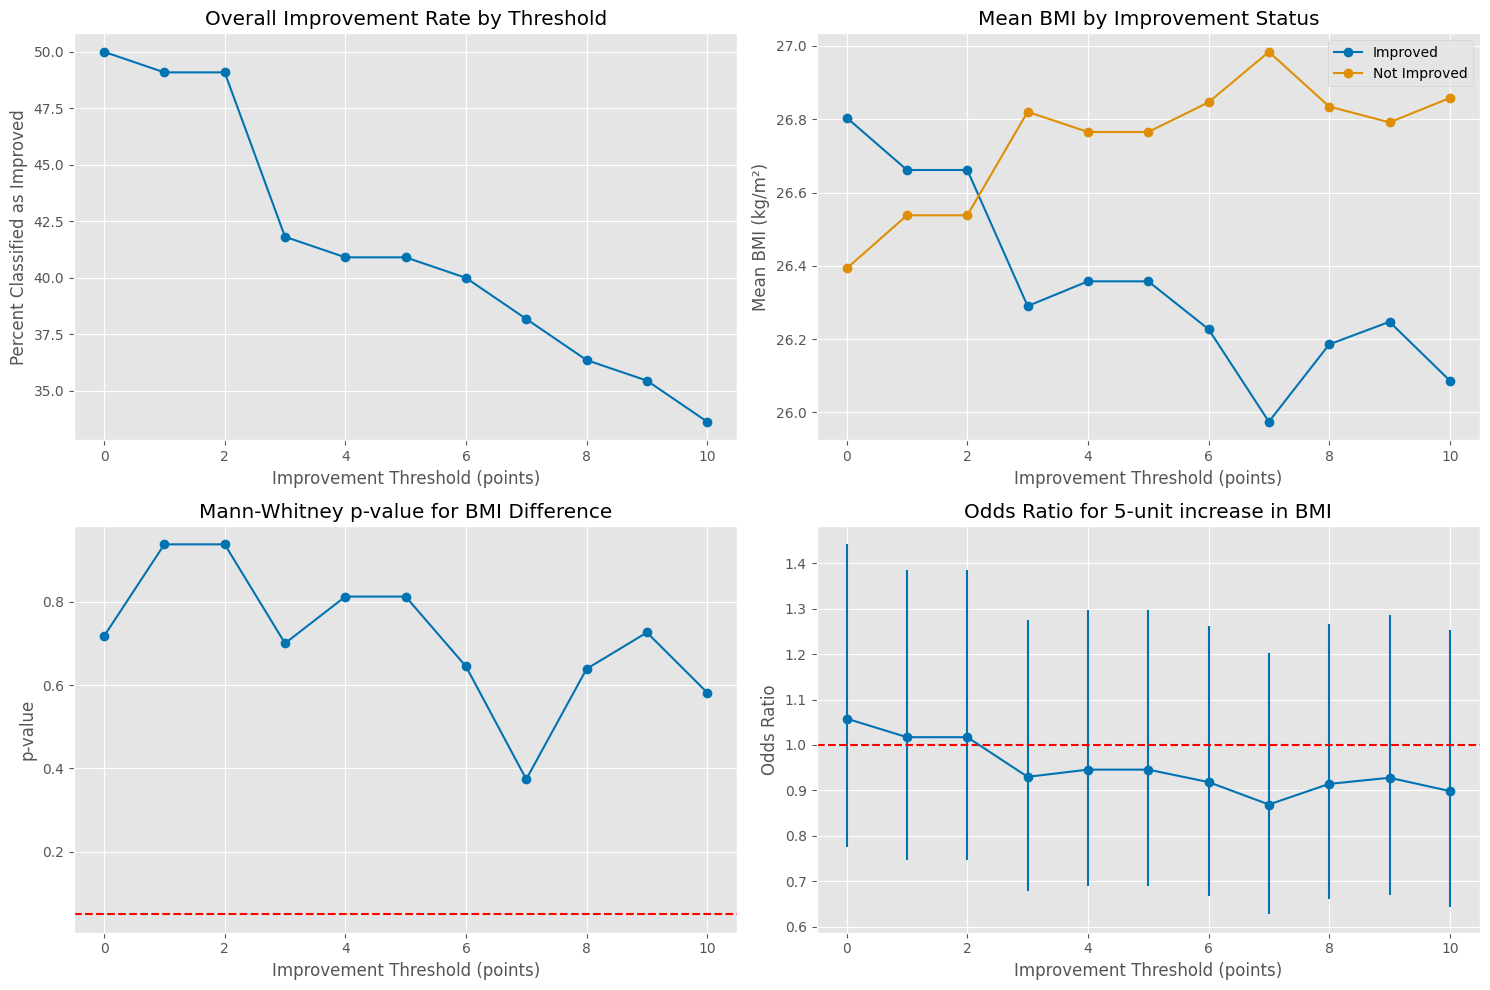

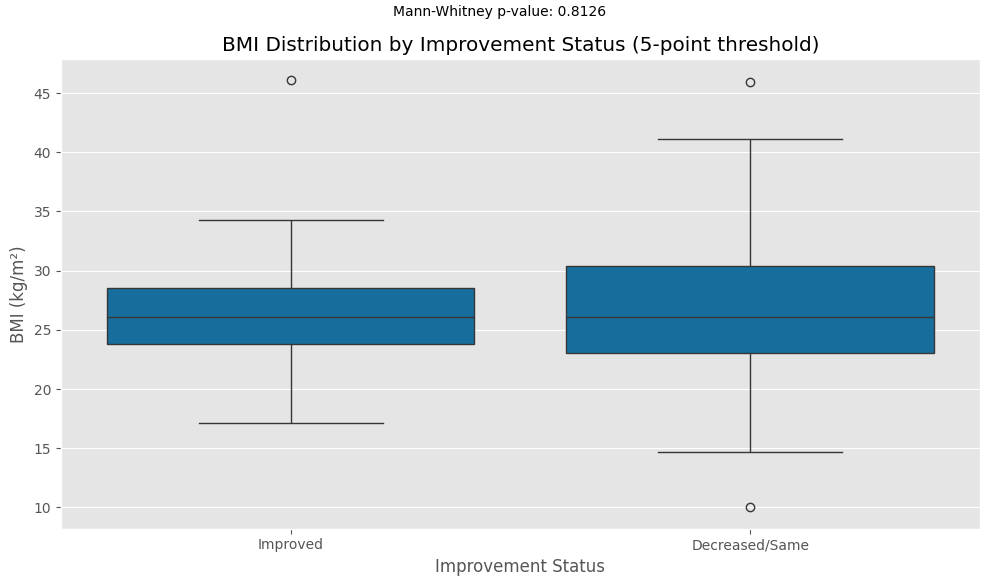


Contingency Table of BMI Categories vs Improvement Status (5-point threshold):
Trend Category      Decreased/Same  Improved
BMI_Category                                
Normal                          22        16
Obese Class I                   14         8
Obese Class II/III               6         1
Overweight                      18        18
Underweight                      5         2

Chi-Square Test for BMI Categories:
Chi-square statistic: 3.9346
p-value: 0.4149
Degrees of freedom: 4


<Figure size 1200x700 with 0 Axes>

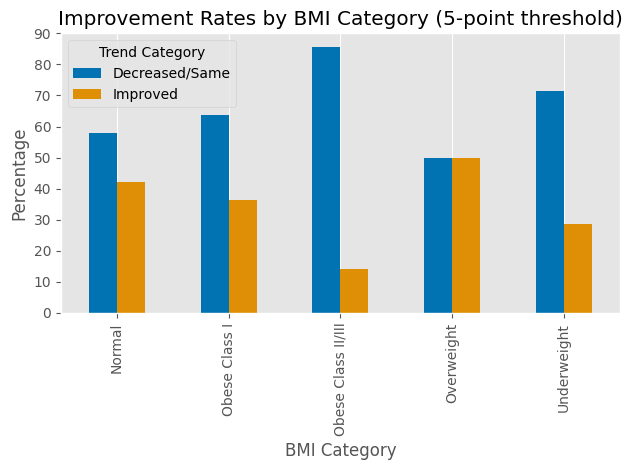

Optimization terminated successfully.
         Current function value: 0.675976
         Iterations 4

Logistic Regression Results at 5-point threshold:
                           Logit Regression Results                           
Dep. Variable:               Improved   No. Observations:                  110
Model:                          Logit   Df Residuals:                      108
Method:                           MLE   Df Model:                            1
Date:                Fri, 18 Apr 2025   Pseudo R-squ.:               0.0008131
Time:                        03:02:27   Log-Likelihood:                -74.357
converged:                       True   LL-Null:                       -74.418
Covariance Type:            nonrobust   LLR p-value:                    0.7279
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0706      0.877     -0.081      0.936   

In [139]:

# Create plots to visualize the results
plt.figure(figsize=(15, 10))

# Plot 1: Improvement rate by threshold
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["improvement_rate"] * 100, 'o-')
plt.title("Overall Improvement Rate by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Percent Classified as Improved")
plt.grid(True)

# Plot 2: Mean BMI by improvement status across thresholds
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_bmi_improved"], 'o-', label='Improved')
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_bmi_not_improved"], 'o-', label='Not Improved')
plt.title("Mean BMI by Improvement Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Mean BMI (kg/m²)")
plt.legend()
plt.grid(True)

# Plot 3: Mann-Whitney p-values for BMI differences
plt.subplot(2, 2, 3)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mann_whitney_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Mann-Whitney p-value for BMI Difference")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot 4: Odds ratios (for 5-unit increase in BMI) with confidence intervals
plt.subplot(2, 2, 4)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio_5unit"],
    yerr=[
        sensitivity_df["odds_ratio_5unit"] - sensitivity_df["or_lower_ci_5unit"],
        sensitivity_df["or_upper_ci_5unit"] - sensitivity_df["odds_ratio_5unit"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio for 5-unit increase in BMI")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

plt.tight_layout()
plt.show()

# Additional analysis: Detailed look at 5-point threshold
threshold_5 = clean_df.copy()
threshold_5["Improved"] = threshold_5["Change"] >= 5
threshold_5["Trend Category"] = threshold_5["Improved"].map({True: "Improved", False: "Decreased/Same"})
threshold_5 = threshold_5.dropna(subset=["bmi"])
threshold_5 = threshold_5[(threshold_5["bmi"] >= 10) & (threshold_5["bmi"] <= 100)]

# Boxplot comparing BMI distribution by improvement status
plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="bmi", data=threshold_5)
plt.title("BMI Distribution by Improvement Status (5-point threshold)")
plt.xlabel("Improvement Status")
plt.ylabel("BMI (kg/m²)")

# Perform Mann-Whitney test at the 5-point threshold
improved_bmi_5 = threshold_5[threshold_5["Improved"]]["bmi"]
not_improved_bmi_5 = threshold_5[~threshold_5["Improved"]]["bmi"]
stat_5, p_value_5 = stats.mannwhitneyu(improved_bmi_5, not_improved_bmi_5)

plt.annotate(f"Mann-Whitney p-value: {p_value_5:.4f}", xy=(0.5, 0.95), 
             xycoords='figure fraction', ha='center')
plt.tight_layout()
plt.show()

# Create 5 BMI categories based on clinical definitions
def categorize_bmi(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    elif bmi < 35:
        return "Obese Class I"
    else:
        return "Obese Class II/III"

threshold_5["BMI_Category"] = threshold_5["bmi"].apply(categorize_bmi)

# Contingency table for BMI categories vs improvement
bmi_contingency = pd.crosstab(threshold_5["BMI_Category"], threshold_5["Trend Category"])
print("\nContingency Table of BMI Categories vs Improvement Status (5-point threshold):")
print(bmi_contingency)

# Chi-square test for BMI categories
chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(bmi_contingency)
print(f"\nChi-Square Test for BMI Categories:")
print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"p-value: {chi2_p:.4f}")
print(f"Degrees of freedom: {dof}")

# Bar chart of improvement rates by BMI category
plt.figure(figsize=(12, 7))
improvement_by_bmi = pd.crosstab(
    threshold_5["BMI_Category"], 
    threshold_5["Trend Category"], 
    normalize="index"
) * 100

improvement_by_bmi.plot(kind="bar", stacked=False)
plt.title("Improvement Rates by BMI Category (5-point threshold)")
plt.xlabel("BMI Category")
plt.ylabel("Percentage")
plt.legend(title="Trend Category")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Logistic regression at 5-point threshold
X_5 = sm.add_constant(threshold_5["bmi"])
y_5 = threshold_5["Improved"].astype(int)
logit_model_5 = sm.Logit(y_5, X_5)
result_5 = logit_model_5.fit()

print("\nLogistic Regression Results at 5-point threshold:")
print(result_5.summary())

# Calculate odds ratio and 95% CI for a 5-unit increase in BMI
bmi_coef_5 = result_5.params["bmi"]
odds_ratio_5unit = np.exp(bmi_coef_5 * 5)

bmi_conf_int_5 = result_5.conf_int().loc["bmi"]
lower_ci_5unit = np.exp(bmi_conf_int_5[0] * 5)
upper_ci_5unit = np.exp(bmi_conf_int_5[1] * 5)

print(f"\nOdds Ratio for a 5-unit increase in BMI: {odds_ratio_5unit:.3f}")
print(f"95% CI for a 5-unit increase in BMI: ({lower_ci_5unit:.3f}, {upper_ci_5unit:.3f})")

# statistically significantly associated with 8) smoking

In [140]:
# Merge score_comparison with smoking data
merged_df_smoking = score_comparison.merge(filtered_df[["id", "smoking"]], on="id", how="left")

# Display initial information about the smoking column
print("Initial smoking values:")
print(merged_df_smoking["smoking"].value_counts(dropna=False))

# Remove rows where smoking is missing
merged_df_removedNA_smoking = merged_df_smoking.dropna(subset=["smoking"])
merged_df_expanded_smoking = merged_df_removedNA_smoking.drop_duplicates()
merged_df_removedNA_smoking = merged_df_expanded_smoking.copy()
merged_df_removedNA_smoking

Initial smoking values:
smoking
NaN       1234
3.0         35
0.0         32
1.0         17
9999.0       6
Name: count, dtype: int64


,id,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,smoking
2,32,117.5,159.000000,41.500000,True,Improved,1.0
10,76,95.0,97.000000,2.000000,False,Decreased/Same,1.0
25,125,119.5,129.000000,9.500000,True,Improved,3.0
28,160,119.0,152.000000,33.000000,True,Improved,0.0
51,230,133.8,53.000000,-80.800000,False,Decreased/Same,1.0
...,...,...,...,...,...,...,...
1281,1560,154.0,151.833333,-2.166667,False,Decreased/Same,0.0
1290,1566,150.0,107.000000,-43.000000,False,Decreased/Same,3.0
1298,1571,153.0,104.000000,-49.000000,False,Decreased/Same,0.0
1312,1572,141.0,115.000000,-26.000000,False,Decreased/Same,3.0


In [141]:

# Check for the unusual value 9999
has_unusual_value = (merged_df_removedNA_smoking["smoking"] == 9999).any()
print(f"\nData contains 9999 value: {has_unusual_value}")

# Map smoking status to meaningful categories
# Assuming: 0 = Never smoker, 1 = Current smoker, 3 = Former smoker, 9999 = Unknown
smoking_mapping = {
    0.0: "Never",
    1.0: "Current",
    2.0: "occasional",
    3.0: "Former",
    9999.0: "Unknown"
}

# Create a new column with mapped values
merged_df_removedNA_smoking["smoking_category"] = merged_df_removedNA_smoking["smoking"].map(smoking_mapping)

# Print the distribution of smoking categories
print("\nDistribution of smoking categories:")
print(merged_df_removedNA_smoking["smoking_category"].value_counts())



Data contains 9999 value: True

Distribution of smoking categories:
smoking_category
Former     35
Never      32
Current    17
Unknown     6
Name: count, dtype: int64


In [142]:

# Create a contingency table
contingency_table = pd.crosstab(merged_df_removedNA_smoking["Trend Category"], 
                               merged_df_removedNA_smoking["smoking"])
print("\nContingency Table:")
print(contingency_table)

# Chi-square test
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-Square Test p-value: {p_value}")



Contingency Table:
smoking         0.0     1.0     3.0     9999.0
Trend Category                                
Decreased/Same      19      12      20       3
Improved            13       5      15       3

Chi-Square Test p-value: 0.7605991878722969



Logistic regression failed: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).


<Figure size 1000x600 with 0 Axes>

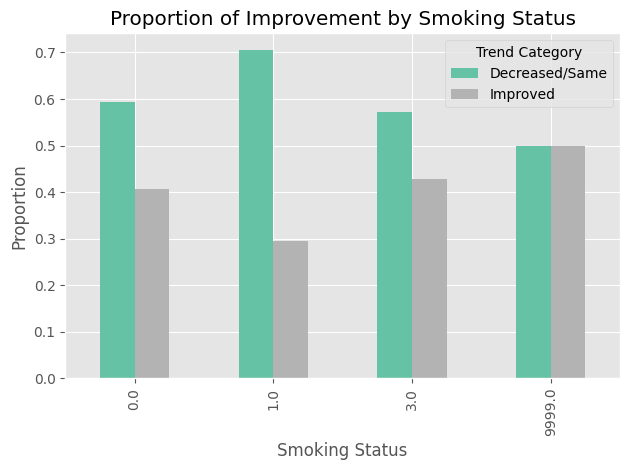

In [143]:

# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_smoking["Trend Category_binary"] = merged_df_removedNA_smoking["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Create dummy variables for smoking categories
smoking_dummies = pd.get_dummies(merged_df_removedNA_smoking["smoking"], 
                                prefix="Smoking", drop_first=True)

# Combine with constant term for regression
X = sm.add_constant(smoking_dummies)
y = merged_df_removedNA_smoking["Trend Category_binary"]

# Logistic regression
try:
    logit_model = sm.Logit(y, X)
    result = logit_model.fit()
    print("\nLogistic Regression Results:")
    print(result.summary())
    
    # Calculate odds ratios and confidence intervals
    params = result.params
    conf = result.conf_int()
    conf['OR'] = params
    conf.columns = ['2.5%', '97.5%', 'OR']
    conf['OR'] = np.exp(conf['OR'])
    conf['2.5%'] = np.exp(conf['2.5%'])
    conf['97.5%'] = np.exp(conf['97.5%'])
    print("\nOdds Ratios and 95% Confidence Intervals:")
    print(conf)
except Exception as e:
    print(f"\nLogistic regression failed: {e}")

# Visualize the relationship between smoking and trend category
plt.figure(figsize=(10, 6))
proportions = pd.crosstab(
    merged_df_removedNA_smoking["smoking"], 
    merged_df_removedNA_smoking["Trend Category"], 
    normalize="index"
)
proportions.plot(kind="bar", stacked=False, colormap="Set2")
plt.title("Proportion of Improvement by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Proportion")
plt.legend(title="Trend Category")
plt.tight_layout()
plt.show()

# sensitivity analysis 8) smoking

In [148]:
merged_df_removedNA_smoking

,id,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,smoking,smoking_category,Trend Category_binary
2,32,117.5,159.000000,41.500000,True,Improved,1.0,Current,1
10,76,95.0,97.000000,2.000000,False,Decreased/Same,1.0,Current,0
25,125,119.5,129.000000,9.500000,True,Improved,3.0,Former,1
28,160,119.0,152.000000,33.000000,True,Improved,0.0,Never,1
51,230,133.8,53.000000,-80.800000,False,Decreased/Same,1.0,Current,0
...,...,...,...,...,...,...,...,...,...
1281,1560,154.0,151.833333,-2.166667,False,Decreased/Same,0.0,Never,0
1290,1566,150.0,107.000000,-43.000000,False,Decreased/Same,3.0,Former,0
1298,1571,153.0,104.000000,-49.000000,False,Decreased/Same,0.0,Never,0
1312,1572,141.0,115.000000,-26.000000,False,Decreased/Same,3.0,Former,0


In [150]:

# Define the smoking category mapping
smoking_category_map = {
    0.0: "Never",
    1.0: "Current",
    3.0: "Former",
    9999.0: "Unknown"
}

def analyze_smoking_threshold_relationship(data, threshold):
    """
    Analyze how smoking status relates to improvement at different thresholds
    
    Parameters:
    data: DataFrame containing Change and smoking columns
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    
    # Remove rows where smoking status is missing
    df = df.dropna(subset=["smoking"])
    
    # Map numeric smoking codes to categories
    df["smoking_category"] = df["smoking"].map(smoking_category_map)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count if total_count > 0 else 0
    
    # Create a contingency table
    contingency_table = pd.crosstab(df["smoking_category"], df["Improved"])
    
    # Chi-square test
    try:
        chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency_table)
    except:
        chi2_stat, chi2_p, dof, expected = None, None, None, None
    
    # Calculate improvement rate for each smoking category
    smoking_improvement_rates = {}
    for category in df["smoking_category"].unique():
        category_df = df[df["smoking_category"] == category]
        if len(category_df) > 0:
            smoking_improvement_rates[category] = category_df["Improved"].mean()
    
    # Logistic regression with smoking as categorical
    try:
        # Create dummy variables for smoking category
        smoking_dummies = pd.get_dummies(df["smoking_category"], prefix="Smoking", drop_first=True)
        
        # Add constant
        X = sm.add_constant(smoking_dummies)
        y = df["Improved"].astype(int)
        
        # Fit model
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        
        # Extract p-value for overall model
        lr_p_value = result.llr_pvalue
    except:
        lr_p_value = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2_stat,
        "chi2_p": chi2_p,
        "smoking_improvement_rates": smoking_improvement_rates,
        "lr_p_value": lr_p_value
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

smoking_data = merged_df_removedNA_smoking.dropna(subset=["Change", "smoking"]).drop_duplicates()


for threshold in thresholds:
    result = analyze_smoking_threshold_relationship(smoking_data, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis of Smoking Status and Improvement at Different Thresholds:")
print(sensitivity_df[["threshold", "improvement_rate", "chi2_p", "lr_p_value"]].round(4))

Sensitivity Analysis of Smoking Status and Improvement at Different Thresholds:
    threshold  improvement_rate  chi2_p lr_p_value
0           0            0.5000  0.2924       None
1           1            0.4889  0.2465       None
2           2            0.4889  0.2465       None
3           3            0.4111  0.7308       None
4           4            0.4000  0.7606       None
5           5            0.4000  0.7606       None
6           6            0.4000  0.7606       None
7           7            0.3889  0.8030       None
8           8            0.3556  0.9435       None
9           9            0.3444  0.7349       None
10         10            0.3333  0.7694       None


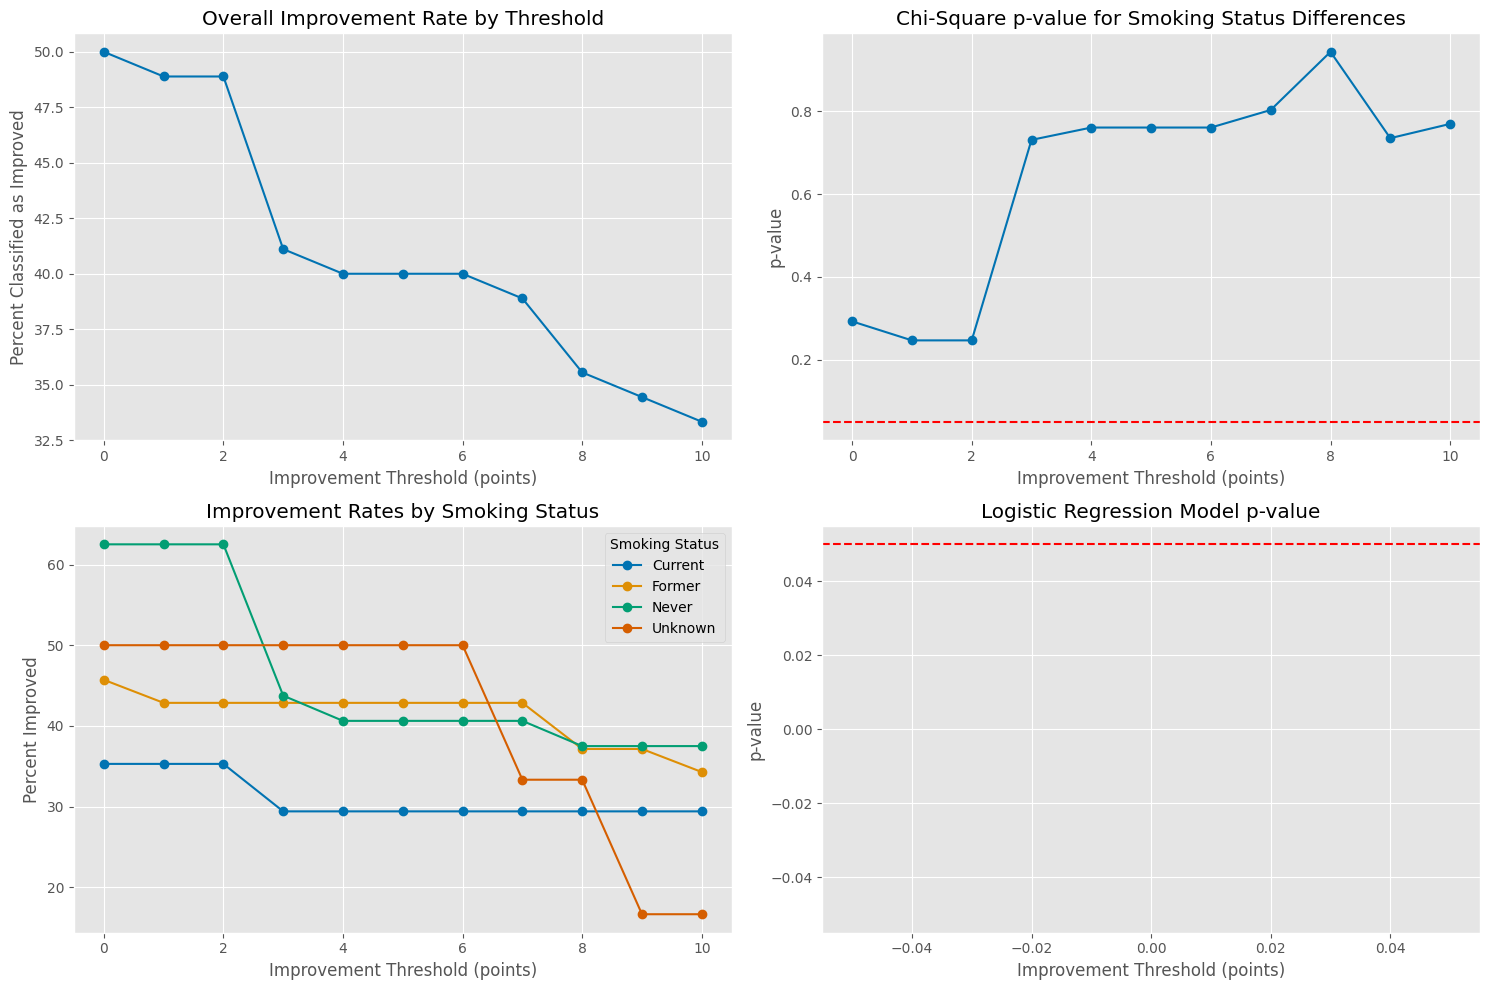


Contingency Table at 5-point threshold:
Trend Category    Decreased/Same  Improved
smoking_category                          
Current                       12         5
Former                        20        15
Never                         19        13
Unknown                        3         3

Chi-Square Test at 5-point threshold:
Chi-square statistic: 1.1684
p-value: 0.7606
Degrees of freedom: 3


<Figure size 1200x700 with 0 Axes>

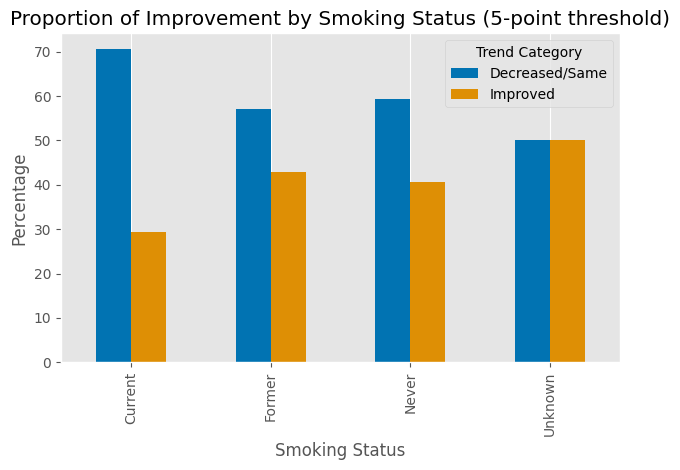

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [151]:


# Extract smoking category-specific improvement rates for each threshold
smoking_rates_by_threshold = {}
for idx, row in sensitivity_df.iterrows():
    threshold = row["threshold"]
    smoking_rates = row["smoking_improvement_rates"]
    if smoking_rates is not None:
        smoking_rates_by_threshold[threshold] = smoking_rates

# Convert to DataFrame for easier plotting
smoking_rates_df = pd.DataFrame(smoking_rates_by_threshold).T
smoking_rates_df.index.name = "threshold"
smoking_rates_df = smoking_rates_df.reset_index()

# Create plots to visualize the results
plt.figure(figsize=(15, 10))

# Plot 1: Improvement rate by threshold
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["improvement_rate"] * 100, 'o-')
plt.title("Overall Improvement Rate by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Percent Classified as Improved")
plt.grid(True)

# Plot 2: Chi-square p-values for smoking status differences
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["chi2_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Chi-Square p-value for Smoking Status Differences")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot 3: Improvement rates by smoking category across thresholds
plt.subplot(2, 2, 3)
for col in smoking_rates_df.columns:
    if col != "threshold":
        plt.plot(smoking_rates_df["threshold"], smoking_rates_df[col] * 100, 'o-', label=col)
plt.title("Improvement Rates by Smoking Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Percent Improved")
plt.legend(title="Smoking Status")
plt.grid(True)

# Plot 4: Logistic regression p-values
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["lr_p_value"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression Model p-value")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Additional analysis: Detailed look at 5-point threshold
threshold_5 = smoking_data.copy()
threshold_5["Improved"] = threshold_5["Change"] >= 5
threshold_5["Trend Category"] = threshold_5["Improved"].map({True: "Improved", False: "Decreased/Same"})
threshold_5 = threshold_5.dropna(subset=["smoking"])
threshold_5["smoking_category"] = threshold_5["smoking"].map(smoking_category_map)

# Create contingency table for smoking vs improvement at 5-point threshold
contingency_5 = pd.crosstab(threshold_5["smoking_category"], threshold_5["Trend Category"])
print("\nContingency Table at 5-point threshold:")
print(contingency_5)

# Chi-square test
chi2_stat_5, chi2_p_5, dof_5, expected_5 = stats.chi2_contingency(contingency_5)
print(f"\nChi-Square Test at 5-point threshold:")
print(f"Chi-square statistic: {chi2_stat_5:.4f}")
print(f"p-value: {chi2_p_5:.4f}")
print(f"Degrees of freedom: {dof_5}")

# Visualize with a bar plot
plt.figure(figsize=(12, 7))
proportions = pd.crosstab(
    threshold_5["smoking_category"], 
    threshold_5["Trend Category"], 
    normalize="index"
) * 100

proportions.plot(kind="bar", stacked=False)
plt.title("Proportion of Improvement by Smoking Status (5-point threshold)")
plt.xlabel("Smoking Status")
plt.ylabel("Percentage")
plt.legend(title="Trend Category")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Logistic regression for smoking at 5-point threshold
smoking_dummies_5 = pd.get_dummies(threshold_5["smoking_category"], prefix="Smoking", drop_first=True)
X_5 = sm.add_constant(smoking_dummies_5)
y_5 = threshold_5["Improved"].astype(int)

logit_model_5 = sm.Logit(y_5, X_5)
result_5 = logit_model_5.fit()

print("\nLogistic Regression Results at 5-point threshold:")
print(result_5.summary())

# Calculate odds ratios and confidence intervals
print("\nOdds Ratios for Smoking Status (relative to reference category):")
params = result_5.params
conf = result_5.conf_int()
conf['OR'] = params
conf.columns = ['2.5%', '97.5%', 'OR']
conf['OR'] = np.exp(conf['OR'])
conf['2.5%'] = np.exp(conf['2.5%'])
conf['97.5%'] = np.exp(conf['97.5%'])
print(conf.iloc[1:])  # Skip the constant

# Count sample sizes for each smoking category
smoking_counts = threshold_5["smoking_category"].value_counts().sort_index()
print("\nSample size for each smoking category:")
print(smoking_counts)

# statistically significantly associated with 9) alcohol consumption

In [153]:
# Merge score_comparison with alcohol data
merged_df_alcohol = score_comparison.merge(filtered_df[["id", "alcohol"]], on="id", how="left")

# Display initial information about the alcohol column
print("Initial alcohol values:")
print(merged_df_alcohol["alcohol"].value_counts(dropna=False))

# Remove rows where alcohol is missing
merged_df_removedNA_alcohol = merged_df_alcohol.dropna(subset=["alcohol"])
merged_df_expanded_alcohol = merged_df_removedNA_alcohol.drop_duplicates()
merged_df_removedNA_alcohol = merged_df_expanded_alcohol.copy()
merged_df_removedNA_alcohol

Initial alcohol values:
alcohol
NaN       1234
1.0         44
0.0         30
9999.0      10
2.0          6
Name: count, dtype: int64


,id,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,alcohol
2,32,117.5,159.000000,41.500000,True,Improved,1.0
10,76,95.0,97.000000,2.000000,False,Decreased/Same,1.0
25,125,119.5,129.000000,9.500000,True,Improved,0.0
28,160,119.0,152.000000,33.000000,True,Improved,0.0
51,230,133.8,53.000000,-80.800000,False,Decreased/Same,1.0
...,...,...,...,...,...,...,...
1281,1560,154.0,151.833333,-2.166667,False,Decreased/Same,0.0
1290,1566,150.0,107.000000,-43.000000,False,Decreased/Same,1.0
1298,1571,153.0,104.000000,-49.000000,False,Decreased/Same,0.0
1312,1572,141.0,115.000000,-26.000000,False,Decreased/Same,2.0


In [154]:
# Map alcohol status to meaningful categories using the provided information
alcohol_mapping = {
    0.0: "Non-drinker",
    1.0: "Current drinker",
    2.0: "Past drinker",
    9999.0: "Unknown"
}

# Create a new column with mapped values
merged_df_removedNA_alcohol["alcohol_category"] = merged_df_removedNA_alcohol["alcohol"].map(alcohol_mapping)

# Print the distribution of alcohol categories
print("\nDistribution of alcohol categories:")
print(merged_df_removedNA_alcohol["alcohol_category"].value_counts())



Distribution of alcohol categories:
alcohol_category
Current drinker    44
Non-drinker        30
Unknown            10
Past drinker        6
Name: count, dtype: int64


In [155]:
# Create a contingency table
contingency_table = pd.crosstab(merged_df_removedNA_alcohol["Trend Category"], 
                               merged_df_removedNA_alcohol["alcohol_category"])
print("\nContingency Table:")
print(contingency_table)

# Chi-square test
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-Square Test p-value: {p_value}")


Contingency Table:
alcohol_category  Current drinker  Non-drinker  Past drinker  Unknown
Trend Category                                                       
Decreased/Same                 26           19             3        6
Improved                       18           11             3        4

Chi-Square Test p-value: 0.9394065830062657



Logistic regression failed: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).


<Figure size 1000x600 with 0 Axes>

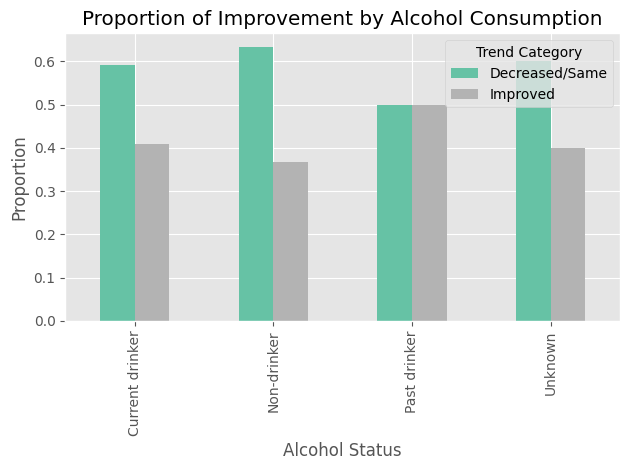

In [156]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_alcohol["Trend Category_binary"] = merged_df_removedNA_alcohol["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Create dummy variables for alcohol categories
alcohol_dummies = pd.get_dummies(merged_df_removedNA_alcohol["alcohol_category"], 
                               prefix="Alcohol", drop_first=True)

# Combine with constant term for regression
X = sm.add_constant(alcohol_dummies)
y = merged_df_removedNA_alcohol["Trend Category_binary"]

# Logistic regression
try:
    logit_model = sm.Logit(y, X)
    result = logit_model.fit()
    print("\nLogistic Regression Results:")
    print(result.summary())
    
    # Calculate odds ratios and confidence intervals
    params = result.params
    conf = result.conf_int()
    conf['OR'] = params
    conf.columns = ['2.5%', '97.5%', 'OR']
    conf['OR'] = np.exp(conf['OR'])
    conf['2.5%'] = np.exp(conf['2.5%'])
    conf['97.5%'] = np.exp(conf['97.5%'])
    print("\nOdds Ratios and 95% Confidence Intervals:")
    print(conf)
except Exception as e:
    print(f"\nLogistic regression failed: {e}")

# Visualize the relationship between alcohol and trend category
plt.figure(figsize=(10, 6))
proportions = pd.crosstab(
    merged_df_removedNA_alcohol["alcohol_category"], 
    merged_df_removedNA_alcohol["Trend Category"], 
    normalize="index"
)
proportions.plot(kind="bar", stacked=False, colormap="Set2")
plt.title("Proportion of Improvement by Alcohol Consumption")
plt.xlabel("Alcohol Status")
plt.ylabel("Proportion")
plt.legend(title="Trend Category")
plt.tight_layout()
plt.show()

# sensitivity analysis 9) alcohol consumption

In [160]:
merged_df_removedNA_alcohol

,id,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,alcohol,alcohol_category,Trend Category_binary
2,32,117.5,159.000000,41.500000,True,Improved,1.0,Current drinker,1
10,76,95.0,97.000000,2.000000,False,Decreased/Same,1.0,Current drinker,0
25,125,119.5,129.000000,9.500000,True,Improved,0.0,Non-drinker,1
28,160,119.0,152.000000,33.000000,True,Improved,0.0,Non-drinker,1
51,230,133.8,53.000000,-80.800000,False,Decreased/Same,1.0,Current drinker,0
...,...,...,...,...,...,...,...,...,...
1281,1560,154.0,151.833333,-2.166667,False,Decreased/Same,0.0,Non-drinker,0
1290,1566,150.0,107.000000,-43.000000,False,Decreased/Same,1.0,Current drinker,0
1298,1571,153.0,104.000000,-49.000000,False,Decreased/Same,0.0,Non-drinker,0
1312,1572,141.0,115.000000,-26.000000,False,Decreased/Same,2.0,Past drinker,0


In [162]:
# Define the alcohol category mapping
alcohol_category_map = {
    0.0: "Non-drinker",
    1.0: "Current drinker",
    2.0: "Past drinker",
    9999.0: "Unknown"
}

def analyze_alcohol_threshold_relationship(data, threshold):
    """
    Analyze how alcohol status relates to improvement at different thresholds
    
    Parameters:
    data: DataFrame containing Change and alcohol columns
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    
    # Remove rows where alcohol status is missing
    df = df.dropna(subset=["alcohol"])
    
    # Map numeric alcohol codes to categories
    df["alcohol_category"] = df["alcohol"].map(alcohol_category_map)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count if total_count > 0 else 0
    
    # Create a contingency table
    contingency_table = pd.crosstab(df["alcohol_category"], df["Improved"])
    
    # Chi-square test
    try:
        chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency_table)
    except:
        chi2_stat, chi2_p, dof, expected = None, None, None, None
    
    # Calculate improvement rate for each alcohol category
    alcohol_improvement_rates = {}
    for category in df["alcohol_category"].unique():
        category_df = df[df["alcohol_category"] == category]
        if len(category_df) > 0:
            alcohol_improvement_rates[category] = category_df["Improved"].mean()
    
    # Logistic regression with alcohol as categorical
    try:
        # Create dummy variables for alcohol category
        alcohol_dummies = pd.get_dummies(df["alcohol_category"], prefix="Alcohol", drop_first=True)
        
        # Add constant
        X = sm.add_constant(alcohol_dummies)
        y = df["Improved"].astype(int)
        
        # Fit model
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        
        # Extract p-value for overall model
        lr_p_value = result.llr_pvalue
    except:
        lr_p_value = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2_stat,
        "chi2_p": chi2_p,
        "alcohol_improvement_rates": alcohol_improvement_rates,
        "lr_p_value": lr_p_value
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

alcohol_data = merged_df_removedNA_alcohol.dropna(subset=["Change", "alcohol"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_alcohol_threshold_relationship(alcohol_data, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis of Alcohol Status and Improvement at Different Thresholds:")
print(sensitivity_df[["threshold", "improvement_rate", "chi2_p", "lr_p_value"]].round(4))

Sensitivity Analysis of Alcohol Status and Improvement at Different Thresholds:
    threshold  improvement_rate  chi2_p lr_p_value
0           0            0.5000  0.5686       None
1           1            0.4889  0.6777       None
2           2            0.4889  0.6777       None
3           3            0.4111  0.9137       None
4           4            0.4000  0.9394       None
5           5            0.4000  0.9394       None
6           6            0.4000  0.9394       None
7           7            0.3889  0.8538       None
8           8            0.3556  0.7369       None
9           9            0.3444  0.5375       None
10         10            0.3333  0.4391       None


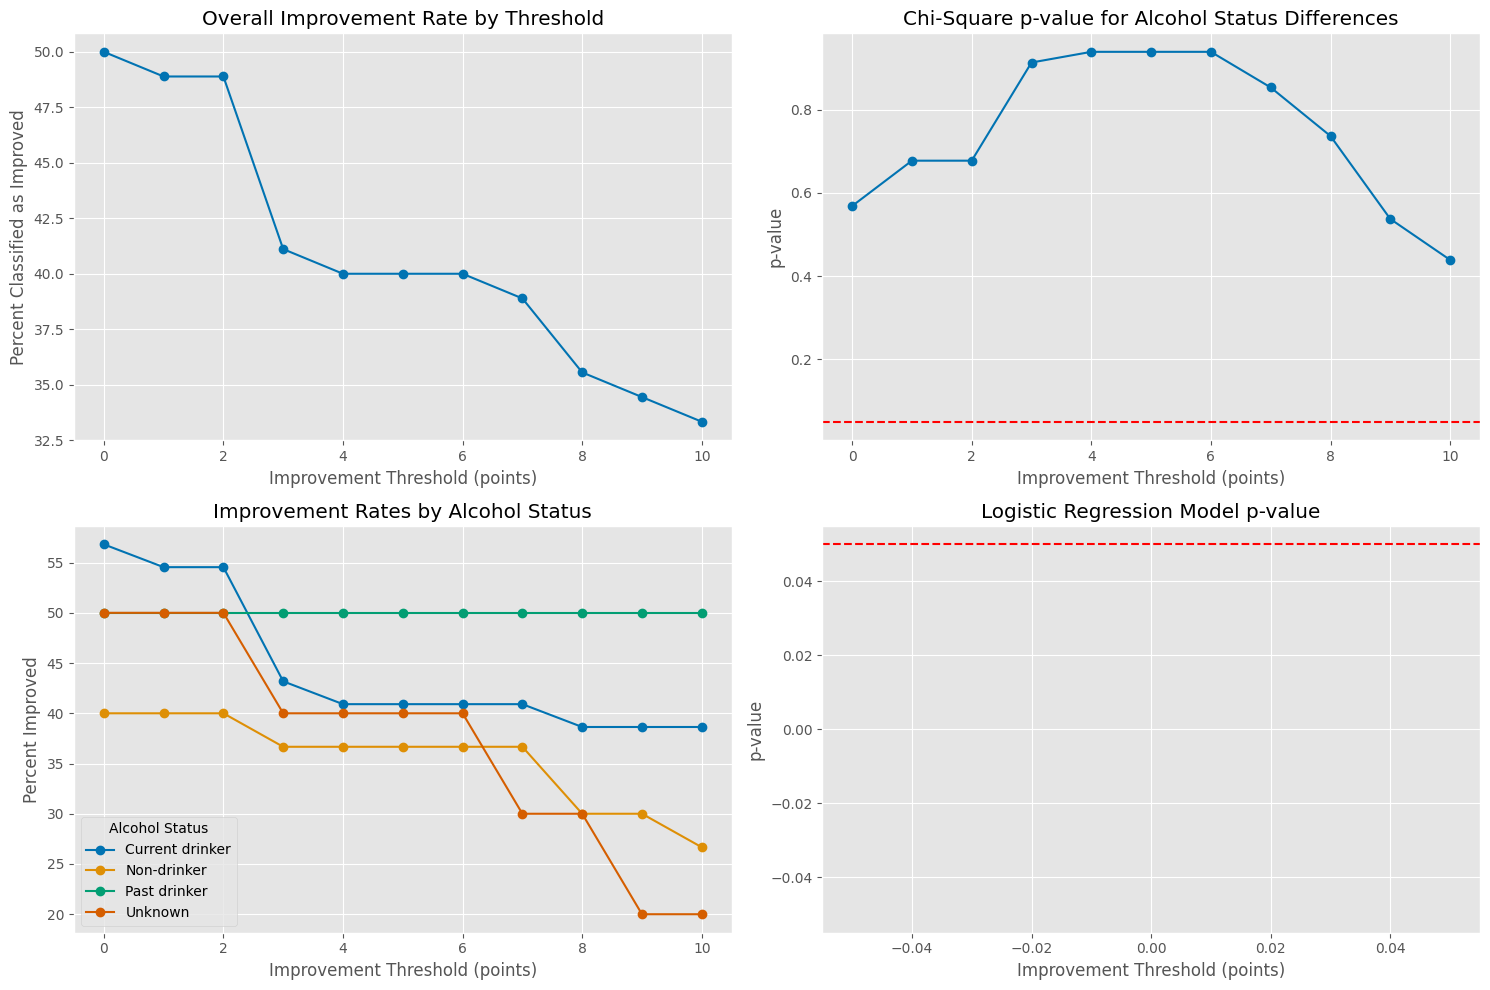


Contingency Table at 5-point threshold:
Trend Category    Decreased/Same  Improved
alcohol_category                          
Current drinker               26        18
Non-drinker                   19        11
Past drinker                   3         3
Unknown                        6         4

Chi-Square Test at 5-point threshold:
Chi-square statistic: 0.4040
p-value: 0.9394
Degrees of freedom: 3


<Figure size 1200x700 with 0 Axes>

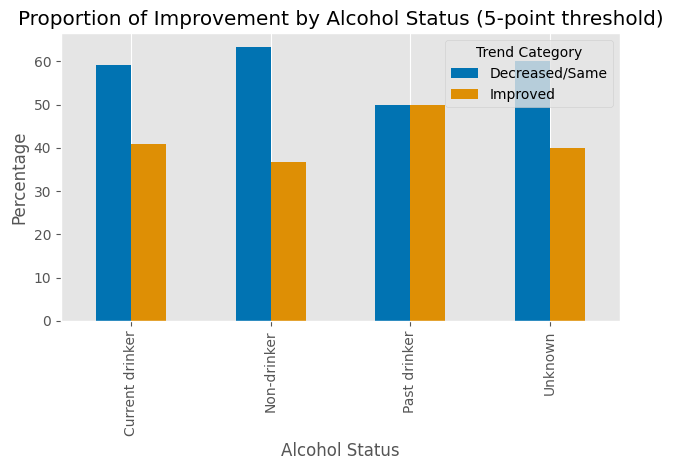

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [163]:

# Extract alcohol category-specific improvement rates for each threshold
alcohol_rates_by_threshold = {}
for idx, row in sensitivity_df.iterrows():
    threshold = row["threshold"]
    alcohol_rates = row["alcohol_improvement_rates"]
    if alcohol_rates is not None:
        alcohol_rates_by_threshold[threshold] = alcohol_rates

# Convert to DataFrame for easier plotting
alcohol_rates_df = pd.DataFrame(alcohol_rates_by_threshold).T
alcohol_rates_df.index.name = "threshold"
alcohol_rates_df = alcohol_rates_df.reset_index()

# Create plots to visualize the results
plt.figure(figsize=(15, 10))

# Plot 1: Improvement rate by threshold
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["improvement_rate"] * 100, 'o-')
plt.title("Overall Improvement Rate by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Percent Classified as Improved")
plt.grid(True)

# Plot 2: Chi-square p-values for alcohol status differences
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["chi2_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Chi-Square p-value for Alcohol Status Differences")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot 3: Improvement rates by alcohol category across thresholds
plt.subplot(2, 2, 3)
for col in alcohol_rates_df.columns:
    if col != "threshold":
        plt.plot(alcohol_rates_df["threshold"], alcohol_rates_df[col] * 100, 'o-', label=col)
plt.title("Improvement Rates by Alcohol Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Percent Improved")
plt.legend(title="Alcohol Status")
plt.grid(True)

# Plot 4: Logistic regression p-values
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["lr_p_value"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression Model p-value")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Additional analysis: Detailed look at 5-point threshold
threshold_5 = alcohol_data.copy()
threshold_5["Improved"] = threshold_5["Change"] >= 5
threshold_5["Trend Category"] = threshold_5["Improved"].map({True: "Improved", False: "Decreased/Same"})
threshold_5 = threshold_5.dropna(subset=["alcohol"])
threshold_5["alcohol_category"] = threshold_5["alcohol"].map(alcohol_category_map)

# Create contingency table for alcohol vs improvement at 5-point threshold
contingency_5 = pd.crosstab(threshold_5["alcohol_category"], threshold_5["Trend Category"])
print("\nContingency Table at 5-point threshold:")
print(contingency_5)

# Chi-square test
chi2_stat_5, chi2_p_5, dof_5, expected_5 = stats.chi2_contingency(contingency_5)
print(f"\nChi-Square Test at 5-point threshold:")
print(f"Chi-square statistic: {chi2_stat_5:.4f}")
print(f"p-value: {chi2_p_5:.4f}")
print(f"Degrees of freedom: {dof_5}")

# Visualize with a bar plot
plt.figure(figsize=(12, 7))
proportions = pd.crosstab(
    threshold_5["alcohol_category"], 
    threshold_5["Trend Category"], 
    normalize="index"
) * 100

proportions.plot(kind="bar", stacked=False)
plt.title("Proportion of Improvement by Alcohol Status (5-point threshold)")
plt.xlabel("Alcohol Status")
plt.ylabel("Percentage")
plt.legend(title="Trend Category")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Logistic regression for alcohol at 5-point threshold
alcohol_dummies_5 = pd.get_dummies(threshold_5["alcohol_category"], prefix="Alcohol", drop_first=True)
X_5 = sm.add_constant(alcohol_dummies_5)
y_5 = threshold_5["Improved"].astype(int)

logit_model_5 = sm.Logit(y_5, X_5)
result_5 = logit_model_5.fit()

print("\nLogistic Regression Results at 5-point threshold:")
print(result_5.summary())

# Calculate odds ratios and confidence intervals
print("\nOdds Ratios for Alcohol Status (relative to reference category):")
params = result_5.params
conf = result_5.conf_int()
conf['OR'] = params
conf.columns = ['2.5%', '97.5%', 'OR']
conf['OR'] = np.exp(conf['OR'])
conf['2.5%'] = np.exp(conf['2.5%'])
conf['97.5%'] = np.exp(conf['97.5%'])
print(conf.iloc[1:])  # Skip the constant

# Count sample sizes for each alcohol category
alcohol_counts = threshold_5["alcohol_category"].value_counts().sort_index()
print("\nSample size for each alcohol category:")
print(alcohol_counts)

# statistically significantly associated with 10) Neoadjuvant treatment (six neotx)

### single column

In [65]:
# Check for patients with multiple treatments

# Define treatment columns
treatment_columns = [
    "neotx___notx", 
    "neotx___chemo", 
    "neotx___rads",
    "neotx___chemorads", 
    "neotx___immuno", 
    "neotx___other"
]

# Count how many treatment types each patient has
filtered_df["treatment_count"] = filtered_df[treatment_columns].sum(axis=1)

# Summarize the results
print("\n### Multiple Treatment Analysis ###\n")
print(f"Total patients: {len(filtered_df)}")

# Count patients by number of treatments
treatment_distribution = filtered_df["treatment_count"].value_counts().sort_index()
print("\nDistribution of patients by number of treatment types:")
print(treatment_distribution)

# Calculate percentage with multiple treatments
multiple_count = (filtered_df["treatment_count"] > 1).sum()
multiple_percent = (multiple_count / len(filtered_df)) * 100
print(f"\nPatients with multiple treatments: {multiple_count} ({multiple_percent:.2f}%)")

# Optional: Show sample of patients with multiple treatments
if multiple_count > 0:
    print("\nSample of patients with multiple treatments:")
    multiple_treatment_patients = filtered_df[filtered_df["treatment_count"] > 1]
    print(multiple_treatment_patients[["id"] + treatment_columns].head())

# Check for logical inconsistencies (e.g., "notx" along with other treatments)
if "neotx___notx" in treatment_columns:
    inconsistent_count = ((filtered_df["neotx___notx"] == 1) & (filtered_df["treatment_count"] > 1)).sum()
    if inconsistent_count > 0:
        print(f"\nWARNING: Found {inconsistent_count} patients marked as having no treatment (notx=1) but also other treatments")
        inconsistent_patients = filtered_df[(filtered_df["neotx___notx"] == 1) & (filtered_df["treatment_count"] > 1)]
        print("\nSample of inconsistent patients:")
        print(inconsistent_patients[["id"] + treatment_columns].head())


### Multiple Treatment Analysis ###

Total patients: 1963

Distribution of patients by number of treatment types:
treatment_count
0.0    1782
1.0     157
2.0      24
Name: count, dtype: int64

Patients with multiple treatments: 24 (1.22%)

Sample of patients with multiple treatments:
       id  neotx___notx  neotx___chemo  neotx___rads  neotx___chemorads  \
3595  449           0.0            1.0           1.0                0.0   
3775  471           0.0            1.0           1.0                0.0   
4854  589           0.0            1.0           1.0                0.0   
4901  597           0.0            1.0           0.0                0.0   
5337  644           0.0            1.0           1.0                0.0   

      neotx___immuno  neotx___other  
3595             0.0            0.0  
3775             0.0            0.0  
4854             0.0            0.0  
4901             1.0            0.0  
5337             0.0            0.0  


Sample of inconsistent patients:


In [69]:
# List of binary treatment columns
treatment_columns = [
    "neotx___notx", 
    "neotx___chemo", 
    "neotx___rads",
    "neotx___chemorads", 
    "neotx___immuno", 
    "neotx___other"
]

# Merge data (assuming score_comparison and filtered_df are already defined)
merged_df = score_comparison.merge(filtered_df[["id"] + treatment_columns], on="id", how="left")
merged_df = merged_df.dropna(subset=treatment_columns)
merged_df = merged_df.drop_duplicates()

# Count treatment types per patient
merged_df['treatment_count'] = merged_df[treatment_columns].sum(axis=1)

# Display distribution of treatment counts
print("Distribution of treatment counts per patient:")
print(merged_df['treatment_count'].value_counts().sort_index())

# Filter to keep only patients with exactly one treatment type
single_treatment_df = merged_df[merged_df['treatment_count'] == 1].copy()
print(f"\nPatients with exactly one treatment type: {len(single_treatment_df)}")
print(f"Removed {len(merged_df) - len(single_treatment_df)} patients with multiple treatment types")

# Create a categorical treatment variable
treatment_mapping = {
    "neotx___notx": "No Treatment",
    "neotx___chemo": "Chemotherapy",
    "neotx___rads": "Radiation",
    "neotx___chemorads": "Chemoradiation",
    "neotx___immuno": "Immunotherapy",
    "neotx___other": "Other Treatment"
}

# Initialize the categorical variable
single_treatment_df['treatment_type'] = None

# Assign the appropriate treatment type to each patient
for col, treatment_name in treatment_mapping.items():
    single_treatment_df.loc[single_treatment_df[col] == 1, 'treatment_type'] = treatment_name

# Display distribution of treatment types
print("\nDistribution of treatment types:")
print(single_treatment_df['treatment_type'].value_counts())

# Create a contingency table
contingency_table = pd.crosstab(single_treatment_df["Trend Category"], single_treatment_df["treatment_type"])
print("\nContingency Table (counts):")
print(contingency_table)

# Add row percentages
percentage_table = pd.crosstab(
    single_treatment_df["Trend Category"], 
    single_treatment_df["treatment_type"], 
    normalize="index"
) * 100
print("\nPercentage Table (row %):")
print(percentage_table.round(1))

# Chi-square test
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-Square Test:")
print(f"Statistic: {chi2_stat:.2f}")
print(f"p-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

# Check if sample size is adequate for chi-square
min_expected = expected.min()
if min_expected < 5:
    print(f"\nWarning: Minimum expected count is {min_expected:.2f}, which is less than 5.")
    print("Chi-square test may not be valid. Consider combining rare categories.")
    
    # Optional: Show which cells have low expected counts
    print("\nExpected counts for each cell:")
    expected_df = pd.DataFrame(
        expected, 
        index=contingency_table.index, 
        columns=contingency_table.columns
    )
    print(expected_df.round(2))
    
    # Suggest categories to combine
    low_cols = expected_df.columns[expected_df.min() < 5]
    print(f"\nCategories with low expected counts that could be combined: {list(low_cols)}")

Distribution of treatment counts per patient:
treatment_count
0.0     8
1.0    92
2.0    19
Name: count, dtype: int64

Patients with exactly one treatment type: 92
Removed 27 patients with multiple treatment types

Distribution of treatment types:
treatment_type
Chemotherapy       67
No Treatment       12
Chemoradiation     10
Other Treatment     2
Radiation           1
Name: count, dtype: int64

Contingency Table (counts):
treatment_type  Chemoradiation  Chemotherapy  No Treatment  Other Treatment  \
Trend Category                                                                
Decreased/Same               5            42             7                1   
Improved                     5            25             5                1   

treatment_type  Radiation  
Trend Category             
Decreased/Same          1  
Improved                0  

Percentage Table (row %):
treatment_type  Chemoradiation  Chemotherapy  No Treatment  Other Treatment  \
Trend Category                       

### multiple columns


### Analyzing: neotx___notx ###

        id  Baseline   Postop1yr     Change fact_e_total_has_improved  \
3       32     117.5  159.000000  41.500000                      True   
13      76      95.0   97.000000   2.000000                     False   
24     125     119.5  129.000000   9.500000                      True   
30     160     119.0  152.000000  33.000000                      True   
52     230     133.8   53.000000 -80.800000                     False   
...    ...       ...         ...        ...                       ...   
1282  1560     154.0  151.833333  -2.166667                     False   
1288  1566     150.0  107.000000 -43.000000                     False   
1299  1571     153.0  104.000000 -49.000000                     False   
1311  1572     141.0  115.000000 -26.000000                     False   
1319  1615     126.0  111.000000 -15.000000                     False   

      Trend Category  neotx___notx  
3           Improved           0.0  
13    Decreased

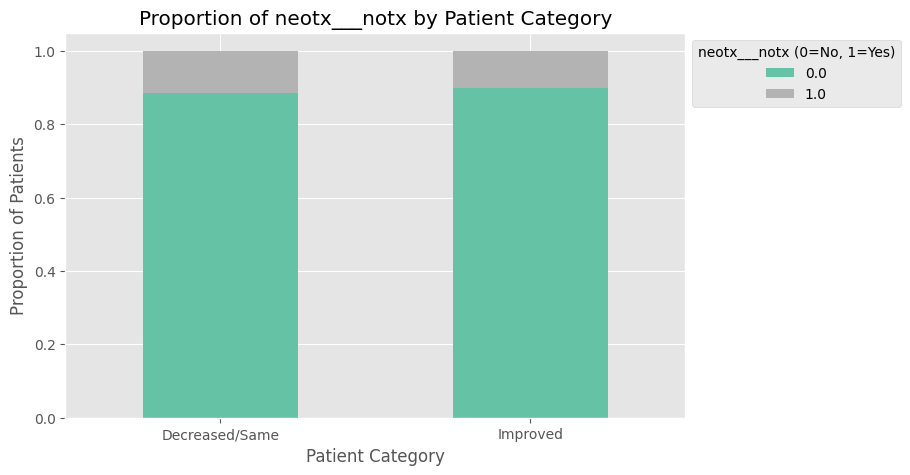


### Analyzing: neotx___chemo ###

        id  Baseline   Postop1yr     Change fact_e_total_has_improved  \
3       32     117.5  159.000000  41.500000                      True   
13      76      95.0   97.000000   2.000000                     False   
24     125     119.5  129.000000   9.500000                      True   
30     160     119.0  152.000000  33.000000                      True   
52     230     133.8   53.000000 -80.800000                     False   
...    ...       ...         ...        ...                       ...   
1282  1560     154.0  151.833333  -2.166667                     False   
1288  1566     150.0  107.000000 -43.000000                     False   
1299  1571     153.0  104.000000 -49.000000                     False   
1311  1572     141.0  115.000000 -26.000000                     False   
1319  1615     126.0  111.000000 -15.000000                     False   

      Trend Category  neotx___chemo  
3           Improved            1.0  
13    Decrea

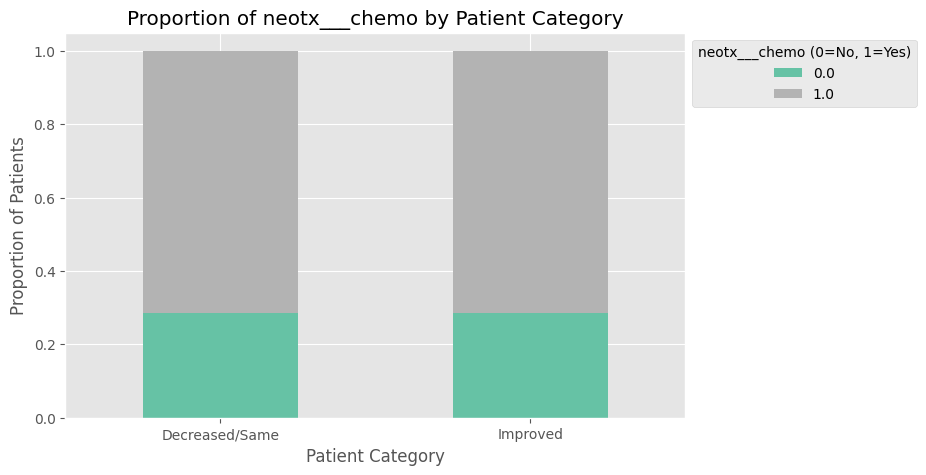


### Analyzing: neotx___rads ###

        id  Baseline   Postop1yr     Change fact_e_total_has_improved  \
3       32     117.5  159.000000  41.500000                      True   
13      76      95.0   97.000000   2.000000                     False   
24     125     119.5  129.000000   9.500000                      True   
30     160     119.0  152.000000  33.000000                      True   
52     230     133.8   53.000000 -80.800000                     False   
...    ...       ...         ...        ...                       ...   
1282  1560     154.0  151.833333  -2.166667                     False   
1288  1566     150.0  107.000000 -43.000000                     False   
1299  1571     153.0  104.000000 -49.000000                     False   
1311  1572     141.0  115.000000 -26.000000                     False   
1319  1615     126.0  111.000000 -15.000000                     False   

      Trend Category  neotx___rads  
3           Improved           0.0  
13    Decreased

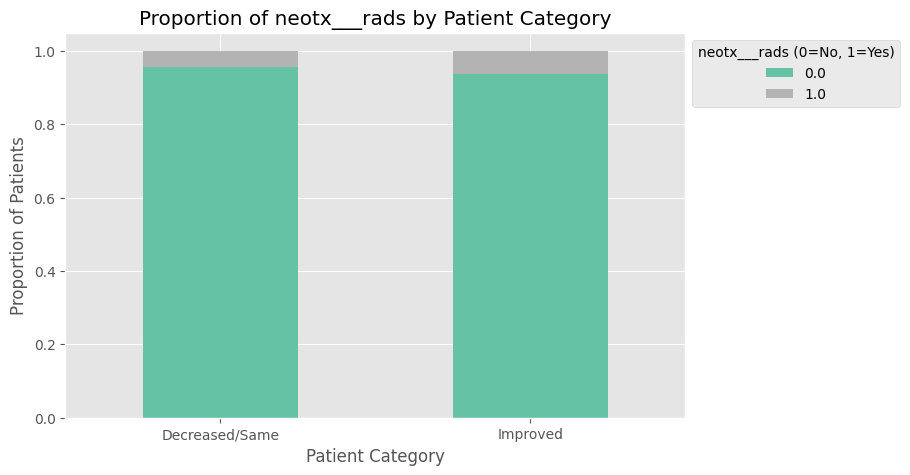


### Analyzing: neotx___chemorads ###

        id  Baseline   Postop1yr     Change fact_e_total_has_improved  \
3       32     117.5  159.000000  41.500000                      True   
13      76      95.0   97.000000   2.000000                     False   
24     125     119.5  129.000000   9.500000                      True   
30     160     119.0  152.000000  33.000000                      True   
52     230     133.8   53.000000 -80.800000                     False   
...    ...       ...         ...        ...                       ...   
1282  1560     154.0  151.833333  -2.166667                     False   
1288  1566     150.0  107.000000 -43.000000                     False   
1299  1571     153.0  104.000000 -49.000000                     False   
1311  1572     141.0  115.000000 -26.000000                     False   
1319  1615     126.0  111.000000 -15.000000                     False   

      Trend Category  neotx___chemorads  
3           Improved                0.0  


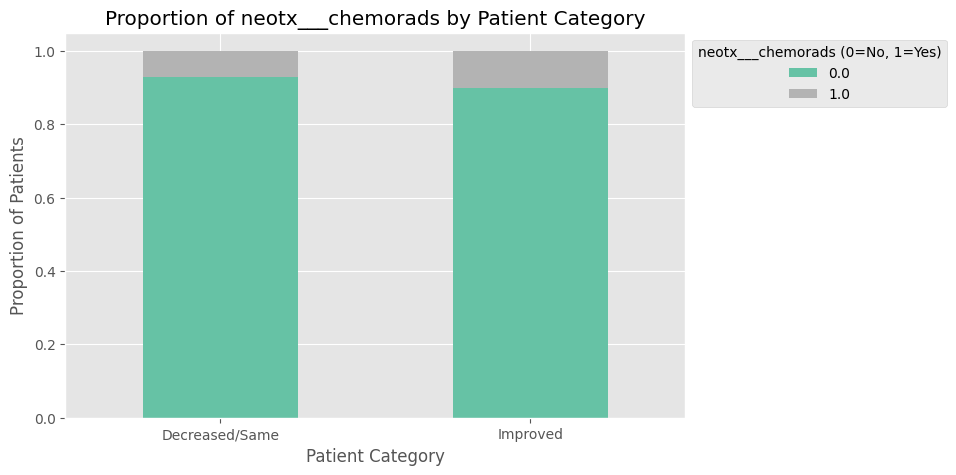


### Analyzing: neotx___immuno ###

        id  Baseline   Postop1yr     Change fact_e_total_has_improved  \
3       32     117.5  159.000000  41.500000                      True   
13      76      95.0   97.000000   2.000000                     False   
24     125     119.5  129.000000   9.500000                      True   
30     160     119.0  152.000000  33.000000                      True   
52     230     133.8   53.000000 -80.800000                     False   
...    ...       ...         ...        ...                       ...   
1282  1560     154.0  151.833333  -2.166667                     False   
1288  1566     150.0  107.000000 -43.000000                     False   
1299  1571     153.0  104.000000 -49.000000                     False   
1311  1572     141.0  115.000000 -26.000000                     False   
1319  1615     126.0  111.000000 -15.000000                     False   

      Trend Category  neotx___immuno  
3           Improved             0.0  
13    Dec

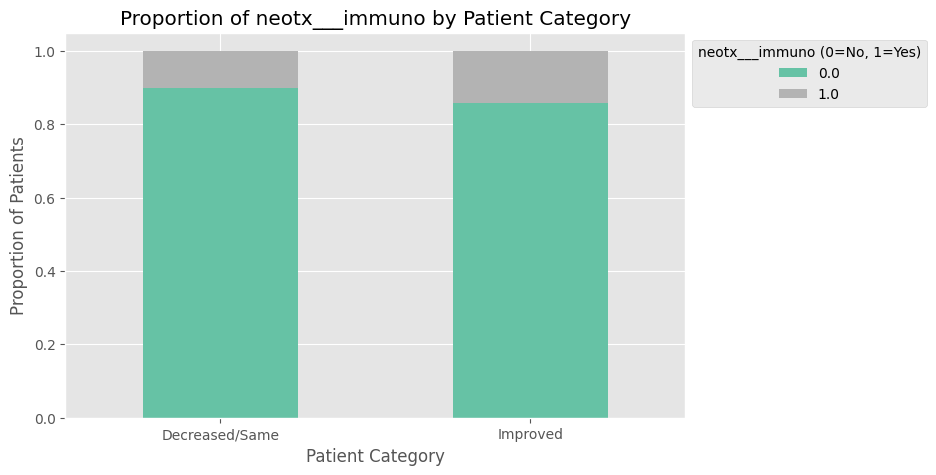


### Analyzing: neotx___other ###

        id  Baseline   Postop1yr     Change fact_e_total_has_improved  \
3       32     117.5  159.000000  41.500000                      True   
13      76      95.0   97.000000   2.000000                     False   
24     125     119.5  129.000000   9.500000                      True   
30     160     119.0  152.000000  33.000000                      True   
52     230     133.8   53.000000 -80.800000                     False   
...    ...       ...         ...        ...                       ...   
1282  1560     154.0  151.833333  -2.166667                     False   
1288  1566     150.0  107.000000 -43.000000                     False   
1299  1571     153.0  104.000000 -49.000000                     False   
1311  1572     141.0  115.000000 -26.000000                     False   
1319  1615     126.0  111.000000 -15.000000                     False   

      Trend Category  neotx___other  
3           Improved            0.0  
13    Decrea

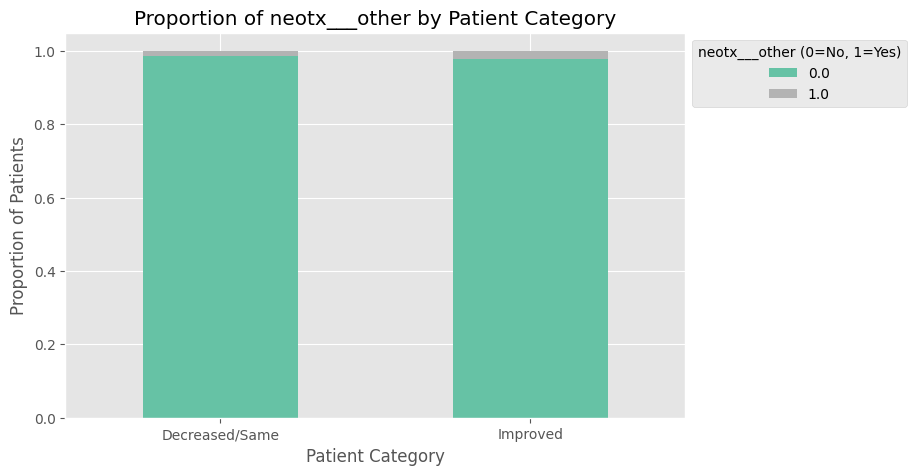

In [164]:
# List of binary treatment columns
treatment_columns = ["neotx___notx", "neotx___chemo", "neotx___rads", 
                    "neotx___chemorads", "neotx___immuno", "neotx___other"]

for col in treatment_columns:
    print(f"\n### Analyzing: {col} ###\n")
    
    # Merge data
    merged_df = score_comparison.merge(filtered_df[["id", col]], on="id", how="left")
    
    # Remove rows where treatment data is missing
    merged_df = merged_df.dropna(subset=[col])
    merged_df = merged_df.drop_duplicates()
    print(merged_df)
    # Create a contingency table
    contingency_table = pd.crosstab(merged_df["Trend Category"], merged_df[col])
    print(contingency_table)
    
    # Chi-square test
    chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    print(f"Chi-Square Test p-value: {p_value}")

    # Fisher's Exact Test (only if 2x2 table)
    if contingency_table.shape == (2, 2):
        odds_ratio, p_value_fisher = stats.fisher_exact(contingency_table)
        print(f"Fisher's Exact Test p-value: {p_value_fisher}")

    # Convert Trend Category to binary (1 = Improved, 0 = Decreased/Same)
    merged_df["Trend Category_binary"] = merged_df["Trend Category"].map({"Improved": 1, "Decreased/Same": 0})

    # Logistic Regression Model
    X = sm.add_constant(merged_df["Trend Category_binary"])
    y = merged_df[col]  # Treatment variable (0/1)
    
    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        print(result.summary())
    except Exception as e:
        print(f"Logistic regression failed: {e}")

    # Create proportion table
    proportions = merged_df.groupby("Trend Category")[col].value_counts(normalize=True).unstack()

    # Plot bar chart
    proportions.plot(kind="bar", stacked=True, colormap="Set2", figsize=(8, 5))
    plt.xlabel("Patient Category")
    plt.ylabel("Proportion of Patients")
    plt.title(f"Proportion of {col} by Patient Category")
    plt.legend(title=f"{col} (0=No, 1=Yes)", bbox_to_anchor=(1, 1))
    plt.xticks(rotation=0)
    plt.show()


# sensitivity analysis 10) Neoadjuvant treatment (six neotx)

### single column

In [83]:
single_treatment_df

,id,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,neotx___notx,neotx___chemo,neotx___rads,neotx___chemorads,neotx___immuno,neotx___other,treatment_count,treatment_type
3,32,117.5,159.000000,41.500000,True,Improved,0.0,1.0,0.0,0.0,0.0,0.0,1.0,Chemotherapy
13,76,95.0,97.000000,2.000000,False,Decreased/Same,0.0,1.0,0.0,0.0,0.0,0.0,1.0,Chemotherapy
24,125,119.5,129.000000,9.500000,True,Improved,0.0,1.0,0.0,0.0,0.0,0.0,1.0,Chemotherapy
30,160,119.0,152.000000,33.000000,True,Improved,0.0,1.0,0.0,0.0,0.0,0.0,1.0,Chemotherapy
52,230,133.8,53.000000,-80.800000,False,Decreased/Same,0.0,1.0,0.0,0.0,0.0,0.0,1.0,Chemotherapy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1282,1560,154.0,151.833333,-2.166667,False,Decreased/Same,0.0,1.0,0.0,0.0,0.0,0.0,1.0,Chemotherapy
1288,1566,150.0,107.000000,-43.000000,False,Decreased/Same,0.0,1.0,0.0,0.0,0.0,0.0,1.0,Chemotherapy
1299,1571,153.0,104.000000,-49.000000,False,Decreased/Same,0.0,1.0,0.0,0.0,0.0,0.0,1.0,Chemotherapy
1311,1572,141.0,115.000000,-26.000000,False,Decreased/Same,0.0,1.0,0.0,0.0,0.0,0.0,1.0,Chemotherapy


In [84]:
def analyze_treatment_threshold_relationship(data, threshold):
    """
    Analyze how treatment relates to improvement at different thresholds
    
    Parameters:
    data: DataFrame containing Change and treatment_type columns
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    
    # Check for missing treatment type values
    df = df.dropna(subset=["treatment_type"])
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count if total_count > 0 else 0
    
    # Create a contingency table
    contingency_table = pd.crosstab(df["treatment_type"], df["Trend Category"])
    
    # Chi-square test
    try:
        chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency_table)
    except:
        chi2_stat, chi2_p, dof, expected = None, None, None, None
    
    # Calculate improvement rate for each treatment type
    treatment_improvement_rates = {}
    for treatment in df["treatment_type"].unique():
        treatment_df = df[df["treatment_type"] == treatment]
        if len(treatment_df) > 0:
            treatment_improvement_rates[treatment] = treatment_df["Improved"].mean()
    
    # Logistic regression with treatment as categorical
    try:
        # Create dummy variables for treatment
        treatment_dummies = pd.get_dummies(df["treatment_type"], prefix="Treatment", drop_first=True)
        
        # Add constant
        X = sm.add_constant(treatment_dummies)
        y = df["Improved"].astype(int)
        
        # Fit model
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        
        # Extract p-value for overall model
        lr_p_value = result.llr_pvalue
    except:
        lr_p_value = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2_stat,
        "chi2_p": chi2_p,
        "treatment_improvement_rates": treatment_improvement_rates,
        "lr_p_value": lr_p_value
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Use the existing single_treatment_df
clean_df = single_treatment_df.dropna(subset=["Change", "treatment_type"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_treatment_threshold_relationship(clean_df, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis of Treatment Type and Improvement at Different Thresholds:")
print(sensitivity_df[["threshold", "improvement_rate", "chi2_p", "lr_p_value"]].round(4))


Sensitivity Analysis of Treatment Type and Improvement at Different Thresholds:
    threshold  improvement_rate  chi2_p lr_p_value
0           0            0.4565  0.7614       None
1           1            0.4457  0.8886       None
2           2            0.4457  0.8886       None
3           3            0.4022  0.8754       None
4           4            0.3913  0.8505       None
5           5            0.3913  0.8505       None
6           6            0.3804  0.8179       None
7           7            0.3696  0.7770       None
8           8            0.3587  0.7901       None
9           9            0.3478  0.7576       None
10         10            0.3370  0.7169       None


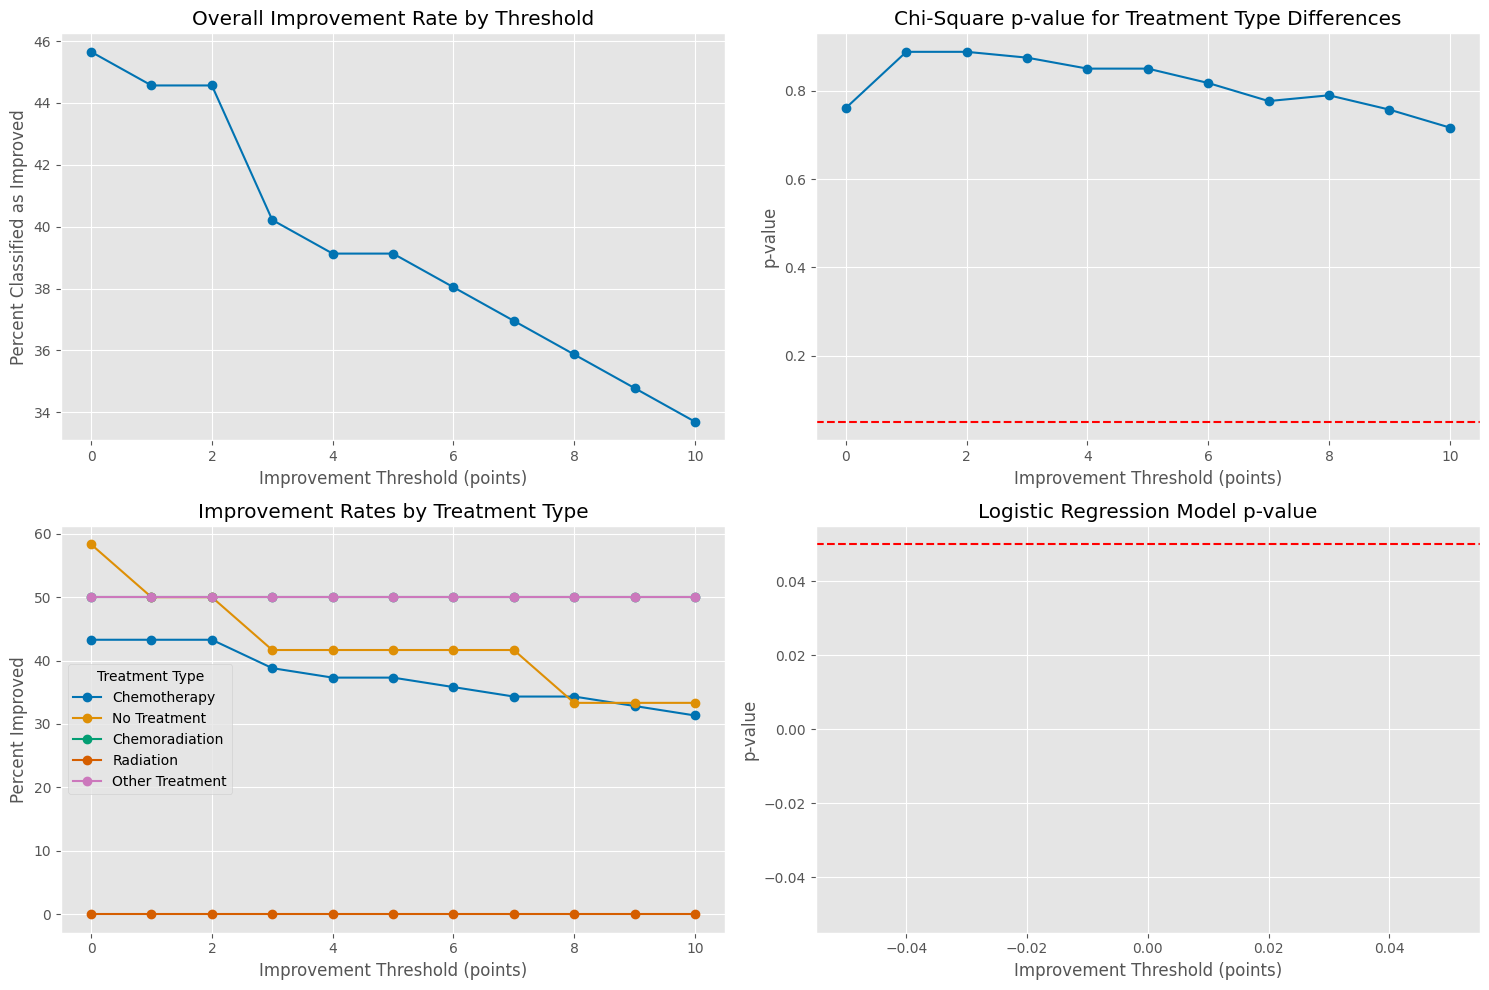


Contingency Table at 5-point threshold:
Trend Category   Decreased/Same  Improved
treatment_type                           
Chemoradiation                5         5
Chemotherapy                 42        25
No Treatment                  7         5
Other Treatment               1         1
Radiation                     1         0

Chi-Square Test at 5-point threshold:
Chi-square statistic: 1.3634
p-value: 0.8505
Degrees of freedom: 4


<Figure size 1200x700 with 0 Axes>

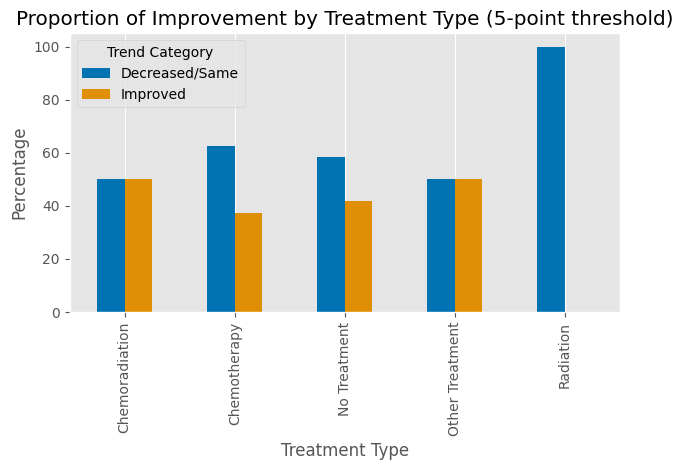

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [85]:
# Extract treatment-specific improvement rates for each threshold
treatment_rates_by_threshold = {}
for idx, row in sensitivity_df.iterrows():
    threshold = row["threshold"]
    treatment_rates = row["treatment_improvement_rates"]
    if treatment_rates is not None:
        treatment_rates_by_threshold[threshold] = treatment_rates

# Convert to DataFrame for easier plotting
treatment_rates_df = pd.DataFrame(treatment_rates_by_threshold).T
treatment_rates_df.index.name = "threshold"
treatment_rates_df = treatment_rates_df.reset_index()

# Create plots to visualize the results
plt.figure(figsize=(15, 10))

# Plot 1: Improvement rate by threshold
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["improvement_rate"] * 100, 'o-')
plt.title("Overall Improvement Rate by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Percent Classified as Improved")
plt.grid(True)

# Plot 2: Chi-square p-values for treatment differences
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["chi2_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Chi-Square p-value for Treatment Type Differences")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot 3: Improvement rates by treatment across thresholds
plt.subplot(2, 2, 3)
for col in treatment_rates_df.columns:
    if col != "threshold":
        plt.plot(treatment_rates_df["threshold"], treatment_rates_df[col] * 100, 'o-', label=col)
plt.title("Improvement Rates by Treatment Type")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Percent Improved")
plt.legend(title="Treatment Type")
plt.grid(True)

# Plot 4: Logistic regression p-values
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["lr_p_value"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression Model p-value")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Additional analysis: Detailed look at 5-point threshold
threshold_5 = clean_df.copy()
threshold_5["Improved"] = threshold_5["Change"] >= 5
threshold_5["Trend Category"] = threshold_5["Improved"].map({True: "Improved", False: "Decreased/Same"})

# Create contingency table for treatment vs improvement at 5-point threshold
contingency_5 = pd.crosstab(threshold_5["treatment_type"], threshold_5["Trend Category"])
print("\nContingency Table at 5-point threshold:")
print(contingency_5)

# Chi-square test
chi2_stat_5, chi2_p_5, dof_5, expected_5 = stats.chi2_contingency(contingency_5)
print(f"\nChi-Square Test at 5-point threshold:")
print(f"Chi-square statistic: {chi2_stat_5:.4f}")
print(f"p-value: {chi2_p_5:.4f}")
print(f"Degrees of freedom: {dof_5}")

# Visualize with a bar plot
plt.figure(figsize=(12, 7))
proportions = pd.crosstab(
    threshold_5["treatment_type"], 
    threshold_5["Trend Category"], 
    normalize="index"
) * 100

proportions.plot(kind="bar", stacked=False)
plt.title("Proportion of Improvement by Treatment Type (5-point threshold)")
plt.xlabel("Treatment Type")
plt.ylabel("Percentage")
plt.legend(title="Trend Category")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Logistic regression for treatment at 5-point threshold
treatment_dummies_5 = pd.get_dummies(threshold_5["treatment_type"], prefix="Treatment", drop_first=True)
X_5 = sm.add_constant(treatment_dummies_5)
y_5 = threshold_5["Improved"].astype(int)

logit_model_5 = sm.Logit(y_5, X_5)
result_5 = logit_model_5.fit()

print("\nLogistic Regression Results at 5-point threshold:")
print(result_5.summary())

# Calculate odds ratios and confidence intervals
print("\nOdds Ratios for Treatment Types (relative to reference level):")
params = result_5.params
conf = result_5.conf_int()
conf['OR'] = params
conf.columns = ['2.5%', '97.5%', 'OR']
conf['OR'] = np.exp(conf['OR'])
conf['2.5%'] = np.exp(conf['2.5%'])
conf['97.5%'] = np.exp(conf['97.5%'])
print(conf.iloc[1:])  # Skip the constant

# Count sample sizes for each treatment type
treatment_counts = threshold_5["treatment_type"].value_counts().sort_index()
print("\nSample size for each treatment type:")
print(treatment_counts)

### multiple columns

Chi-square Test p-values across thresholds:
variable   neotx___chemo  neotx___chemorads  neotx___immuno  neotx___notx  \
threshold                                                                   
0                 1.0000             1.0000          0.3256        0.9004   
1                 0.9555             1.0000          0.2942        1.0000   
2                 0.9555             1.0000          0.2942        1.0000   
3                 1.0000             1.0000          0.6597        1.0000   
4                 1.0000             0.9578          0.6113        1.0000   
5                 1.0000             0.9578          0.6113        1.0000   
6                 1.0000             0.9113          0.5641        1.0000   
7                 0.9946             0.8647          0.5184        1.0000   
8                 1.0000             0.7258          1.0000        0.9083   
9                 0.9452             0.6802          1.0000        0.9598   
10                0.7546        

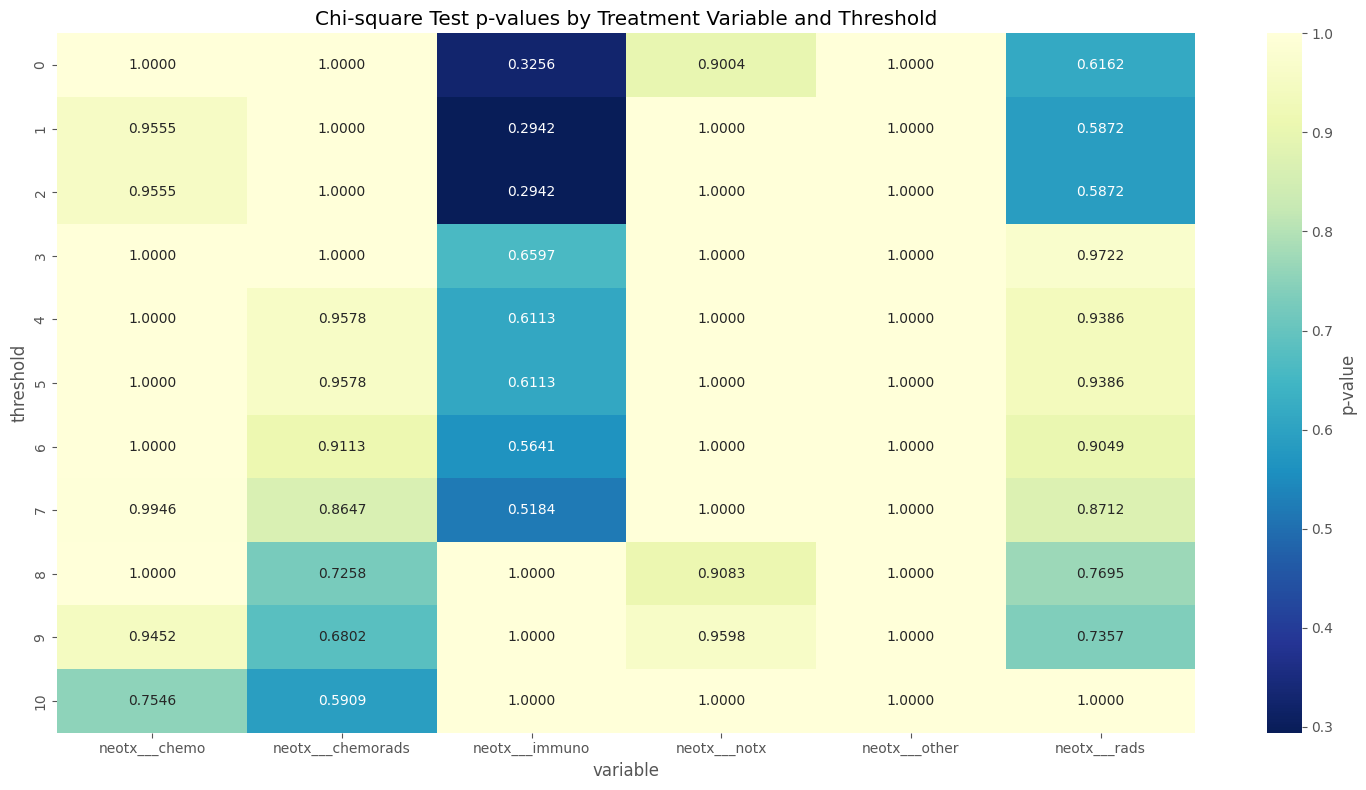

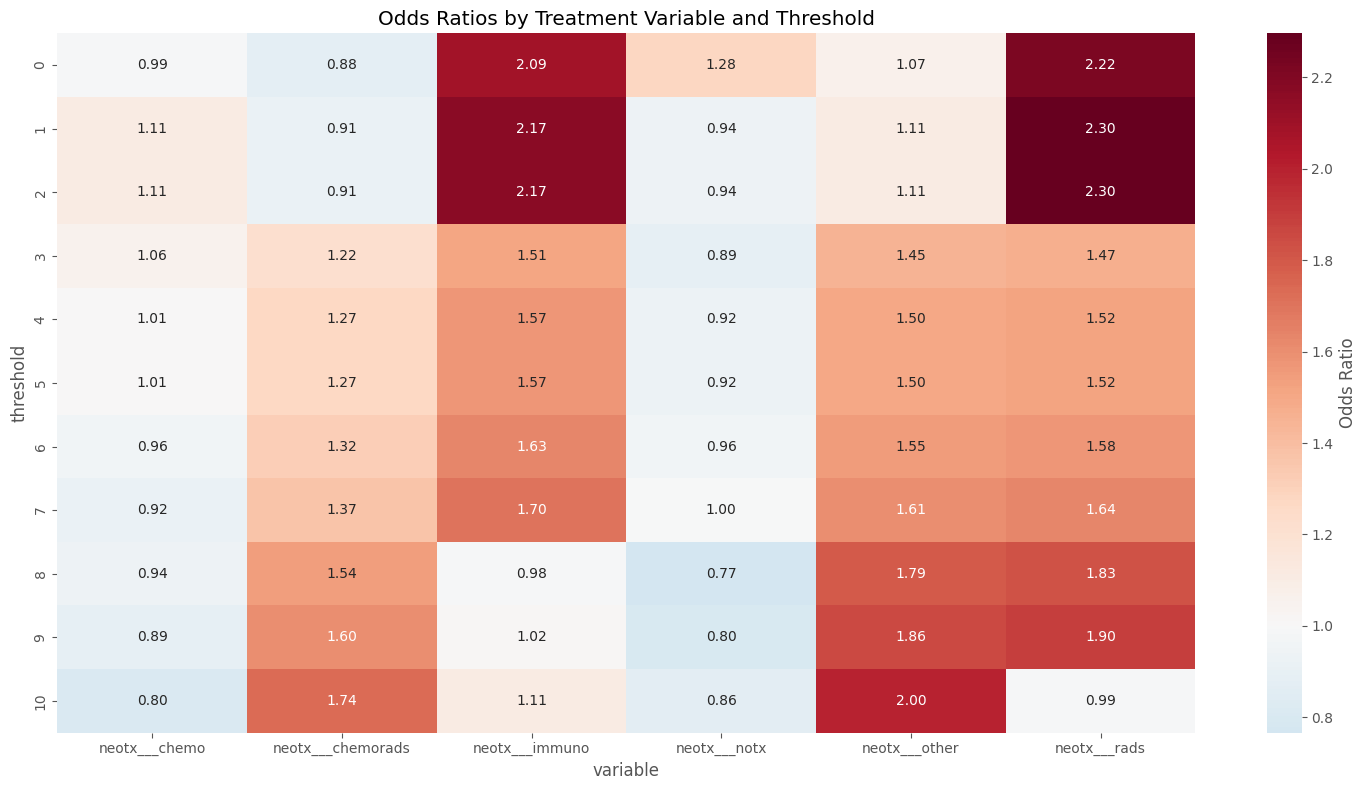

<Figure size 1500x800 with 0 Axes>

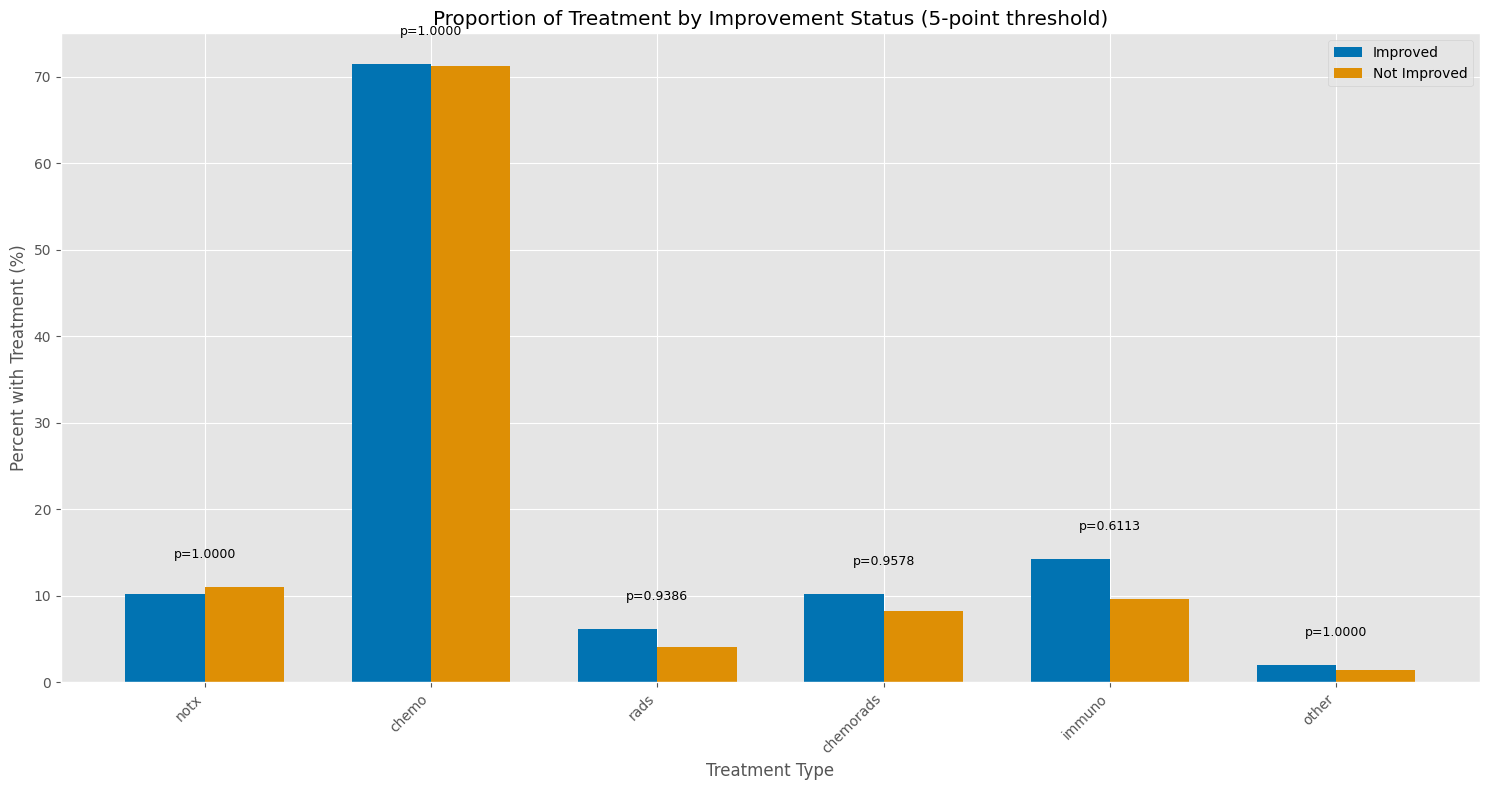


Chi-square Test Results at 5-point threshold:
Variable                  Chi-square    p-value
--------------------------------------------
notx                      0.00       1.0000
Contingency table for notx:
     Not Improved  Improved
No             65        44
Yes             8         5

chemo                     0.00       1.0000
Contingency table for chemo:
     Not Improved  Improved
No             21        14
Yes            52        35

rads                      0.01       0.9386
Contingency table for rads:
     Not Improved  Improved
No             70        46
Yes             3         3

chemorads                 0.00       0.9578
Contingency table for chemorads:
     Not Improved  Improved
No             67        44
Yes             6         5

immuno                    0.26       0.6113
Contingency table for immuno:
     Not Improved  Improved
No             66        42
Yes             7         7

other                     0.00       1.0000
Contingency table for o

In [167]:

# Define the list of treatment columns
treatment_columns = [
    "neotx___notx", 
    "neotx___chemo", 
    "neotx___rads",
    "neotx___chemorads", 
    "neotx___immuno", 
    "neotx___other"
]

def analyze_binary_variable_threshold(data, binary_var, threshold):
    """
    Analyze how a single binary variable relates to improvement at different thresholds
    
    Parameters:
    data: DataFrame containing Change and the binary variable
    binary_var: Name of the binary variable to analyze
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    
    # Remove rows where the binary variable is missing
    df = df.dropna(subset=[binary_var])
    
    # Ensure binary variable is numeric
    df[binary_var] = df[binary_var].astype(float)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count if total_count > 0 else 0
    
    # Chi-square test for binary variable vs improvement
    contingency = pd.crosstab(df[binary_var], df["Improved"])
    
    # Make sure the contingency table has both 0 and 1 values for the binary variable
    if contingency.shape[0] == 2:
        try:
            chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency)
        except:
            chi2_stat, chi2_p, dof, expected = None, None, None, None
    else:
        chi2_stat, chi2_p, dof, expected = None, None, None, None
    
    # Calculate proportion of patients with positive binary variable by improvement status
    if len(df[df["Improved"]]) > 0:
        pos_rate_improved = df[df["Improved"]][binary_var].mean()
    else:
        pos_rate_improved = None
        
    if len(df[~df["Improved"]]) > 0:
        pos_rate_not_improved = df[~df["Improved"]][binary_var].mean()
    else:
        pos_rate_not_improved = None
    
    # Logistic regression
    try:
        X = sm.add_constant(df[binary_var])
        y = df["Improved"].astype(int)
        
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        
        var_coef = result.params[binary_var]
        var_p = result.pvalues[binary_var]
        var_or = np.exp(var_coef)
        
        # Confidence intervals
        var_conf_int = result.conf_int().loc[binary_var]
        lower_ci = np.exp(var_conf_int[0])
        upper_ci = np.exp(var_conf_int[1])
    except:
        var_coef, var_p, var_or = None, None, None
        lower_ci, upper_ci = None, None
    
    return {
        "variable": binary_var,
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2_stat,
        "chi2_p": chi2_p,
        "pos_rate_improved": pos_rate_improved,
        "pos_rate_not_improved": pos_rate_not_improved,
        "logistic_coef": var_coef,
        "logistic_p": var_p,
        "odds_ratio": var_or,
        "or_lower_ci": lower_ci,
        "or_upper_ci": upper_ci
    }

# Run the analysis for all treatment variables across different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
all_results = []

# Merge treatment data with score comparison data
treatment_data = score_comparison.merge(
    filtered_df[["id"] + treatment_columns], 
    on="id", 
    how="left"
)

# Run analysis for each variable and threshold
for var in treatment_columns:
    for threshold in thresholds:
        result = analyze_binary_variable_threshold(treatment_data, var, threshold)
        all_results.append(result)

# Convert to DataFrame for easier analysis
all_sensitivity_df = pd.DataFrame(all_results)

# Create a pivot table to see p-values for all variables across thresholds
pvalue_pivot = all_sensitivity_df.pivot(index="threshold", columns="variable", values="chi2_p")
print("Chi-square Test p-values across thresholds:")
print(pvalue_pivot.round(4))

# Create a pivot table for odds ratios
or_pivot = all_sensitivity_df.pivot(index="threshold", columns="variable", values="odds_ratio")
print("\nOdds Ratios across thresholds:")
print(or_pivot.round(2))

# Create heatmaps to visualize results
plt.figure(figsize=(15, 8))
sns.heatmap(pvalue_pivot, annot=True, cmap="YlGnBu_r", fmt=".4f", cbar_kws={'label': 'p-value'})
plt.title("Chi-square Test p-values by Treatment Variable and Threshold")
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 8))
sns.heatmap(or_pivot, annot=True, cmap="RdBu_r", center=1, fmt=".2f", cbar_kws={'label': 'Odds Ratio'})
plt.title("Odds Ratios by Treatment Variable and Threshold")
plt.tight_layout()
plt.show()

# Detailed analysis at 5-point threshold
threshold_5_results = all_sensitivity_df[all_sensitivity_df["threshold"] == 5]

# Create a bar chart for the proportion of positive treatment by improvement status
plt.figure(figsize=(15, 8))

variable_names = []
improved_rates = []
not_improved_rates = []

for _, row in threshold_5_results.iterrows():
    variable_names.append(row["variable"].replace("neotx___", ""))
    improved_rates.append(row["pos_rate_improved"] * 100 if row["pos_rate_improved"] is not None else 0)
    not_improved_rates.append(row["pos_rate_not_improved"] * 100 if row["pos_rate_not_improved"] is not None else 0)

x = np.arange(len(variable_names))
width = 0.35

fig, ax = plt.subplots(figsize=(15, 8))
rects1 = ax.bar(x - width/2, improved_rates, width, label='Improved')
rects2 = ax.bar(x + width/2, not_improved_rates, width, label='Not Improved')

ax.set_xlabel('Treatment Type')
ax.set_ylabel('Percent with Treatment (%)')
ax.set_title('Proportion of Treatment by Improvement Status (5-point threshold)')
ax.set_xticks(x)
ax.set_xticklabels(variable_names, rotation=45, ha='right')
ax.legend()

# Add p-value annotations
for i, var in enumerate(variable_names):
    full_var = "neotx___" + var
    p_val = threshold_5_results[threshold_5_results["variable"] == full_var]["chi2_p"].values[0]
    if pd.notna(p_val):
        ax.text(i, max(improved_rates[i], not_improved_rates[i]) + 3, f'p={p_val:.4f}', 
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# For each treatment variable at the 5-point threshold, create a contingency table and report chi-square results
print("\nChi-square Test Results at 5-point threshold:")
print("Variable                  Chi-square    p-value")
print("--------------------------------------------")

for var in treatment_columns:
    # Create a contingency table for this variable at threshold 5
    threshold_5 = treatment_data.copy()
    threshold_5["Improved"] = threshold_5["Change"] >= 5
    threshold_5 = threshold_5.dropna(subset=[var])
    threshold_5[var] = threshold_5[var].astype(float)
    
    contingency = pd.crosstab(threshold_5[var], threshold_5["Improved"])
    
    if contingency.shape[0] == 2:  # Make sure we have both 0 and 1 values
        try:
            chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency)
            var_name = var.replace("neotx___", "")
            print(f"{var_name.ljust(25)} {chi2_stat:.2f}       {chi2_p:.4f}")
            
            # Print the contingency table for better interpretation
            print(f"Contingency table for {var_name}:")
            contingency.columns = ["Not Improved", "Improved"]
            contingency.index = ["No", "Yes"]
            print(contingency)
            print()
        except:
            var_name = var.replace("neotx___", "")
            print(f"{var_name.ljust(25)} Not available")
    else:
        var_name = var.replace("neotx___", "")
        print(f"{var_name.ljust(25)} Not available (insufficient data)")

# Logistic regression summary for all variables at 5-point threshold
print("\nLogistic Regression Results at 5-point threshold:")
print("Variable                  Odds Ratio    95% CI           p-value")
print("----------------------------------------------------------------")
for _, row in threshold_5_results.iterrows():
    var_name = row["variable"].replace("neotx___", "")
    or_val = row["odds_ratio"]
    lower_ci = row["or_lower_ci"]
    upper_ci = row["or_upper_ci"]
    p_val = row["logistic_p"]
    
    if pd.notna(or_val) and pd.notna(lower_ci) and pd.notna(upper_ci) and pd.notna(p_val):
        print(f"{var_name.ljust(25)} {or_val:.2f}      ({lower_ci:.2f}-{upper_ci:.2f})    {p_val:.4f}")
    else:
        print(f"{var_name.ljust(25)} Not available")